In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(1, '/home/jw3514/Work/CellType_Psy/src')
from CellType_PSY import *
import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()
os.chdir("/home/jw3514/Work/CellType_Psy/notebooks3/")
print(f"Current working directory: {os.getcwd()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/jw3514/Work/CellType_Psy/notebooks3


In [4]:
HumanCTExpL = pd.read_csv("../dat/HumanCTExpressionMats/Human.Cluster.Log2Mean.Exp.csv", index_col=0)
HumanCTExpL.columns = [int(x) for x in HumanCTExpL.columns.values]

In [5]:
HumanCT_Z2 = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.Cluster.Log2Mean.Z1clip5.Z2.clip2.Jan21.csv", index_col=0)
HumanCT_Z2.columns = [int(x) for x in HumanCT_Z2.columns.values]

In [91]:
def test_supercluster_enrichment(supercluster_to_test, ObsDF, RandDFs):
    supercluster_idx = ObsDF[ObsDF["Supercluster"]==supercluster_to_test].index
    Obs = ObsDF.loc[supercluster_idx, "EFFECT"].mean()
    print(f"Observed effect for {supercluster_to_test}: {Obs}")

    Null = []
    for df in RandDFs:
        eff = df.loc[supercluster_idx, "EFFECT"].mean()
        Null.append(eff)
    Null = np.array(Null)

    Z, P = GetPermutationP(Null, Obs)
    print(f"P-value: {P}")
    return Obs, Null, Z, P



# Weight Redistribution Test (Jan 17 2025)

####  ASD Type1 (Randomly redistribute the mutations, and assign new weights to same genes)

In [7]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_HIQ_Type1/"
Perm_Z2_BiasDFs_ASD_HIQ_Type1 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_HIQ_Type1.append(Perm_Z2_Bias)

In [8]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_LIQ_Type1/"
Perm_Z2_BiasDFs_ASD_LIQ_Type1 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_LIQ_Type1.append(Perm_Z2_Bias)

In [9]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_ALL_Type1/"
Perm_Z2_BiasDFs_ASD_ALL_Type1 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_ALL_Type1.append(Perm_Z2_Bias)

In [10]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_ExomeWide_Type1/"
Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type1 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type1.append(Perm_Z2_Bias)

In [11]:
BiasDIR = "/home/jw3514/Work/CellType_Psy/dat/Bias_Jan13_2025/"
ASD_HIQ_Bias = pd.read_csv("{}/HCT.ASD61.HIQ.Z2.HCT.csv".format(BiasDIR), index_col=0)
ASD_LIQ_Bias = pd.read_csv("{}/HCT.ASD61.LIQ.Z2.HCT.csv".format(BiasDIR), index_col=0)
ASD_ALL_Bias = pd.read_csv("{}/HCT.ASD61.Z2.HCT.csv".format(BiasDIR), index_col=0)

In [12]:
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_HIQ_Bias, Perm_Z2_BiasDFs_ASD_HIQ_Type1)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_LIQ_Bias, Perm_Z2_BiasDFs_ASD_LIQ_Type1)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_Type1)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type1)

Observed effect for Medium spiny neuron: 0.14742833966578195
P-value: 0.7062937062937062
Observed effect for Medium spiny neuron: 0.22339678447584893
P-value: 0.049950049950049924
Observed effect for Medium spiny neuron: 0.19085577671057136
P-value: 0.09890109890109888
Observed effect for Medium spiny neuron: 0.19085577671057136
P-value: 0.11388611388611392


Observed effect for Medium spiny neuron: 0.19085577671057136
P-value: 0.11388611388611392


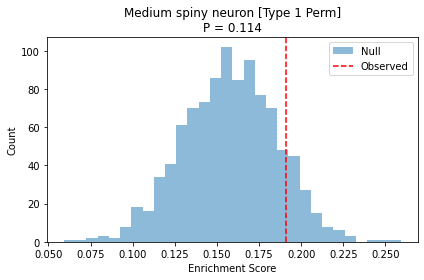

In [15]:
#Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE3)
CT = "Medium spiny neuron"
Obs, Null, Z, P = test_supercluster_enrichment(CT, ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type1)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('Medium spiny neuron [Type 1 Perm]\nP = {:.3f}'.format(P))
plt.legend()
plt.tight_layout()

In [88]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_HIQ_Bias, Perm_Z2_BiasDFs_ASD_HIQ_Type1)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_LIQ_Bias, Perm_Z2_BiasDFs_ASD_LIQ_Type1)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_Type1)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type1)

Observed effect for CGE interneuron: -0.1294927317997083
P-value: 0.9460539460539461
Observed effect for CGE interneuron: 0.09687408072131617
P-value: 0.5204795204795205
Observed effect for CGE interneuron: 0.01647449638006753
P-value: 0.7662337662337663
Observed effect for CGE interneuron: 0.01647449638006753
P-value: 0.7802197802197802


####  ASD HIQ Type2 (Randomly redistribute the mutations according to background mutation rate, and assign new weights to same genes)

In [16]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_HIQ_Type2/"
Perm_Z2_BiasDFs_ASD_HIQ_Type2 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_HIQ_Type2.append(Perm_Z2_Bias)

In [17]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_LIQ_Type2/"
Perm_Z2_BiasDFs_ASD_LIQ_Type2 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_LIQ_Type2.append(Perm_Z2_Bias)

In [18]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_ALL_Type2/"
Perm_Z2_BiasDFs_ASD_ALL_Type2 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_ALL_Type2.append(Perm_Z2_Bias)

In [19]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_ExomeWide_Type2/"
Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type2 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type2.append(Perm_Z2_Bias)

In [20]:
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_HIQ_Bias, Perm_Z2_BiasDFs_ASD_HIQ_Type2)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_LIQ_Bias, Perm_Z2_BiasDFs_ASD_LIQ_Type2)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_Type2)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type2)

Observed effect for Medium spiny neuron: 0.14742833966578195
P-value: 0.42957042957042957
Observed effect for Medium spiny neuron: 0.22339678447584893
P-value: 0.016983016983016963
Observed effect for Medium spiny neuron: 0.19085577671057136
P-value: 0.03596403596403597
Observed effect for Medium spiny neuron: 0.19085577671057136
P-value: 0.007992007992007943


In [89]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_HIQ_Bias, Perm_Z2_BiasDFs_ASD_HIQ_Type2)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_LIQ_Bias, Perm_Z2_BiasDFs_ASD_LIQ_Type2)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_Type2)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type2)

Observed effect for CGE interneuron: -0.1294927317997083
P-value: 0.99000999000999
Observed effect for CGE interneuron: 0.09687408072131617
P-value: 0.3306693306693307
Observed effect for CGE interneuron: 0.01647449638006753
P-value: 0.6843156843156843
Observed effect for CGE interneuron: 0.01647449638006753
P-value: 0.8071928071928072


In [55]:
# Create empty lists to store results
superclusters_list = []
pvalues_list = []
bias_list = []
null_mean_list = []
# Test each supercluster and save results
for supercluster in ALL_CTs:
    Obs, Null, Z, P = test_supercluster_enrichment(supercluster, ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type2)
    superclusters_list.append(supercluster)
    pvalues_list.append(P)
    bias_list.append(Obs)
    null_mean_list.append(Null.mean())
# Create dataframe with results
results_df = pd.DataFrame({
    'Supercluster': superclusters_list,
    'bias': bias_list,
    'null_mean': null_mean_list,
    'P_value': pvalues_list
})

# Calculate FDR-corrected p-values
results_df['FDR'] = multipletests(results_df['P_value'], method='fdr_bh')[1]

# Sort by FDR-corrected p-value
results_df = results_df.sort_values('FDR')

Observed effect for Amygdala excitatory: 0.2790883511045638
P-value: 0.4535464535464535
Observed effect for CGE interneuron: 0.029673967823757266
P-value: 0.5774225774225774
Observed effect for Cerebellar inhibitory: -0.09036060846961855
P-value: 0.988011988011988
Observed effect for Deep-layer corticothalamic and 6b: 0.1567706484192099
P-value: 0.5324675324675325
Observed effect for Deep-layer intratelencephalic: 0.23120907951665298
P-value: 0.5494505494505495
Observed effect for Deep-layer near-projecting: 0.07650835564736816
P-value: 0.9460539460539461
Observed effect for Eccentric medium spiny neuron: 0.1150062031847255
P-value: 0.006993006993006978
Observed effect for Hippocampal CA1-3: 0.21341872973089696
P-value: 0.004995004995005048
Observed effect for Hippocampal CA4: 0.12999783706283816
P-value: 0.060939060939060985
Observed effect for Hippocampal dentate gyrus: 0.06501597225637386
P-value: 0.0029970029970030065
Observed effect for LAMP5-LHX6 and Chandelier: -0.00069435653528

In [56]:
results_df

,Supercluster,bias,null_mean,P_value,FDR
30,Vascular,-0.086278,-0.295273,0.000999,0.006194
26,Fibroblast,-0.204550,-0.346712,0.000999,0.006194
23,Choroid plexus,0.032508,-0.069919,0.000999,0.006194
19,Upper rhombic lip,-0.100104,-0.185642,0.000999,0.006194
29,Oligodendrocyte precursor,-0.299345,-0.361150,0.000999,0.006194
16,Miscellaneous,-0.001167,-0.038657,0.001998,0.008848
15,Midbrain-derived inhibitory,0.103874,0.001903,0.001998,0.008848
9,Hippocampal dentate gyrus,0.065016,-0.013373,0.002997,0.011613
7,Hippocampal CA1-3,0.213419,0.166218,0.004995,0.015485
25,Ependymal,-0.137536,-0.220060,0.004995,0.015485


In [44]:
0.05 / 32 / 2

0.00078125

####  ASD HIQ Type3 (Randomly redistribute the mutations according to background mutation rate, and assign new weights to random genes)

In [21]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_HIQ_Type3/"
Perm_Z2_BiasDFs_ASD_HIQ_Type3 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_HIQ_Type3.append(Perm_Z2_Bias)

In [22]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_LIQ_Type3/"
Perm_Z2_BiasDFs_ASD_LIQ_Type3 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_LIQ_Type3.append(Perm_Z2_Bias)

In [23]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_ALL_Type3/"
Perm_Z2_BiasDFs_ASD_ALL_Type3 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_ALL_Type3.append(Perm_Z2_Bias)

In [24]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_ExomeWide_Type3/"
Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type3 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type3.append(Perm_Z2_Bias)

In [25]:
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_HIQ_Bias, Perm_Z2_BiasDFs_ASD_HIQ_Type3)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_LIQ_Bias, Perm_Z2_BiasDFs_ASD_LIQ_Type3)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_Type3)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type3)

Observed effect for Medium spiny neuron: 0.14742833966578195
P-value: 0.1588411588411588
Observed effect for Medium spiny neuron: 0.22339678447584893
P-value: 0.03796203796203801
Observed effect for Medium spiny neuron: 0.19085577671057136
P-value: 0.0699300699300699
Observed effect for Medium spiny neuron: 0.19085577671057136
P-value: 0.03996003996003994


In [90]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_HIQ_Bias, Perm_Z2_BiasDFs_ASD_HIQ_Type3)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_LIQ_Bias, Perm_Z2_BiasDFs_ASD_LIQ_Type3)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_Type3)
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", ASD_ALL_Bias, Perm_Z2_BiasDFs_ASD_ALL_ExomeWide_Type3)

Observed effect for CGE interneuron: -0.1294927317997083
P-value: 0.8221778221778222
Observed effect for CGE interneuron: 0.09687408072131617
P-value: 0.17182817182817178
Observed effect for CGE interneuron: 0.01647449638006753
P-value: 0.35664335664335667
Observed effect for CGE interneuron: 0.01647449638006753
P-value: 0.33466533466533466


In [93]:
ASD_LIQ_Bias.head(2)

,EFFECT,Rank,Class,Supercluster,Subtype,Neurotransmitter,Top three regions,Top three dissections,Number of cells,Neuropeptide auto-annotation
189,0.426206,1,NEUR,Hippocampal CA1-3,NaN,VGLUT1,"Hippocampus: 73.4%, Amygdala: 24.4%, Hypothala...","Human CA1: 38.1%, Human CA1U-CA2U-CA3U: 30.7%,...",349.0,CART CBLN CCK CHGA CHGB NAMPT NUCB SCG UBL UCN...
276,0.414694,2,NEUR,CGE interneuron,INT-VIP,GABA VGLUT3,"Hippocampus: 73.7%, Amygdala: 13.0%, Cerebral ...","Human CA3R: 12.6%, Human CA4C-DGC: 12.2%, Huma...",2080.0,CCK CHGA CHGB GRP IGF NAMPT NPY NUCB NXPH PNOC...


In [101]:

def test_customize_set_enrichment(cell_indice, ObsDF, RandDFs):
    Obs = ObsDF.loc[cell_indice, "EFFECT"].mean()
    print(f"Observed effect for cell types: {Obs}")
    Null = []
    for df in RandDFs:
        eff = df.loc[cell_indice, "EFFECT"].mean()
        Null.append(eff)
    Null = np.array(Null)

    Z, P = GetPermutationP(Null, Obs)
    print(f"P-value: {P}")
    return Obs, Null, Z, P

In [113]:
test_cell_idx = ASD_LIQ_Bias[ASD_LIQ_Bias["Supercluster"] == "CGE interneuron"].head(5).index.values

In [114]:
Obs, Null, Z, P =  test_customize_set_enrichment(test_cell_idx, ASD_LIQ_Bias, Perm_Z2_BiasDFs_ASD_LIQ_Type3)

Observed effect for cell types: 0.26051996659511656
P-value: 0.03096903096903092


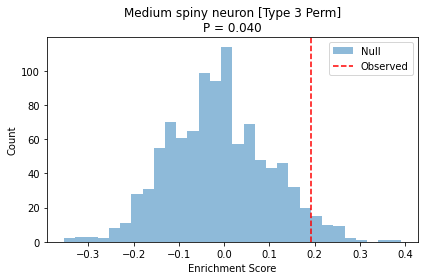

In [26]:
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('Medium spiny neuron [Type 3 Perm]\nP = {:.3f}'.format(P))
plt.legend()
plt.tight_layout()


In [217]:
CellType = "Medium spiny neuron"
cellType_idx = Anno[Anno["Supercluster"] == CellType].index
#print(cellType_idx)
ASD_supercluster_biases = ASD_ALL_Bias.loc[cellType_idx, :]["EFFECT"]

In [218]:
Rand_gene_idx_gt_asd = []
test_dat = []
counter = 0
for i in range(len(Perm_Z2_BiasDFs_ASD_ALL_Type3)):
    df = Perm_Z2_BiasDFs_ASD_ALL_Type3[i]
    df_cellType = df.loc[cellType_idx, :]
    if df_cellType["EFFECT"].mean() > ASD_supercluster_biases.mean():
        Rand_gene_idx_gt_asd.append(i)
        test_dat.append(df_cellType["EFFECT"])
        print(i)
        counter += 1
    if counter > 5:
        break
print(counter)
test_dat = np.array(test_dat)


16
29
41
46
49
59
6


/tmp/ipykernel_92103/2665734782.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ASD_supercluster_biases] + [test_dat[i] for i in range(len(test_dat))],


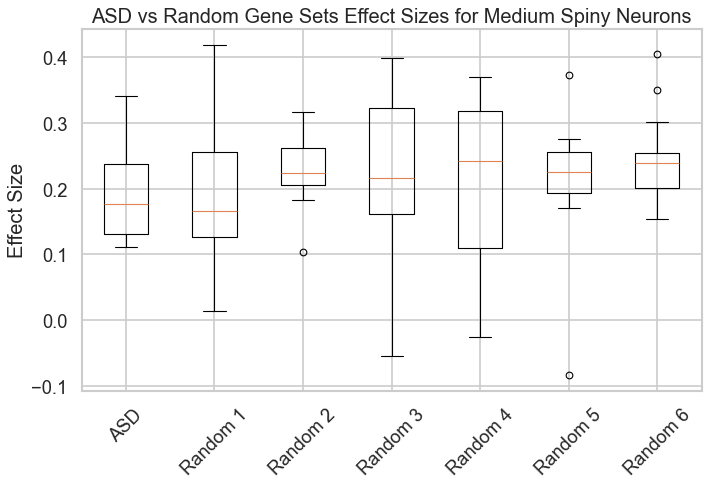


Mean values:
ASD: 0.191
Random 1: 0.197
Random 2: 0.233
Random 3: 0.226
Random 4: 0.212
Random 5: 0.216
Random 6: 0.241


In [219]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot([ASD_supercluster_biases] + [test_dat[i] for i in range(len(test_dat))], 
            labels=['ASD'] + [f'Random {i+1}' for i in range(len(test_dat))])
plt.ylabel('Effect Size')
plt.title('ASD vs Random Gene Sets Effect Sizes for Medium Spiny Neurons')
plt.xticks(rotation=45)
plt.show()

print("\nMean values:")
print(f"ASD: {ASD_supercluster_biases.mean():.3f}")
for i in range(len(test_dat)):
    print(f"Random {i+1}: {test_dat[i].mean():.3f}")

In [191]:
ASD_GW = Fil2Dict("../../ASD_Circuits/dat/Unionize_bias/Spark_Meta_EWS.GeneWeight.csv")
asd_Genes = list(ASD_GW.keys())

In [224]:
tmp_idx = 59
tmp_GW = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/ASD_ALL_Type3/{}.perm.GW.txt".format(tmp_idx), index_col=0, header=None)
tmp_Genes = tmp_GW.index.values



In [225]:
CellType = "Medium spiny neuron"
cellType_idx = Anno[Anno["Supercluster"] == CellType].index
print(cellType_idx)

super_cluster_biases = HumanCT_Z2.loc[:, cellType_idx].mean(axis=1)
super_cluster_ExpL = HumanCTExpL.loc[:, cellType_idx].mean(axis=1)

asd_genes_cluster_biases = HumanCT_Z2.loc[asd_Genes, cellType_idx].mean(axis=1)
asd_genes_cluster_ExpL = HumanCTExpL.loc[asd_Genes, cellType_idx].mean(axis=1)

rand_genes_cluster_biases = HumanCT_Z2.loc[tmp_Genes, cellType_idx].mean(axis=1)
rand_genes_cluster_ExpL = HumanCTExpL.loc[tmp_Genes, cellType_idx].mean(axis=1)


Int64Index([206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218,
            219, 220, 221, 427, 430],
           dtype='int64')


Text(0.02, 0.8, 'Random genes Z2>0: 29\nRandom genes Z2<0: 27')

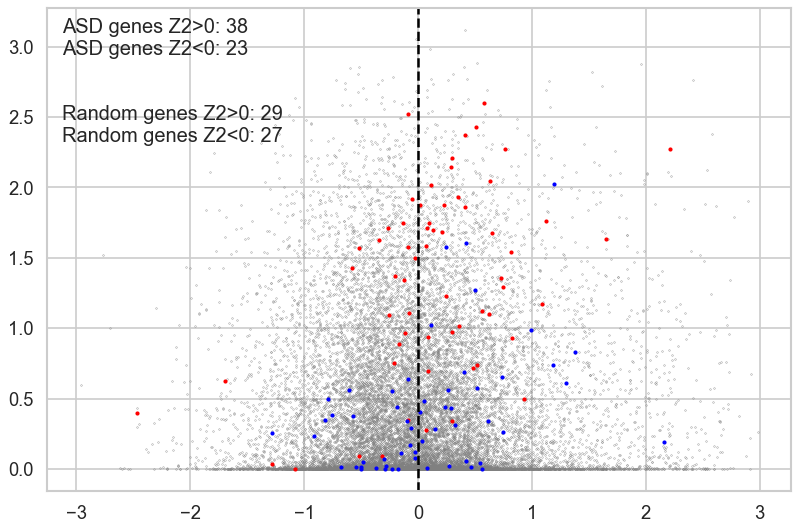

In [226]:

plt.figure(figsize=(12,8))
plt.scatter(super_cluster_biases, np.log2(super_cluster_ExpL+1), s=0.1, color="grey")
plt.scatter(asd_genes_cluster_biases, np.log2(asd_genes_cluster_ExpL+1), s=5, color="red")
plt.scatter(rand_genes_cluster_biases, np.log2(rand_genes_cluster_ExpL+1), s=5, color="blue")
plt.axvline(x=0, color='black', linestyle='--')

n_positive = sum(asd_genes_cluster_biases > 0)
n_negative = sum(asd_genes_cluster_biases < 0)
plt.text(0.02, 0.98, f'ASD genes Z2>0: {n_positive}\nASD genes Z2<0: {n_negative}', 
         transform=plt.gca().transAxes, verticalalignment='top')
n_positive = sum(rand_genes_cluster_biases > 0)
n_negative = sum(rand_genes_cluster_biases < 0)
plt.text(0.02, 0.80, f'Random genes Z2>0: {n_positive}\nRandom genes Z2<0: {n_negative}', 
         transform=plt.gca().transAxes, verticalalignment='top')


### SCZ 

In [39]:
BiasDIR = "/home/jw3514/Work/CellType_Psy/dat/Bias_Jan13_2025/"
SCZ_Bias = pd.read_csv("{}/HCT.SCZ61.Z2.HCT.csv".format(BiasDIR), index_col=0)

### Type 1: Randomly redistribute the mutations, and assign new weights to same genes

In [37]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/SCZ_Type1/"
SCZ_Perm_Z2_BiasDFs_TYPE1 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    SCZ_Perm_Z2_BiasDFs_TYPE1.append(Perm_Z2_Bias)

In [40]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE1)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE1)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE1)

Observed effect for CGE interneuron: 0.0895931573101583


P-value: 0.10889110889110887
Observed effect for MGE interneuron: 0.11737982872562679
P-value: 0.0009990009990009652
Observed effect for Medium spiny neuron: 0.060970124979646406
P-value: 0.35364635364635366


Observed effect for CGE interneuron: 0.0895931573101583
P-value: 0.10889110889110887


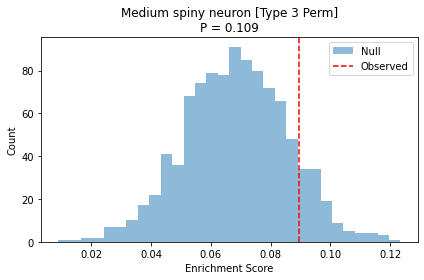

In [42]:
CT = "CGE interneuron"  
Obs, Null, Z, P = test_supercluster_enrichment(CT, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE1)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('Medium spiny neuron [Type 3 Perm]\nP = {:.3f}'.format(P))
plt.legend()
plt.tight_layout()

Observed effect for MGE interneuron: 0.11737982872562679
P-value: 0.0009990009990009652


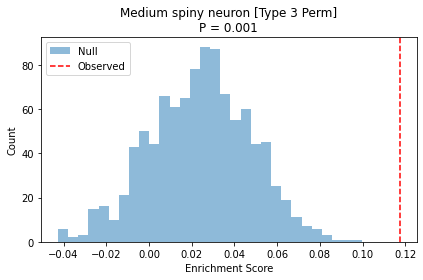

In [43]:
CT = "MGE interneuron"  
Obs, Null, Z, P = test_supercluster_enrichment(CT, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE1)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('Medium spiny neuron [Type 3 Perm]\nP = {:.3f}'.format(P))
plt.legend()
plt.tight_layout()

### Type 2: Randomly redistribute the mutations according to background mutation rate, and assign new weights to same genes

In [49]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/SCZ_Type2/"
SCZ_Perm_Z2_BiasDFs_TYPE2 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    SCZ_Perm_Z2_BiasDFs_TYPE2.append(Perm_Z2_Bias)


In [50]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE2)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE2)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE2)

Observed effect for CGE interneuron: 0.0895931573101583
P-value: 0.0009990009990009652
Observed effect for MGE interneuron: 0.11737982872562679
P-value: 0.16383616383616384
Observed effect for Medium spiny neuron: 0.060970124979646406
P-value: 0.0029970029970030065


In [51]:
# Create empty lists to store results
superclusters_list = []
pvalues_list = []

# Test each supercluster and save results
for supercluster in ALL_CTs:
    Obs, Null, Z, P = test_supercluster_enrichment(supercluster, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE2)
    superclusters_list.append(supercluster)
    pvalues_list.append(P)

# Create dataframe with results
results_df = pd.DataFrame({
    'Supercluster': superclusters_list,
    'P_value': pvalues_list
})

# Calculate FDR-corrected p-values
results_df['FDR'] = multipletests(results_df['P_value'], method='fdr_bh')[1]

# Sort by FDR-corrected p-value
results_df = results_df.sort_values('FDR')

Observed effect for Amygdala excitatory: 0.19230703814653177
P-value: 0.10889110889110887
Observed effect for CGE interneuron: 0.0895931573101583
P-value: 0.0009990009990009652
Observed effect for Cerebellar inhibitory: -0.03351276926378606
P-value: 0.8861138861138861
Observed effect for Deep-layer corticothalamic and 6b: 0.051912691755951854
P-value: 0.34065934065934067
Observed effect for Deep-layer intratelencephalic: 0.18956840645118367
P-value: 0.17182817182817178
Observed effect for Deep-layer near-projecting: 0.11983291364649395
P-value: 0.060939060939060985
Observed effect for Eccentric medium spiny neuron: 0.15704530589786983
P-value: 0.0009990009990009652
Observed effect for Hippocampal CA1-3: 0.1433646626139966
P-value: 0.3996003996003996
Observed effect for Hippocampal CA4: 0.04032857166487854
P-value: 0.997002997002997
Observed effect for Hippocampal dentate gyrus: 0.022158339812198617
P-value: 0.989010989010989
Observed effect for LAMP5-LHX6 and Chandelier: 0.072422373019

In [52]:
results_df

,Supercluster,P_value,FDR
1,CGE interneuron,0.000999,0.006194
28,Oligodendrocyte,0.000999,0.006194
6,Eccentric medium spiny neuron,0.000999,0.006194
20,Upper-layer intratelencephalic,0.000999,0.006194
29,Oligodendrocyte precursor,0.000999,0.006194
17,Splatter,0.001998,0.010323
14,Medium spiny neuron,0.002997,0.013272
24,Committed oligodendrocyte precursor,0.015984,0.061938
10,LAMP5-LHX6 and Chandelier,0.020979,0.072261
26,Fibroblast,0.030969,0.096004


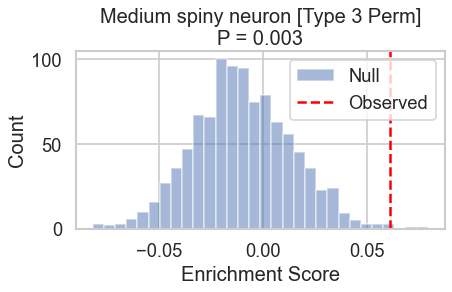

In [313]:
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('Medium spiny neuron [Type 3 Perm]\nP = {:.3f}'.format(P))
plt.legend()
plt.tight_layout()

### Type 3: Randomly redistribute the mutations according to background mutation rate, and assign new weights to same genes

In [314]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/SCZ_Type3/"
SCZ_Perm_Z2_BiasDFs_TYPE3 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    SCZ_Perm_Z2_BiasDFs_TYPE3.append(Perm_Z2_Bias)


In [315]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE3)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE3)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE3)

Observed effect for CGE interneuron: 0.0895931573101583
P-value: 1.0
Observed effect for MGE interneuron: 0.11737982872562679
P-value: 0.999000999000999
Observed effect for Medium spiny neuron: 0.060970124979646406
P-value: 0.981018981018981


Observed effect for MGE interneuron: 0.11737982872562679
P-value: 0.999000999000999


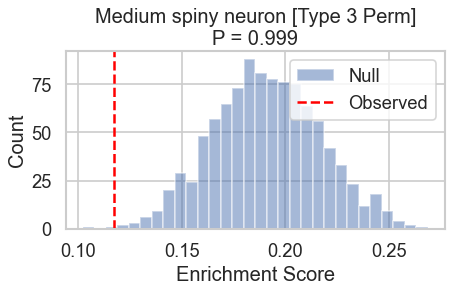

In [316]:
#Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE3)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE3)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('Medium spiny neuron [Type 3 Perm]\nP = {:.3f}'.format(P))
plt.legend()
plt.tight_layout()

### type 4 

In [317]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/SCZ_Type4/"
SCZ_Perm_Z2_BiasDFs_TYPE4 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    SCZ_Perm_Z2_BiasDFs_TYPE4.append(Perm_Z2_Bias)


In [318]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)

Observed effect for CGE interneuron: 0.0895931573101583
P-value: 0.1558441558441559
Observed effect for MGE interneuron: 0.11737982872562679
P-value: 0.11088911088911091
Observed effect for Medium spiny neuron: 0.060970124979646406
P-value: 0.28771228771228774


Observed effect for MGE interneuron: 0.11737982872562679
P-value: 0.11088911088911091


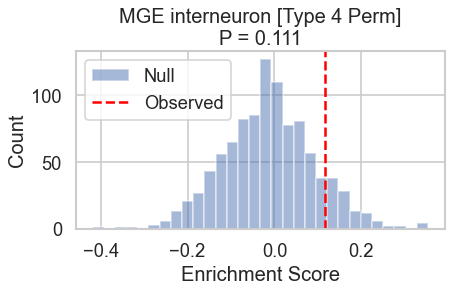

In [320]:
#Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
CT = "MGE interneuron"  
Obs, Null, Z, P = test_supercluster_enrichment(CT, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
#CT = "MGE interneuron"
#Obs, Null, Z, P = test_supercluster_enrichment(CT, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('{} [Type 4 Perm]\nP = {:.3f}'.format(CT, P))
plt.legend()
plt.tight_layout()

### NDD 

In [27]:
BiasDIR = "/home/jw3514/Work/CellType_Psy/dat/Bias_Jan13_2025/"
NDD_Bias = pd.read_csv("{}/HCT.DDDHC.Z2.HCT.top61.csv".format(BiasDIR), index_col=0)

In [28]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/NDD_Type1/"
NDD_Perm_Z2_BiasDFs_TYPE1 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    NDD_Perm_Z2_BiasDFs_TYPE1.append(Perm_Z2_Bias)

In [29]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE1)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE1)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE1)

Observed effect for CGE interneuron: 0.27736732222906674
P-value: 0.8131868131868132
Observed effect for MGE interneuron: 0.06777790850920257
P-value: 0.1298701298701299
Observed effect for Medium spiny neuron: 0.1355090872732989
P-value: 0.11888111888111885


Observed effect for CGE interneuron: 0.27736732222906674
P-value: 0.8131868131868132


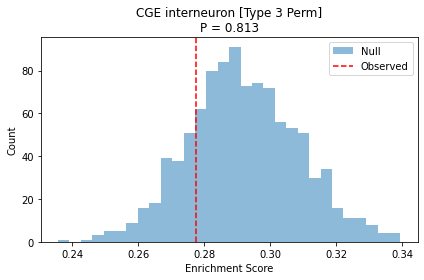

In [30]:
#Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
CT = "CGE interneuron"  
#CT = "MGE interneuron"  
Obs, Null, Z, P = test_supercluster_enrichment(CT, NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE1)
#CT = "MGE interneuron"
#Obs, Null, Z, P = test_supercluster_enrichment(CT, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('{} [Type 3 Perm]\nP = {:.3f}'.format(CT, P))
plt.legend()
plt.tight_layout()

In [31]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/NDD_Type2/"
NDD_Perm_Z2_BiasDFs_TYPE2 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    NDD_Perm_Z2_BiasDFs_TYPE2.append(Perm_Z2_Bias)

In [32]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE2)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE2)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE2)

Observed effect for CGE interneuron: 0.27736732222906674
P-value: 0.972027972027972
Observed effect for MGE interneuron: 0.06777790850920257
P-value: 1.0
Observed effect for Medium spiny neuron: 0.1355090872732989
P-value: 0.999000999000999


Observed effect for MGE interneuron: 0.06777790850920257
P-value: 1.0


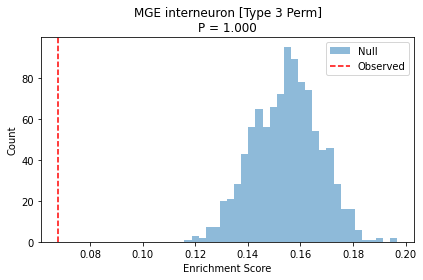

In [33]:
#Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
#CT = "CGE interneuron"  
CT = "MGE interneuron"  
Obs, Null, Z, P = test_supercluster_enrichment(CT, NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE2)
#CT = "MGE interneuron"
#Obs, Null, Z, P = test_supercluster_enrichment(CT, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('{} [Type 3 Perm]\nP = {:.3f}'.format(CT, P))
plt.legend()
plt.tight_layout()

In [34]:
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/WeightRedistribute_Jan17/NDD_Type3/"
NDD_Perm_Z2_BiasDFs_TYPE3 = []
for i in np.arange(1000):
    Perm_Z2_Bias = pd.read_csv("{}/{}.perm.Z2.csv.gz".format(DIR, i), index_col=0)
    NDD_Perm_Z2_BiasDFs_TYPE3.append(Perm_Z2_Bias)

In [35]:
Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE3)
Obs, Null, Z, P = test_supercluster_enrichment("MGE interneuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE3)
Obs, Null, Z, P = test_supercluster_enrichment("Medium spiny neuron", NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE3)

Observed effect for CGE interneuron: 0.27736732222906674
P-value: 0.0019980019980020414
Observed effect for MGE interneuron: 0.06777790850920257
P-value: 0.19480519480519476
Observed effect for Medium spiny neuron: 0.1355090872732989
P-value: 0.10389610389610393


Observed effect for CGE interneuron: 0.27736732222906674
P-value: 0.0019980019980020414


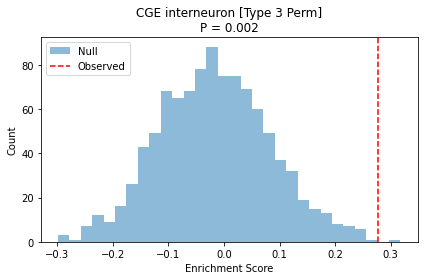

In [36]:
#Obs, Null, Z, P = test_supercluster_enrichment("CGE interneuron", SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
CT = "CGE interneuron"  
Obs, Null, Z, P = test_supercluster_enrichment(CT, NDD_Bias, NDD_Perm_Z2_BiasDFs_TYPE3)
#CT = "MGE interneuron"
#Obs, Null, Z, P = test_supercluster_enrichment(CT, SCZ_Bias, SCZ_Perm_Z2_BiasDFs_TYPE4)
plt.figure(figsize=(6,4))
plt.hist(Null, bins=30, alpha=0.5, label='Null')
plt.axvline(Obs, color='red', linestyle='--', label='Observed')
plt.xlabel('Enrichment Score')
plt.ylabel('Count')
plt.title('{} [Type 3 Perm]\nP = {:.3f}'.format(CT, P))
plt.legend()
plt.tight_layout()

# End Test

In [12]:
HCT_Z2_MAT_HCT_clip = pd.read_csv("../dat/HumanCTExpressionMats/Human.CT.Exp.Entrez.log2.Z2.HCT.z1clip3.csv", index_col=0)
max_Z, min_Z = 3, -3
HCT_Z2_MAT_HCT_clip = HCT_Z2_MAT_HCT_clip.clip(upper=max_Z, lower=min_Z)

In [13]:
HCT_Z2_MAT_HCT = pd.read_csv("../dat/HumanCTExpressionMats/Human.CT.Exp.Entrez.log2.Z2.HCT.csv", index_col=0)
max_Z, min_Z = 5, -5
HCT_Z2_MAT_HCT = HCT_Z2_MAT_HCT.clip(upper=max_Z, lower=min_Z)

In [14]:
ASD_GW = Fil2Dict("../../ASD_Circuits/dat/Unionize_bias/Spark_Meta_EWS.GeneWeight.csv")
SCZ_GW = Fil2Dict("../dat3/SCZ.top61.gw.csv")
X22q_GW = Fil2Dict("../dat3/22q.v2.gw.csv")

In [16]:
BGMR = pd.read_csv("~/Work/Resources/MutationRate_20170710_rate.txt", delimiter="\t")
BGMR["Entrez"] = [int(GeneSymbol2Entrez.get(x, -1)) for x in BGMR["GeneName"].values]
BGMR = BGMR[BGMR["Entrez"].isin(HCT_Z2_MAT_HCT.index.values)]
BGMR.index = BGMR["Entrez"].values
#BGMR["Mutability_Dmg"] = BGMR["p_LGD"] + BGMR["prevel_0.5"]
#BGMR["Mutability_syn"] = BGMR["p_synonymous"]

/tmp/ipykernel_514276/2728521219.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  BGMR = pd.read_csv("~/Work/Resources/MutationRate_20170710_rate.txt", delimiter="\t")


In [243]:
Spark_Denovo = pd.read_excel("../../ASD_Circuits/notebooks_v2/dat_in/41588_2022_1148_MOESM4_ESM.xlsx",
                           skiprows=2, sheet_name="Table S7")
Spark_Denovo = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]!="."]
Spark_Denovo_ExomeWide = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]<=2.5e-6]
Spark_Denovo_ExomeWide.shape

(63, 56)

In [244]:
Spark_Denovo_ExomeWide.to_csv("../dat/GeneWeights/ASD.ExomeWide.Denovo.csv", index=False)

In [18]:
Mut_n_IQ = pd.read_csv("../dat/ASD_IQ_Mut.csv")
Mut_n_IQ = Mut_n_IQ[Mut_n_IQ["Entrez"].isin(HCT_Z2_MAT_HCT.index.values)]
Mut_n_IQ.columns.values

array(['IID', 'Sex', 'Pheno', 'VarID', 'GeneID', 'HGNC', 'GeneEff',
       'REVEL', 'ExACpLI', 'Entrez', 'IQ'], dtype=object)

In [19]:
top_Genes = Spark_Denovo.head(61)["HGNC"].values
Mut_n_IQ_conf = Mut_n_IQ[Mut_n_IQ["HGNC"].isin(top_Genes)]
Mut_n_IQ_conf.shape

(221, 11)

In [20]:
HighIQMuts = Mut_n_IQ_conf[Mut_n_IQ_conf["IQ"]>70]
LowIQMuts = Mut_n_IQ_conf[Mut_n_IQ_conf["IQ"]<=70]

In [462]:
HighIQMuts.head(2)

,IID,Sex,Pheno,VarID,GeneID,HGNC,GeneEff,REVEL,ExACpLI,Entrez,IQ
11,08C77167,Male,Affected,17:60650729:G:GT,ENSG00000146872,TLK2,splice_donor,.,0.999999806,11011,89.0
14,08C74145,Male,Affected,14:21865980:A:T,ENSG00000100888,CHD8,splice_donor,.,1,57680,100.0


In [23]:
HighIQMuts.to_csv("../dat/GeneWeights/ASD.HighIQ.Mutable.csv", index=False)
LowIQMuts.to_csv("../dat/GeneWeights/ASD.LowIQ.Mutable.csv", index=False)
Mut_n_IQ_conf.to_csv("../dat/GeneWeights/ASD.All.Mutable.csv", index=False)

In [22]:
HighIQMuts["Entrez"].unique()

array([ 11011,  57680,  10847,  22941,   4763,   1859,   5991,   1778,
          287,  80816,  64599,  80155, 253738,  55870,  51317,  10765,
         5728,  51111,  58508,  23135,  29123,  23040,   6529,   2904,
         1106,   4849,   6326,   1788,  10716,  23126,   8452,  23001,
         8831,  57492,   6096,  51322,   4297,  23389,   7249,   4204,
        27086,   3786])

In [432]:
def normalize(probs):
    prob_factor = 1 / sum(probs)
    return [prob_factor * p for p in probs]
def Reduce(List, Counts):
    res = []
    Counts = list(Counts)
    for L in List:
        res.append(Counts.count(L))
    return res
def Table2GW_ASD(Mutable):
    gene2MutN = {}
    for g, row in Mutable.iterrows():
        gene2MutN[g] = row["NLGD"] * 0.554 + row["NDmis"] * 0.333
    return gene2MutN

def SingleSet_ReWeights_ASD(DZ_Muts, BGMR):
    N_LGD = DZ_Muts[DZ_Muts["GeneEff"]!="missense"].shape[0]
    N_Dmis = DZ_Muts[DZ_Muts["GeneEff"]=="missense"].shape[0]
    
    Genes = DZ_Muts["Entrez"].unique()
    LGD_P = []
    Dmis_P = []
    for g in Genes:
        try:
            LGD_P.append(BGMR.loc[g, "p_LGD"])
            Dmis_P.append(BGMR.loc[g, "prevel_0.5"])
        except:
            LGD_P.append(BGMR["p_LGD"].mean())
            Dmis_P.append(BGMR["prevel_0.5"].mean())
            
    Permed_LGD = np.random.choice(Genes, size=N_LGD, p=normalize(LGD_P))
    Permed_LGD_Count = Reduce(Genes, Permed_LGD)
    Permed_Dmis = np.random.choice(Genes, size=N_Dmis, p=normalize(Dmis_P))
    Permed_Dmis_Count = Reduce(Genes, Permed_Dmis)
    tmp_Mutable = pd.DataFrame(data={"Entrez":Genes, "NLGD":Permed_LGD_Count,
                                    "NDmis":Permed_Dmis_Count})
    tmp_Mutable = tmp_Mutable.set_index("Entrez")
    perm_GW = Table2GW_ASD(tmp_Mutable)
    return perm_GW

def Table2GW_SCZ(Mutable):
    gene2MutN = {}
    for g, row in Mutable.iterrows():
        gene2MutN[g] = row["NLGD"] * 0.554 + row["NDmis"] * 0.333
    return gene2MutN

def SingleSet_ReWeight_SCZ(SCZ_MutDF):
    #Mut_types = ["PTV", "mis3", "mis2"]
    N_PTV = SCZ_MutDF["Case PTV"].sum()
    N_mis3 = SCZ_MutDF["Case mis3"].sum()
    N_mis2 = SCZ_MutDF["Case mis2"].sum()
    
    Genes = SCZ_MutDF["Entrez"].unique()
    PTV_P, mis3_P, mis3_P = [],[],[],
    for g in Genes:
        PTV_P.append(SCZ_MutDF.loc[g, "Ctrl PTV"]+1)
        mis3_P.append(SCZ_MutDF.loc[g, "Ctrl mis3"]+1)
        mis2_P.append(SCZ_MutDF.loc[g, "Ctrl mis2"]+1)
            
    Permed_LGD = np.random.choice(Genes, size=N_PTV, p=normalize(PTV_P))
    Permed_LGD_Count = Reduce(Genes, Permed_LGD)
    Permed_mis3 = np.random.choice(Genes, size=N_mis3, p=normalize(mis3_P))
    Permed_mis3_Count = Reduce(Genes, Permed_Dmis)
    Permed_mis2 = np.random.choice(Genes, size=N_mis2, p=normalize(mis2_P))
    Permed_mis2_Count = Reduce(Genes, Permed_Dmis)
    
    tmp_Mutable = pd.DataFrame(data={"Entrez":Genes, "Case PTV":Permed_LGD_Count,
                                    "Case mis3":Permed_mis3_Count, "Case mis2":Permed_mis2_Count})
    tmp_Mutable = tmp_Mutable.set_index("Entrez")
    perm_GW = Table2GW_SCZ(tmp_Mutable)
    return perm_GW

In [460]:
perm_GW = SingleSet_ReWeights_ASD(HighIQMuts, BGMR)
perm_GW_Bias = AvgCTZ_Weighted(HCT_Z2_MAT_HCT, perm_GW, Method = 1)
perm_GW_Bias = AnnotateCTDat(perm_GW_Bias, Anno)

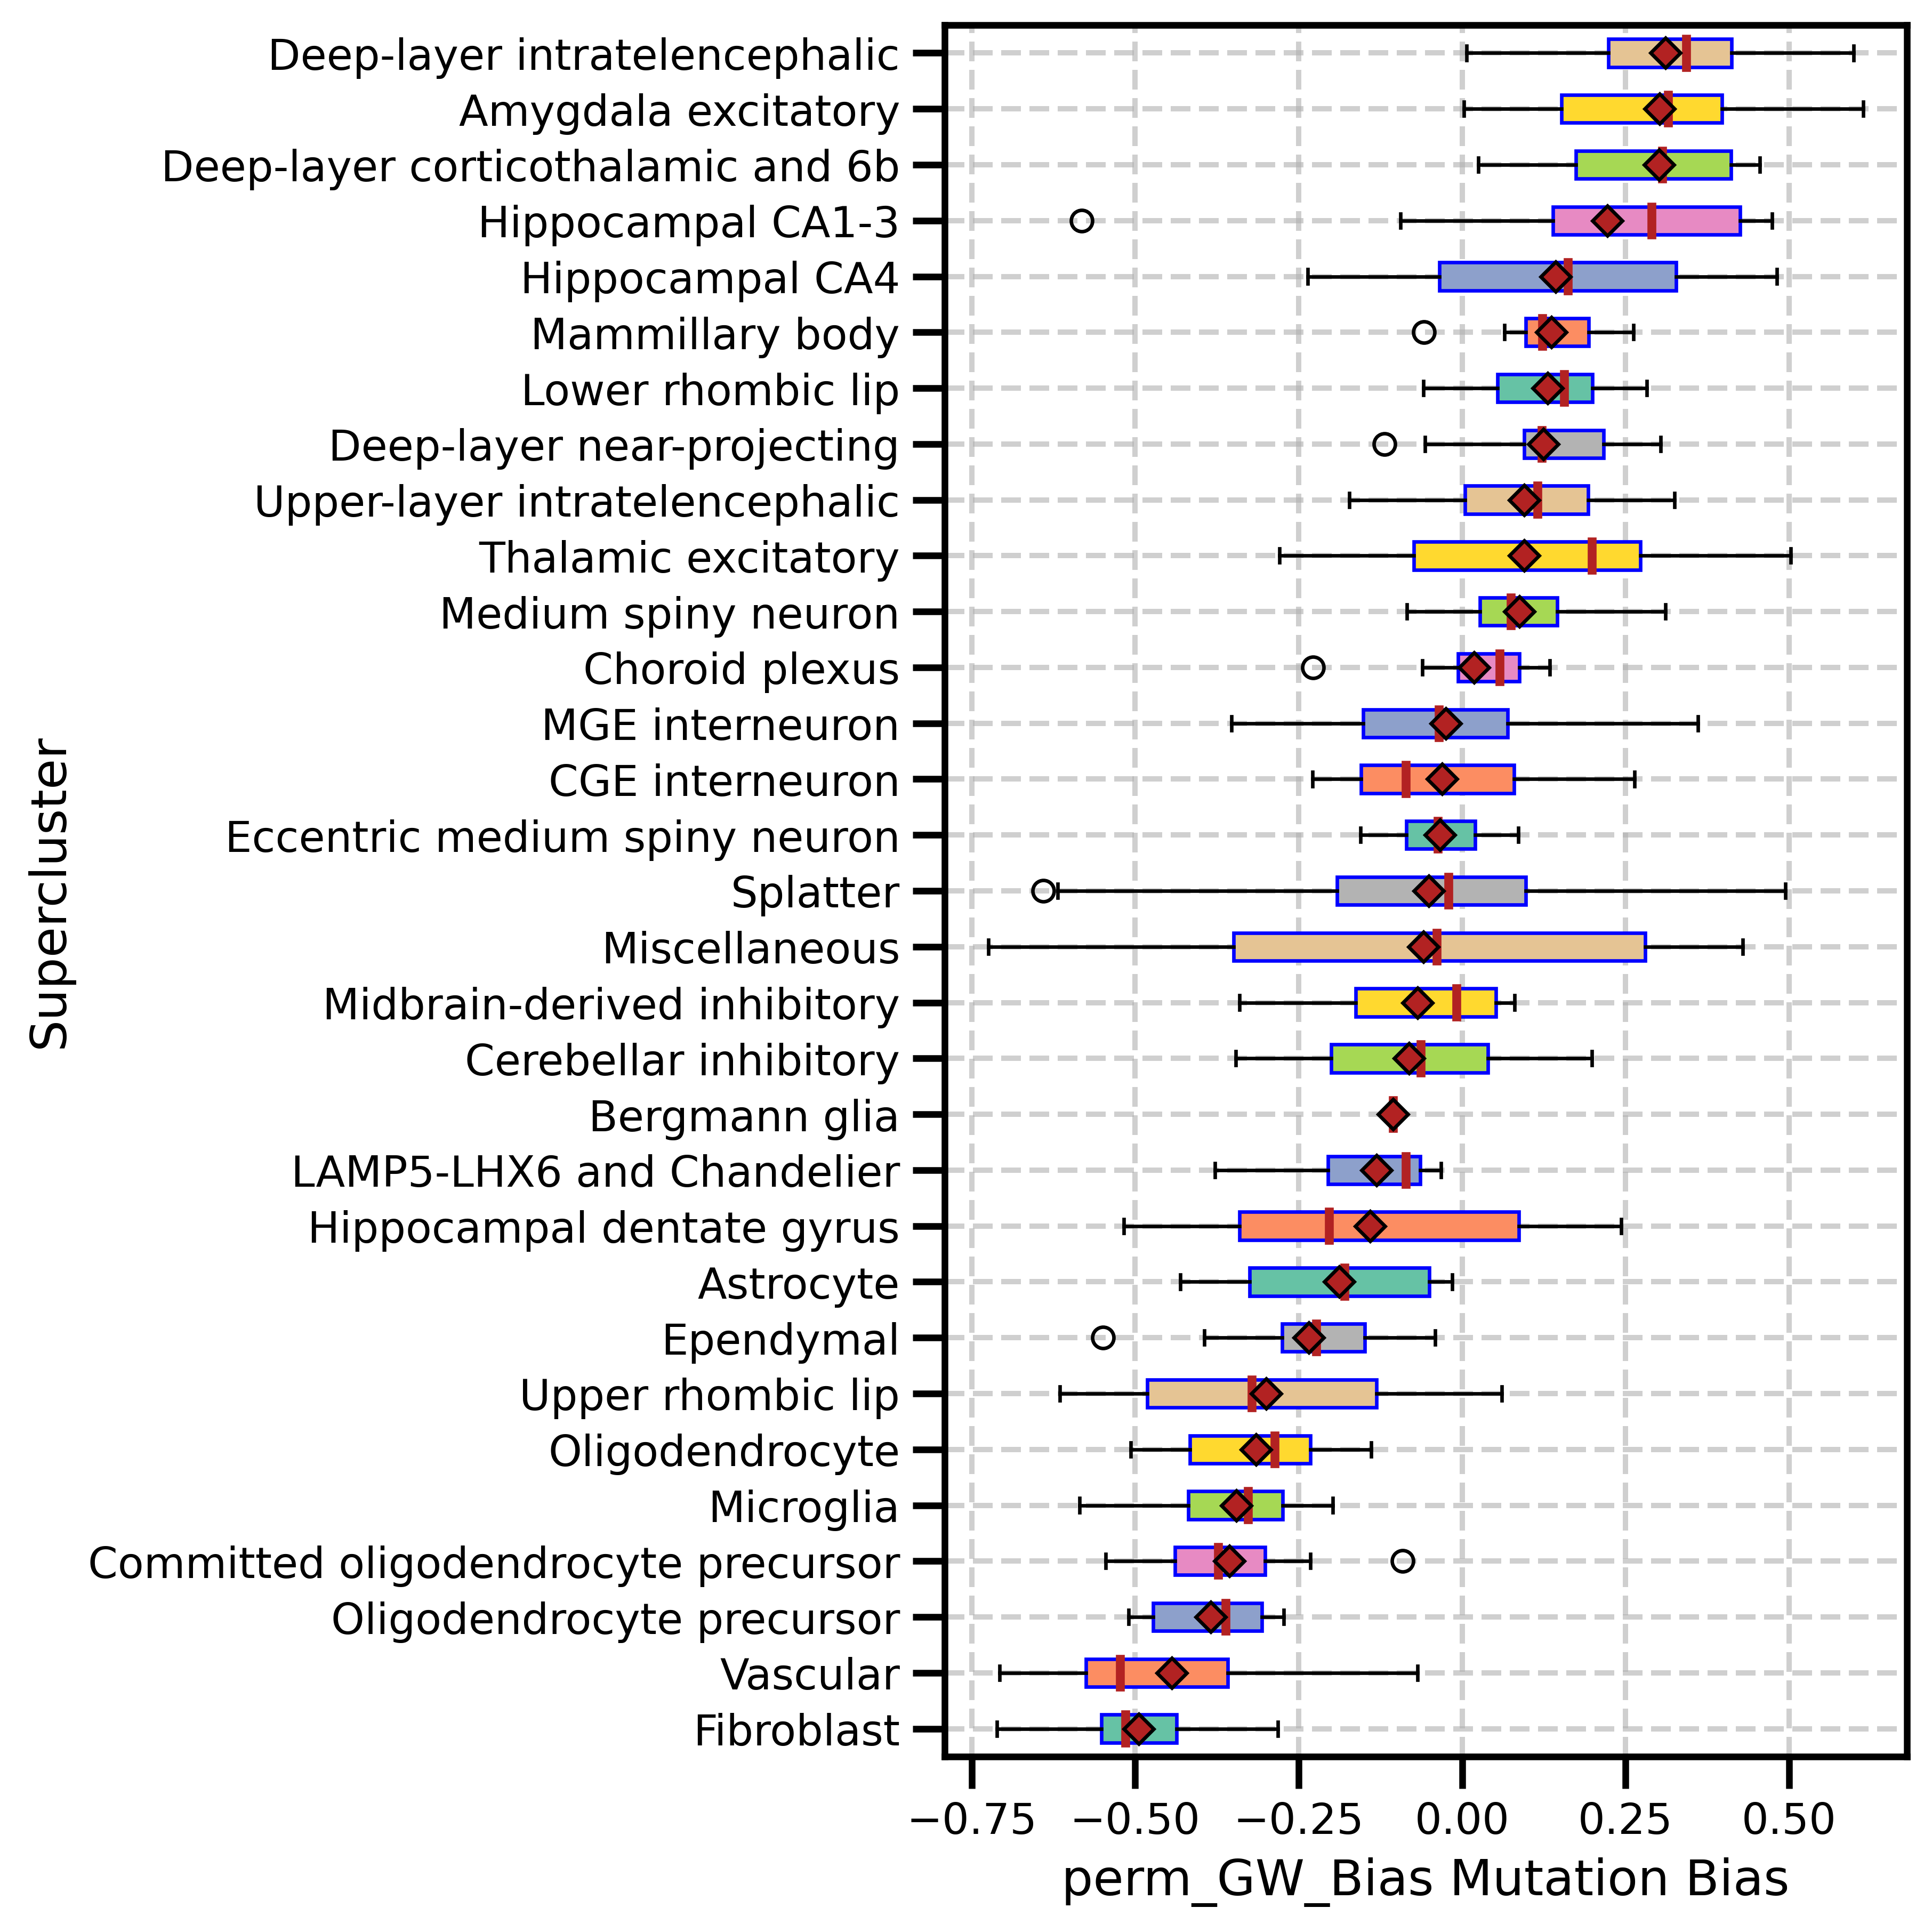

In [461]:
SuperClusterBias_BoxPlot(perm_GW_Bias, "perm_GW_Bias")

### For SCZ

In [56]:
GeneDF = pd.read_excel("/home/jw3514/Work/ASD_Circuits/dat/genes/scz/41586_2022_4556_MOESM3_ESM.xlsx",
                    sheet_name="Table S5 - Gene Results")
ExAC_pLI = pd.read_csv("/home/jw3514/Work/Resources/gnomad.v2.1.1.lof_metrics.by_gene.txt", sep="\t",
                      index_col="gene")

In [57]:
def oddsratio(NcaseMut, NctrlMut, dnvCount, Ncase = 24248, Nctrl=97322):
    if dnvCount!=dnvCount:
        dnvCount = 0
    NcaseMut += 1
    NctrlMut += 1
    AD = (NcaseMut) * (Nctrl-NctrlMut) 
    BC = (NctrlMut) * (Ncase-NcaseMut)
    return AD/BC + dnvCount

def Penetrance(NcaseMut, NctrlMut, Ncase = 24248, Nctrl=97322, prevelence=0.45/100):
    NcaseMut += 1
    NctrlMut += 1
    Ntotal_ =  Ncase/prevelence
    Nctrl_ = Ntotal_ - Ncase
    NctrlMut_ = Nctrl_*(NctrlMut/Nctrl)
    #print(Nctrl_, NctrlMut_)
    p = NcaseMut/(NcaseMut+NctrlMut_)
    return p

In [58]:
def ModifyMutCount(CaseCount, ContCount, dnvCount, CaseN=24248, ContN=97322):
    if dnvCount!=dnvCount:
        dnvCount = 0
    return max(CaseCount - ContCount / ContN * CaseN + dnvCount, 0)

for i, row in GeneDF.iterrows():
    symbol = GeneDF.loc[i, "Gene Symbol"]
    try:
        GeneDF.loc[i, "Entrez"] = int(GeneSymbol2Entrez[symbol])
    except:
        GeneDF.loc[i, "Entrez"] = None
    try:
        GeneDF.loc[i, "pLI"] = ExAC_pLI.loc[symbol, "pLI"]
    except:
        GeneDF.loc[i, "pLI"] = 0
        
    
    GeneDF.loc[i, "nLGD"] = ModifyMutCount(GeneDF.loc[i, "Case PTV"], 
                                    GeneDF.loc[i, "Ctrl PTV"], GeneDF.loc[i, "De novo PTV"]) 
    GeneDF.loc[i, "nMis3"] = ModifyMutCount(GeneDF.loc[i, "Case mis3"], 
                                    GeneDF.loc[i, "Ctrl mis3"], GeneDF.loc[i, "De novo mis3"]) 
    GeneDF.loc[i, "nMis2"] = ModifyMutCount(GeneDF.loc[i, "Case mis2"], 
                                    GeneDF.loc[i, "Ctrl mis2"], GeneDF.loc[i, "De novo mis2"]) 
    GeneDF.loc[i, "LGD_OR"] = oddsratio(GeneDF.loc[i, "Case PTV"], 
                                    GeneDF.loc[i, "Ctrl PTV"], GeneDF.loc[i, "De novo PTV"])
    GeneDF.loc[i, "Mis3_OR"] = oddsratio(GeneDF.loc[i, "Case mis3"], 
                                    GeneDF.loc[i, "Ctrl mis3"], GeneDF.loc[i, "De novo mis3"])
    GeneDF.loc[i, "Mis2_OR"] = oddsratio(GeneDF.loc[i, "Case mis2"], 
                                    GeneDF.loc[i, "Ctrl mis2"], GeneDF.loc[i, "De novo mis2"])
    
    GeneDF.loc[i, "LGD_pen"] = Penetrance(GeneDF.loc[i, "Case PTV"], 
                                    GeneDF.loc[i, "Ctrl PTV"])
    GeneDF.loc[i, "Mis3_pen"] = Penetrance(GeneDF.loc[i, "Case mis3"], 
                                    GeneDF.loc[i, "Ctrl mis3"])
    GeneDF.loc[i, "Mis2_pen"] = Penetrance(GeneDF.loc[i, "Case mis2"], 
                                    GeneDF.loc[i, "Ctrl mis2"])

GeneDF = GeneDF.dropna(subset="Entrez")
GeneDF = GeneDF.set_index("Entrez")
GeneDF = GeneDF[GeneDF.index.isin(CT_Z2_MAT_HC.index.values)]
GeneDF.to_csv("../dat3/SCZ.ALLGENE.MutCountModified.csv")
GeneDF.shape

(17067, 40)

In [418]:
def Gene_Weights_SCZ(MutFil, allen_mouse_genes, usepLI=False, Bmis=False, out=None):
    gene2MutN = {}
    for i, row in MutFil.iterrows():
        try:
            g = int(i)
            if g not in allen_mouse_genes:
                print(g, "not in allen mouse dataset")
                continue
        except:
            print(g, "Error converting Entrez ID")
        if usepLI:
            try:
                pLI = float(row["pLI"])
            except:
                print(g, "don't have pLI score on file, set to 0")
                pLI = 0.0
            if pLI >= 0.5:
                gene2MutN[g] = row["nLGD"] * 0.26 + row["nMis3"] * 0.25 + row["nMis2"] * 0.06  
            else:
                gene2MutN[g] = row["nLGD"] * 0.01 + row["nMis3"] * 0.01 + row["nMis2"] * 0 
        else:
            #gene2MutN[g] = row["nLGD"] * 0.26 + row["nMis3"] * 0.25 + row["nMis2"] * 0.06
            gene2MutN[g] = row["Case PTV"] * 0.26 + row["Case mis3"] * 0.25 + row["Case mis2"] * 0.06
    if out != None:
        writer = csv.writer(open(out, 'wt'))
        for k,v in sorted(gene2MutN.items(), key=lambda x:x[1], reverse=True):
           writer.writerow([k,v]) 
    return gene2MutN

In [464]:
GeneDF.head(61).to_csv("../dat/GeneWeights/SCZ.top61.Mutable.csv")

In [419]:
SCZ_GW = Gene_Weights_SCZ(GeneDF.head(61), HCT_Z2_MAT_HCT.index.values, usepLI=False)
SCZ_Bias = AvgCTZ_Weighted(HCT_Z2_MAT_HCT_clip, SCZ_GW, Method = 1)
SCZ_Bias = AnnotateCTDat(SCZ_Bias, Anno)

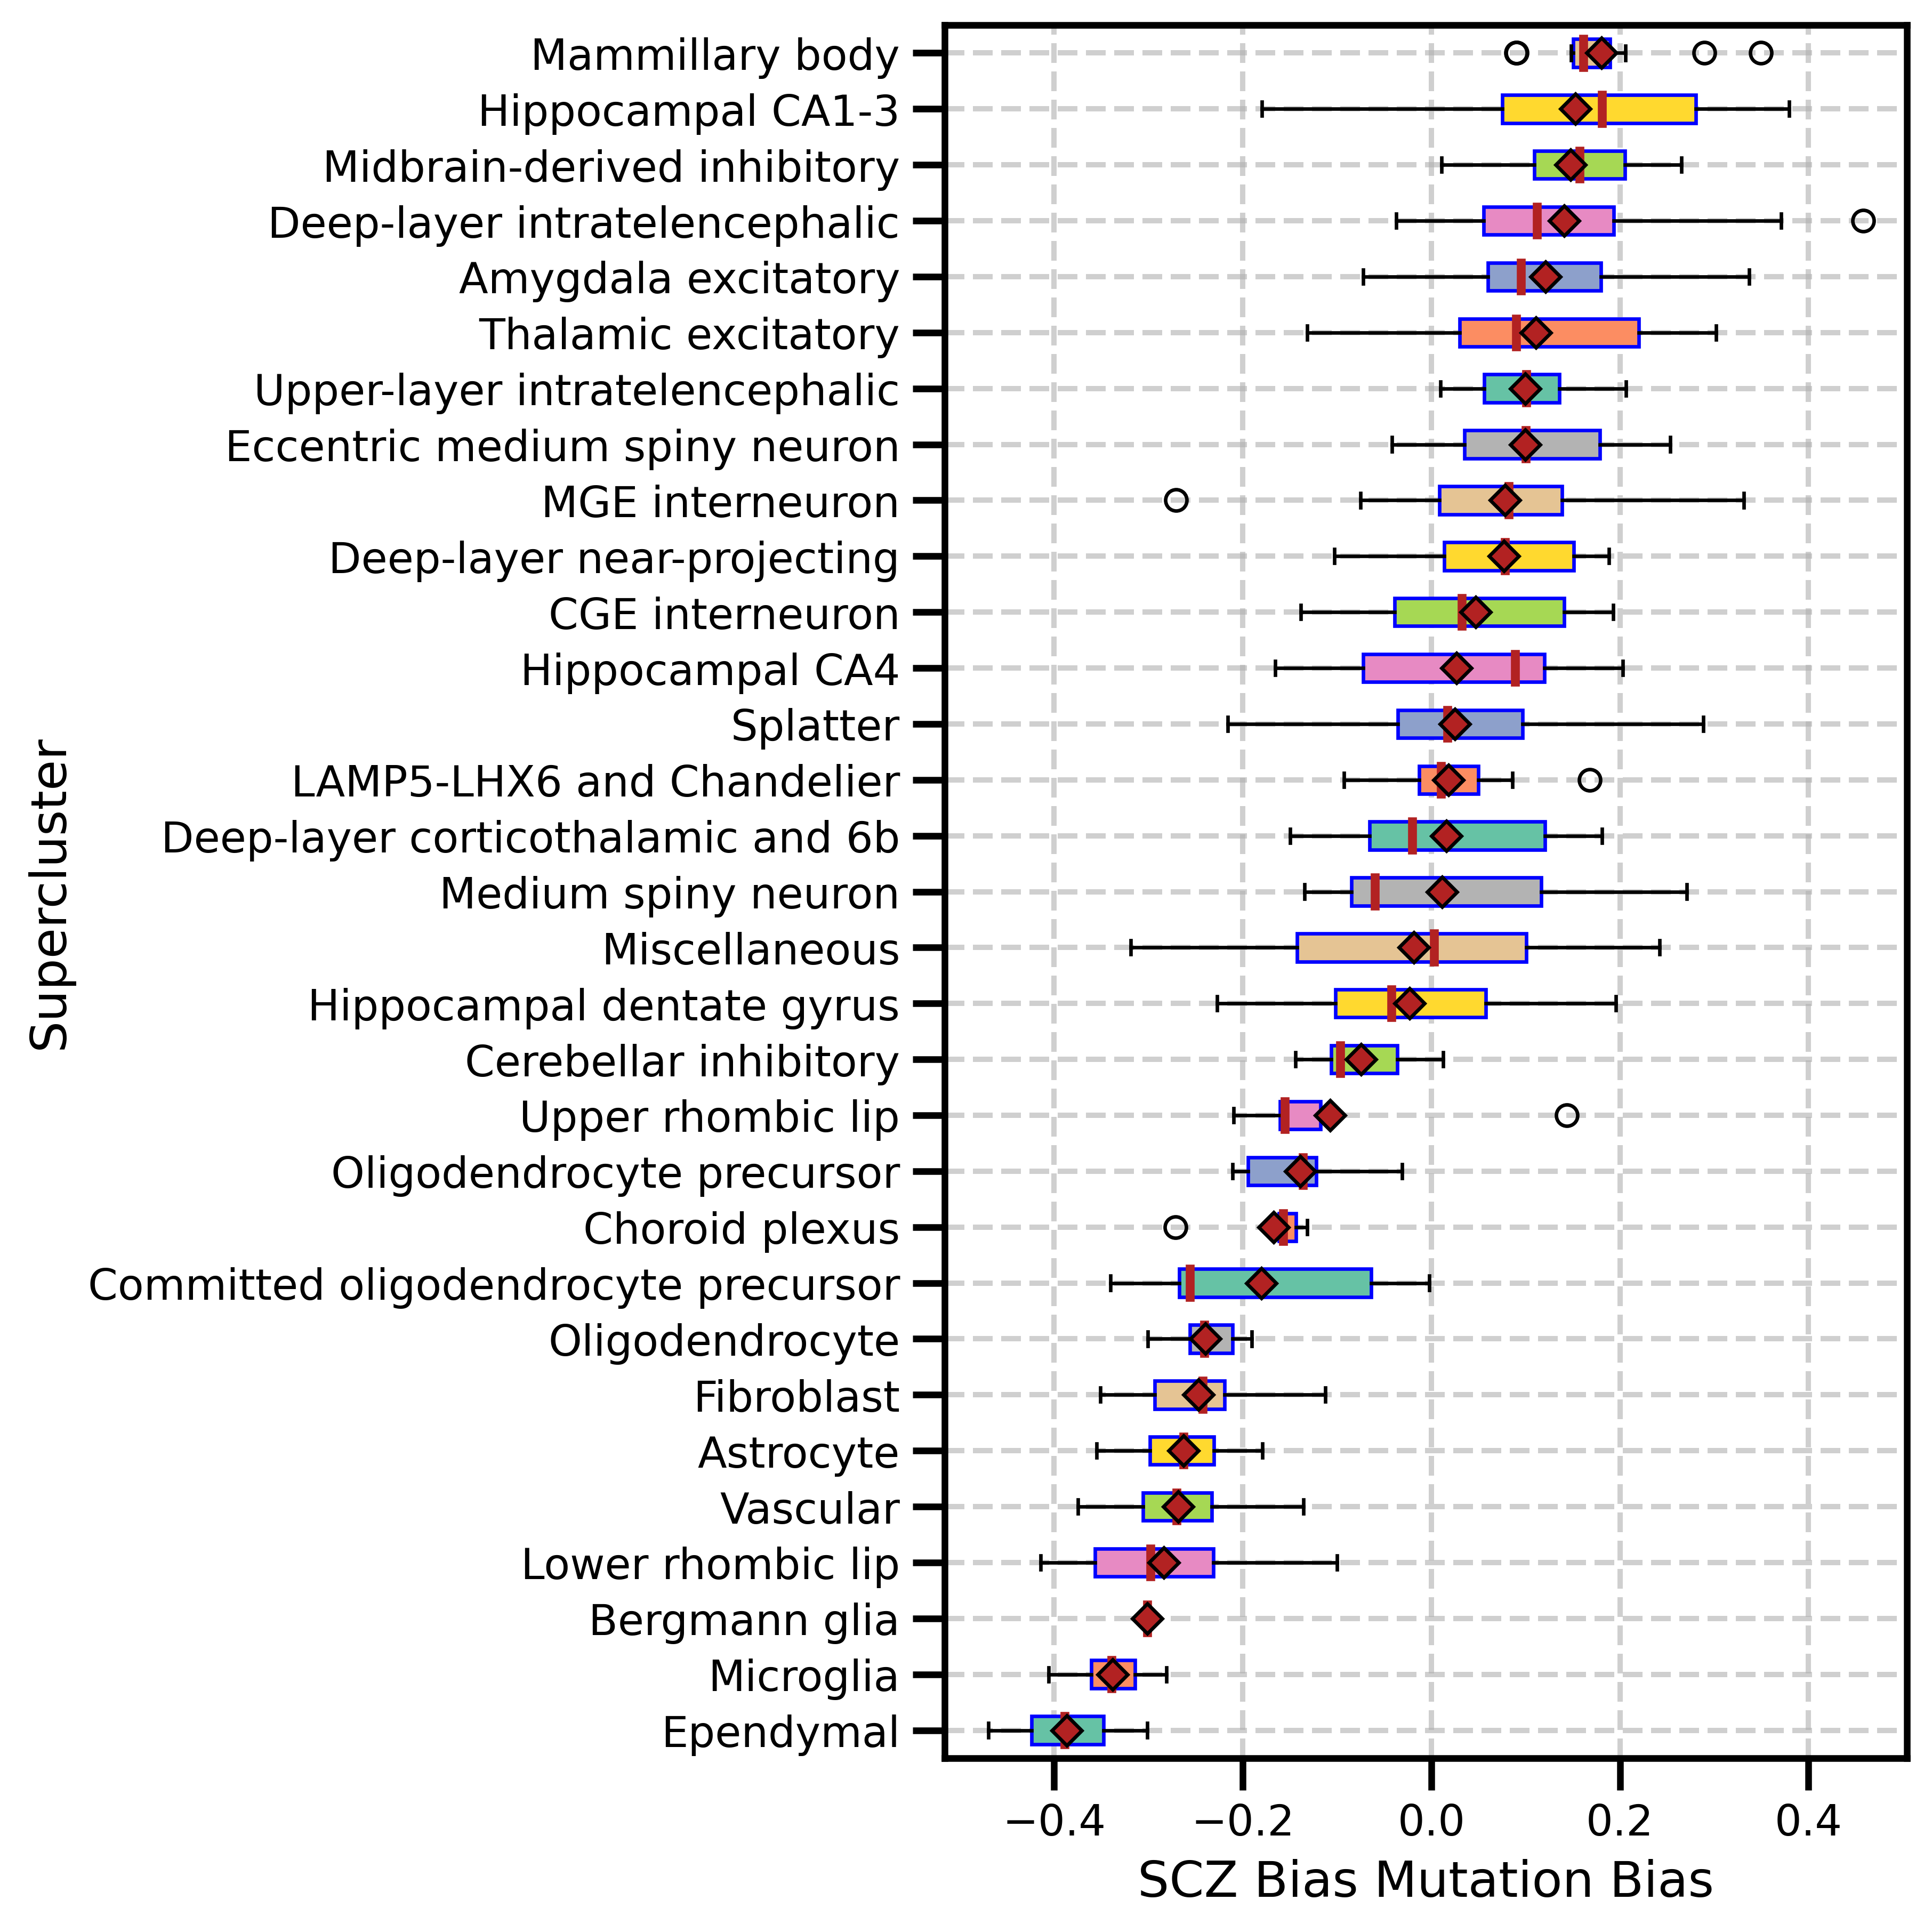

In [420]:
SuperClusterBias_BoxPlot(SCZ_Bias, "SCZ Bias")

In [446]:
def Table2GW_SCZ(Mutable):
    gene2MutN = {}
    for g, row in Mutable.iterrows():
        gene2MutN[g] = row["Case PTV"] * 0.26 + row["Case mis3"] * 0.25 + row["Case mis2"] * 0.06
    return gene2MutN
def SingleSet_ReWeight_SCZ(SCZ_MutDF):
    #Mut_types = ["PTV", "mis3", "mis2"]
    N_PTV = SCZ_MutDF["Case PTV"].sum().astype('int')
    N_mis3 = SCZ_MutDF["Case mis3"].sum().astype('int')
    N_mis2 = SCZ_MutDF["Case mis2"].sum().astype('int')
    
    Genes = SCZ_MutDF.index.unique()
    PTV_P, mis3_P, mis2_P = [],[],[],
    for g in Genes:
        PTV_P.append(SCZ_MutDF.loc[g, "Ctrl PTV"]+1)
        mis3_P.append(SCZ_MutDF.loc[g, "Ctrl mis3"]+1)
        mis2_P.append(SCZ_MutDF.loc[g, "Ctrl mis2"]+1)
            
    Permed_PTV = np.random.choice(Genes, size=N_PTV, p=normalize(PTV_P))
    Permed_PTV_Count = Reduce(Genes, Permed_PTV)
    Permed_mis3 = np.random.choice(Genes, size=N_mis3, p=normalize(mis3_P))
    Permed_mis3_Count = Reduce(Genes, Permed_mis3)
    Permed_mis2 = np.random.choice(Genes, size=N_mis2, p=normalize(mis2_P))
    Permed_mis2_Count = Reduce(Genes, Permed_mis2)
    
    tmp_Mutable = pd.DataFrame(data={"Entrez":Genes, "Case PTV":Permed_PTV_Count,
                                    "Case mis3":Permed_mis3_Count, "Case mis2":Permed_mis2_Count})
    tmp_Mutable = tmp_Mutable.set_index("Entrez")
    perm_GW = Table2GW_SCZ(tmp_Mutable)
    return perm_GW

In [448]:
SCZ_RW_GW = SingleSet_ReWeight_SCZ(GeneDF.head(61))

In [458]:
SCZ_RW_GW = SingleSet_ReWeight_SCZ(GeneDF.head(61))
RW_SCZ_Bias = AvgCTZ_Weighted(HCT_Z2_MAT_HCT_clip, SCZ_RW_GW)
RW_SCZ_Bias = AnnotateCTDat(RW_SCZ_Bias, Anno)

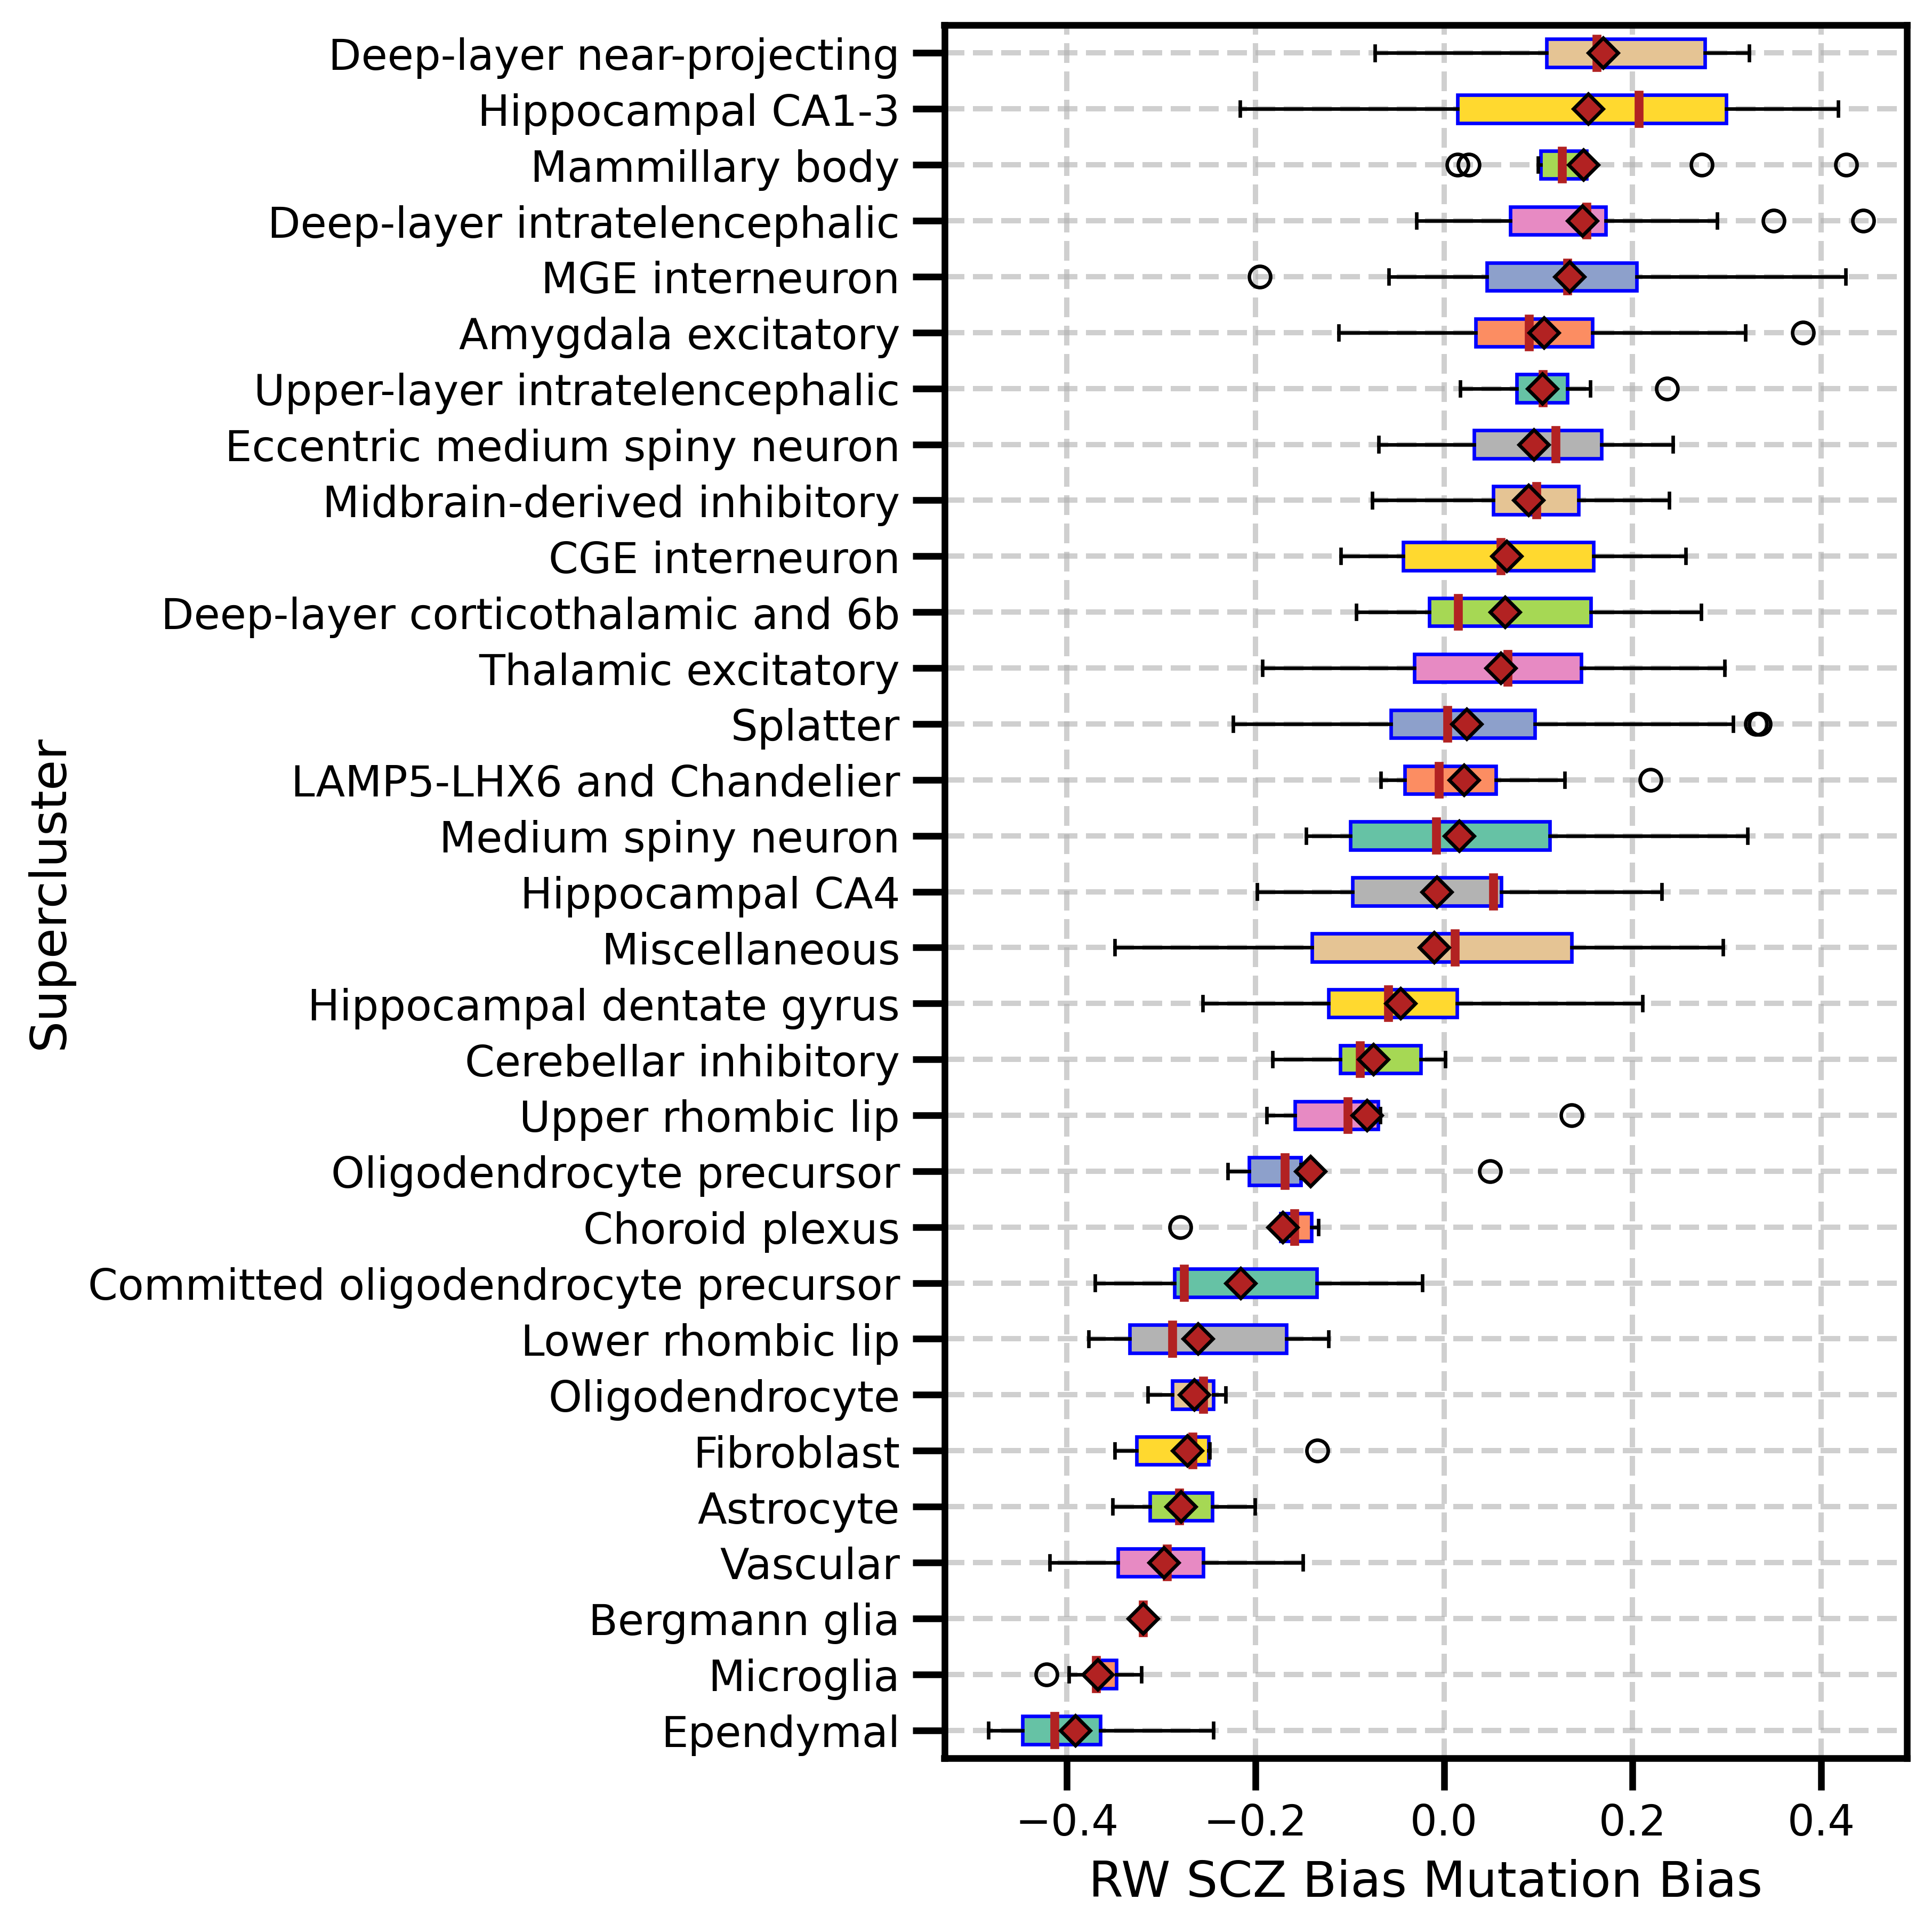

In [459]:
SuperClusterBias_BoxPlot(RW_SCZ_Bias, "RW SCZ Bias")

In [421]:
SCZ_GW = Gene_Weights_SCZ(GeneDF.head(61), HCT_Z2_MAT_HCT.index.values, usepLI=False)
SCZ_Bias = AvgCTZ_Weighted(HCT_Z2_MAT_HCT_clip, SCZ_GW, Method = 1, NonNeg=False)
SCZ_Bias = AnnotateCTDat(SCZ_Bias, Anno)

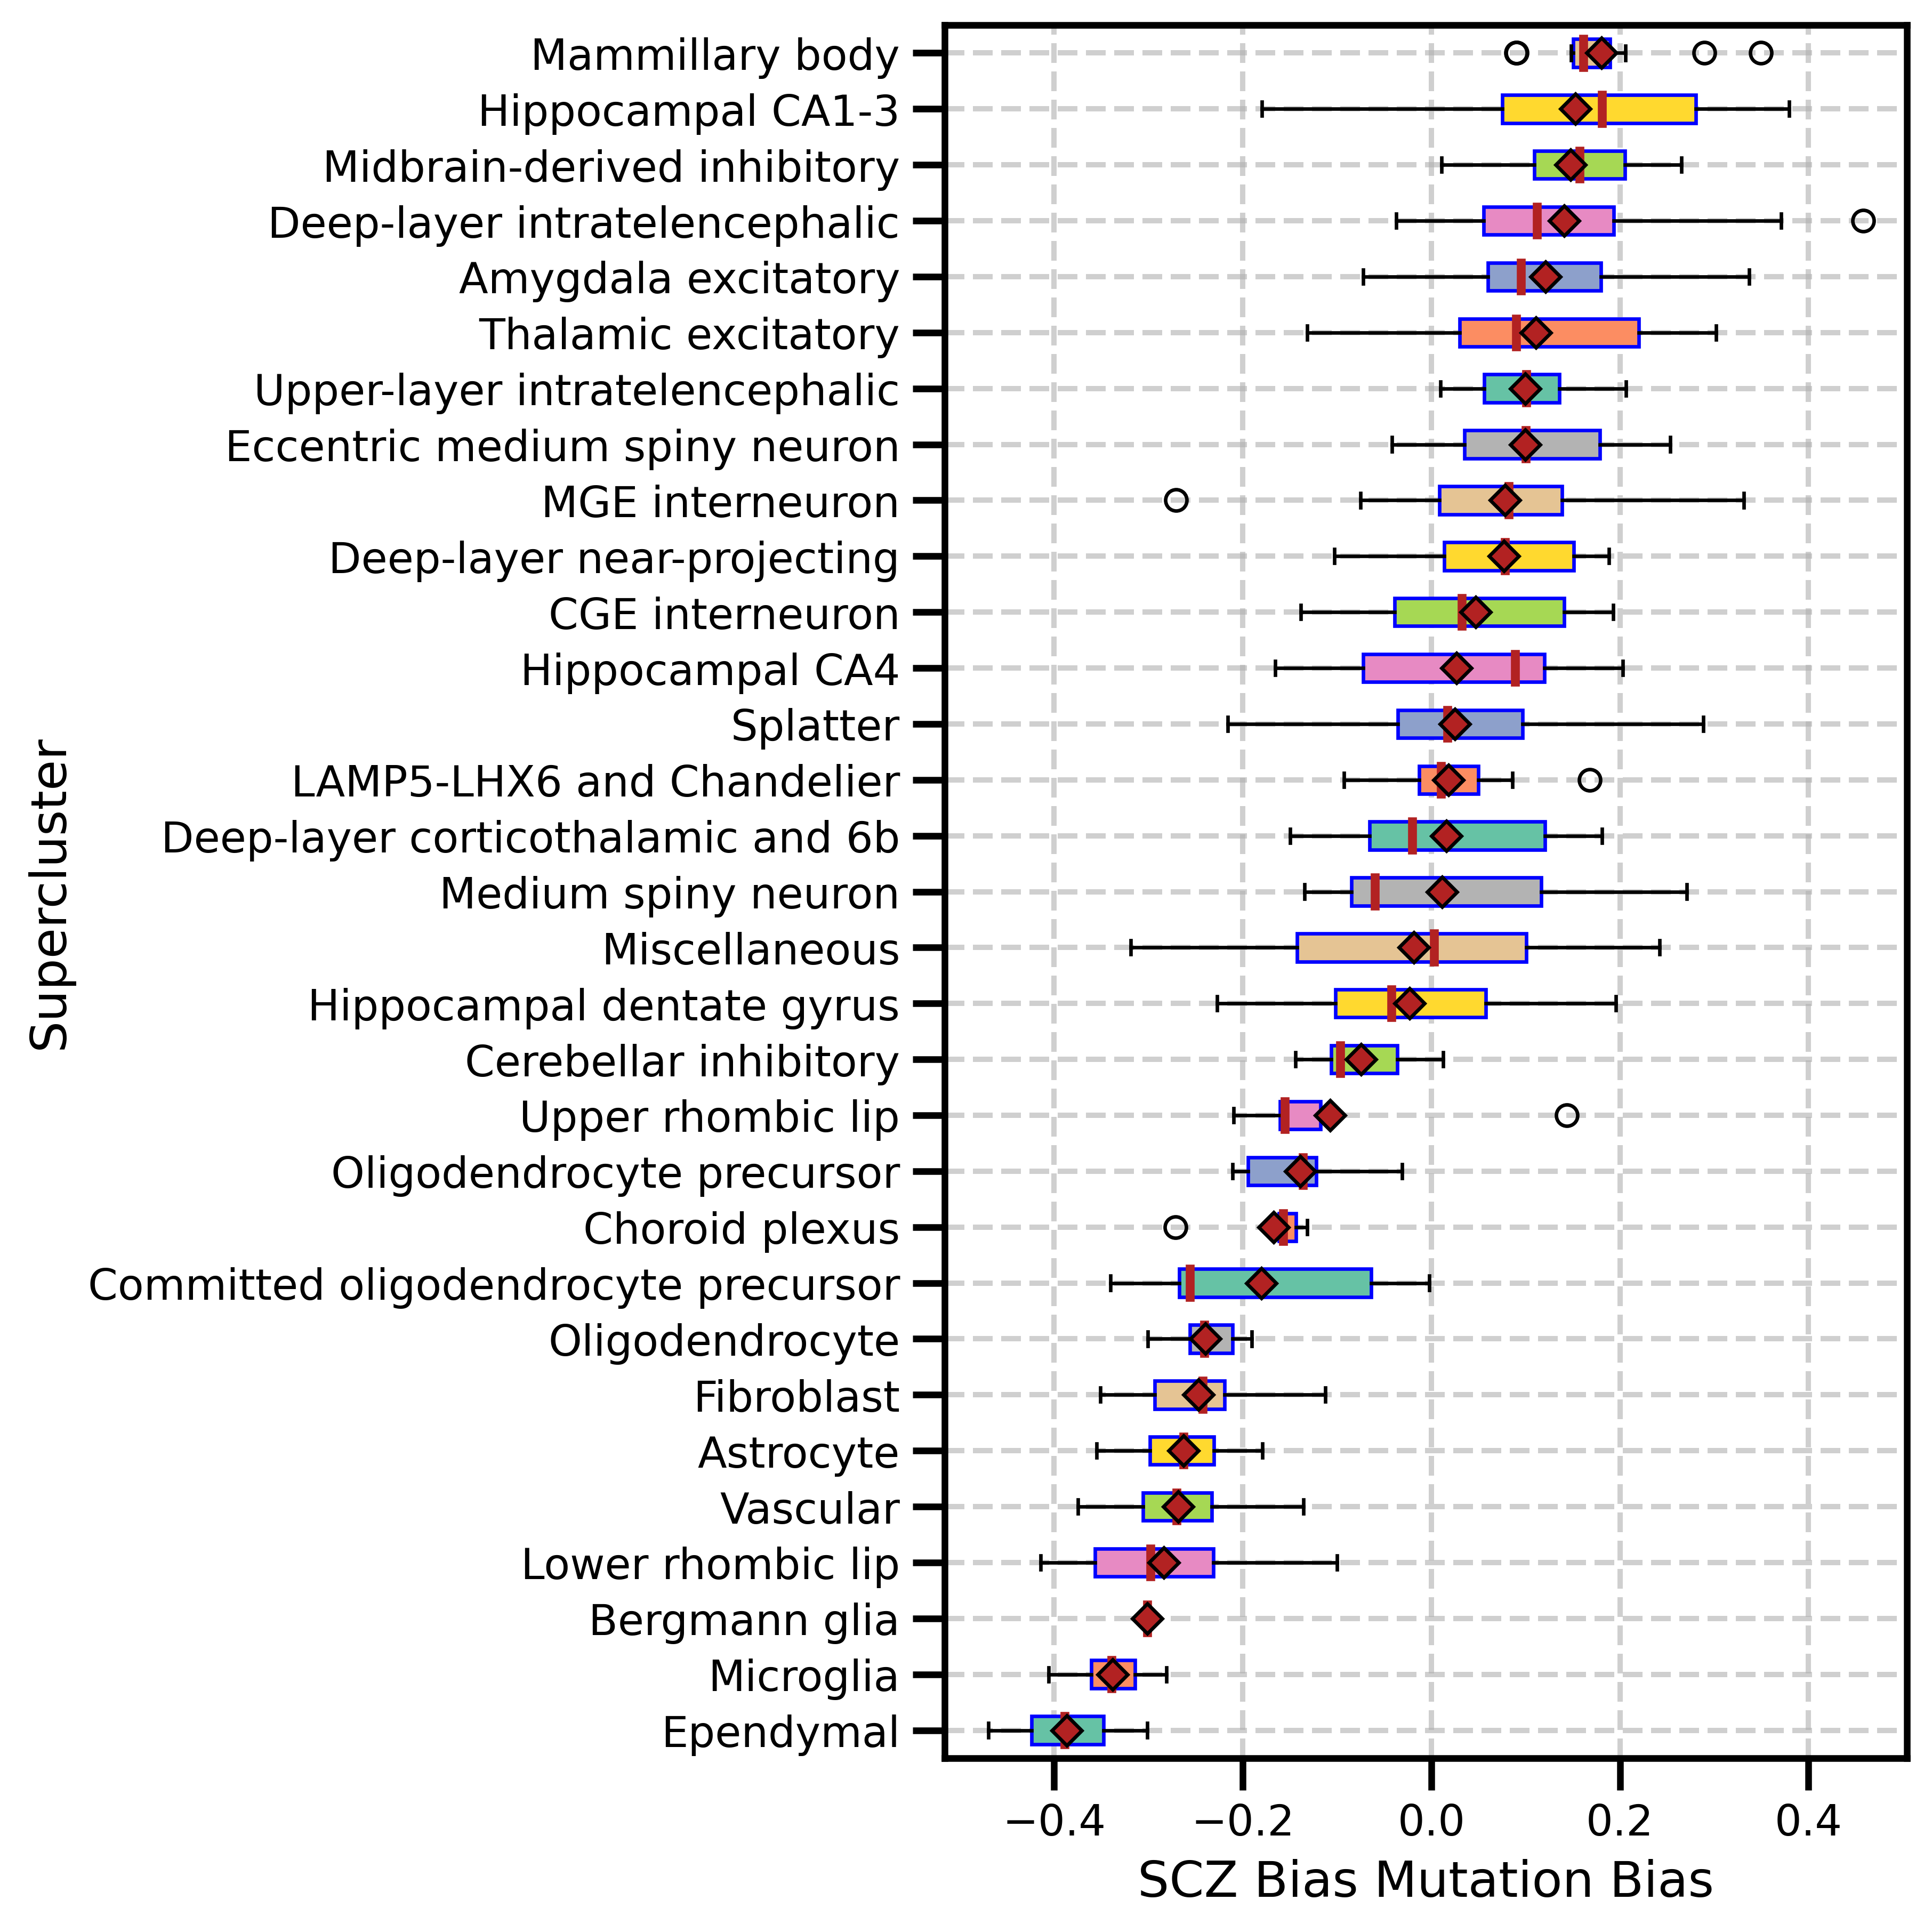

In [422]:
SuperClusterBias_BoxPlot(SCZ_Bias, "SCZ Bias")

#### All CT GT Test

In [111]:
def getBiasesBySTR(STR, dfs):
    biases = []
    for df in dfs:
        bias = df.loc[STR, "EFFECT"]
        biases.append(bias)
    biases = np.array(biases)
    return biases
def AddPvalue(DF, ContDF):
    for CT, row in DF.iterrows():
        mat_bias = getBiasesBySTR(CT, ContDF)
        Z, P = GetPermutationP(mat_bias, row["EFFECT"])
        DF.loc[CT, "EFFECT2"] = row["EFFECT"] - np.mean(mat_bias)
        DF.loc[CT, "Pvalue"] = P
        DF.loc[CT, "Z_Match"] = Z
        DF.loc[CT, "Z_Pvalue"] = scipy.stats.norm.sf(abs(Z))

    acc, qvalues = stats.multitest.fdrcorrection(DF["Pvalue"].values, alpha=0.1,
                                                       method="i")
    print(sum(acc))
    DF["qvalues"] = qvalues
    #ASD_Bias.to_csv("../dat/Unionize_bias/Spark_Meta_EWS.Z2.bias.subsib.FDR.csv")

    acc, qvalues = stats.multitest.fdrcorrection(DF["Z_Pvalue"].values, alpha=0.1,
                                                   method="i")
    print(sum(acc))
    DF["qvalues_ZP"] = qvalues
    return DF
def LoadCTRLBiasDFs(CTRL_DIR, n_samples=10000):
    CTRLBiasDFs = []
    for i in range(n_samples):
        try:
            DF = pd.read_csv("{}/cont.bias.{}.csv.gz".format(CTRL_DIR, i), index_col=0)
            CTRLBiasDFs.append(DF)
        except:
            continue
    print(len(CTRLBiasDFs))
    return CTRLBiasDFs
def PlotQQ(DFList, NameList):
    plt.figure(dpi=300, figsize=(10, 8))
    sns.set(style="whitegrid", context="talk")
    for DF, name in zip(DFList, NameList):
        DF_Pvals = DF["Pvalue"].values
        Qexp, Qobs = GetExpQ(DF_Pvals)
        plt.scatter(Qexp, Qobs , alpha=0.7, s=50, label=name)
    max_val = 4.5
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    plt.xlabel('Expected -log10(p-value)', fontsize=25, weight='bold')
    plt.ylabel('Observed -log10(p-value)', fontsize=25, weight='bold')
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    # Add grid
    plt.grid(True, linestyle='--', alpha=0.5)
    # Tight layout
    plt.tight_layout()
    plt.legend(fontsize=15, loc="lower right")
    #plt.title()
    plt.show()

In [112]:
RandGDFs_61G_GW = LoadCTRLBiasDFs("/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGenes/RandGene_60_z1clip3.3")

10000


In [390]:
RandGDFs_61G_Unif = LoadCTRLBiasDFs("/home/jw3514/Work/CellType_Psy/dat/CTRL/RandGenes/UniformWeights/RandGene_60_z1clip3.3/")

10000


##### CGE

In [407]:
ASD_HIQ_GW_Unif = dict(zip(HIQ_GW.keys(), [1]*len(HIQ_GW.keys())))
SCZ_GW_Unif =  dict(zip(SCZ_GW.keys(), [1]*len(SCZ_GW.keys())))

In [408]:
ASD_HIQ_Unif_Bias = AvgCTZ_Weighted(HCT_Z2_MAT_HCT_clip, ASD_HIQ_GW_Unif)
ASD_HIQ_Unif_Bias = AnnotateCTDat(ASD_HIQ_Unif_Bias, Anno)
SCZ_top61_Unif_Bias = AvgCTZ_Weighted(HCT_Z2_MAT_HCT_clip, SCZ_GW_Unif)
SCZ_top61_Unif_Bias = AnnotateCTDat(SCZ_top61_Unif_Bias, Anno)

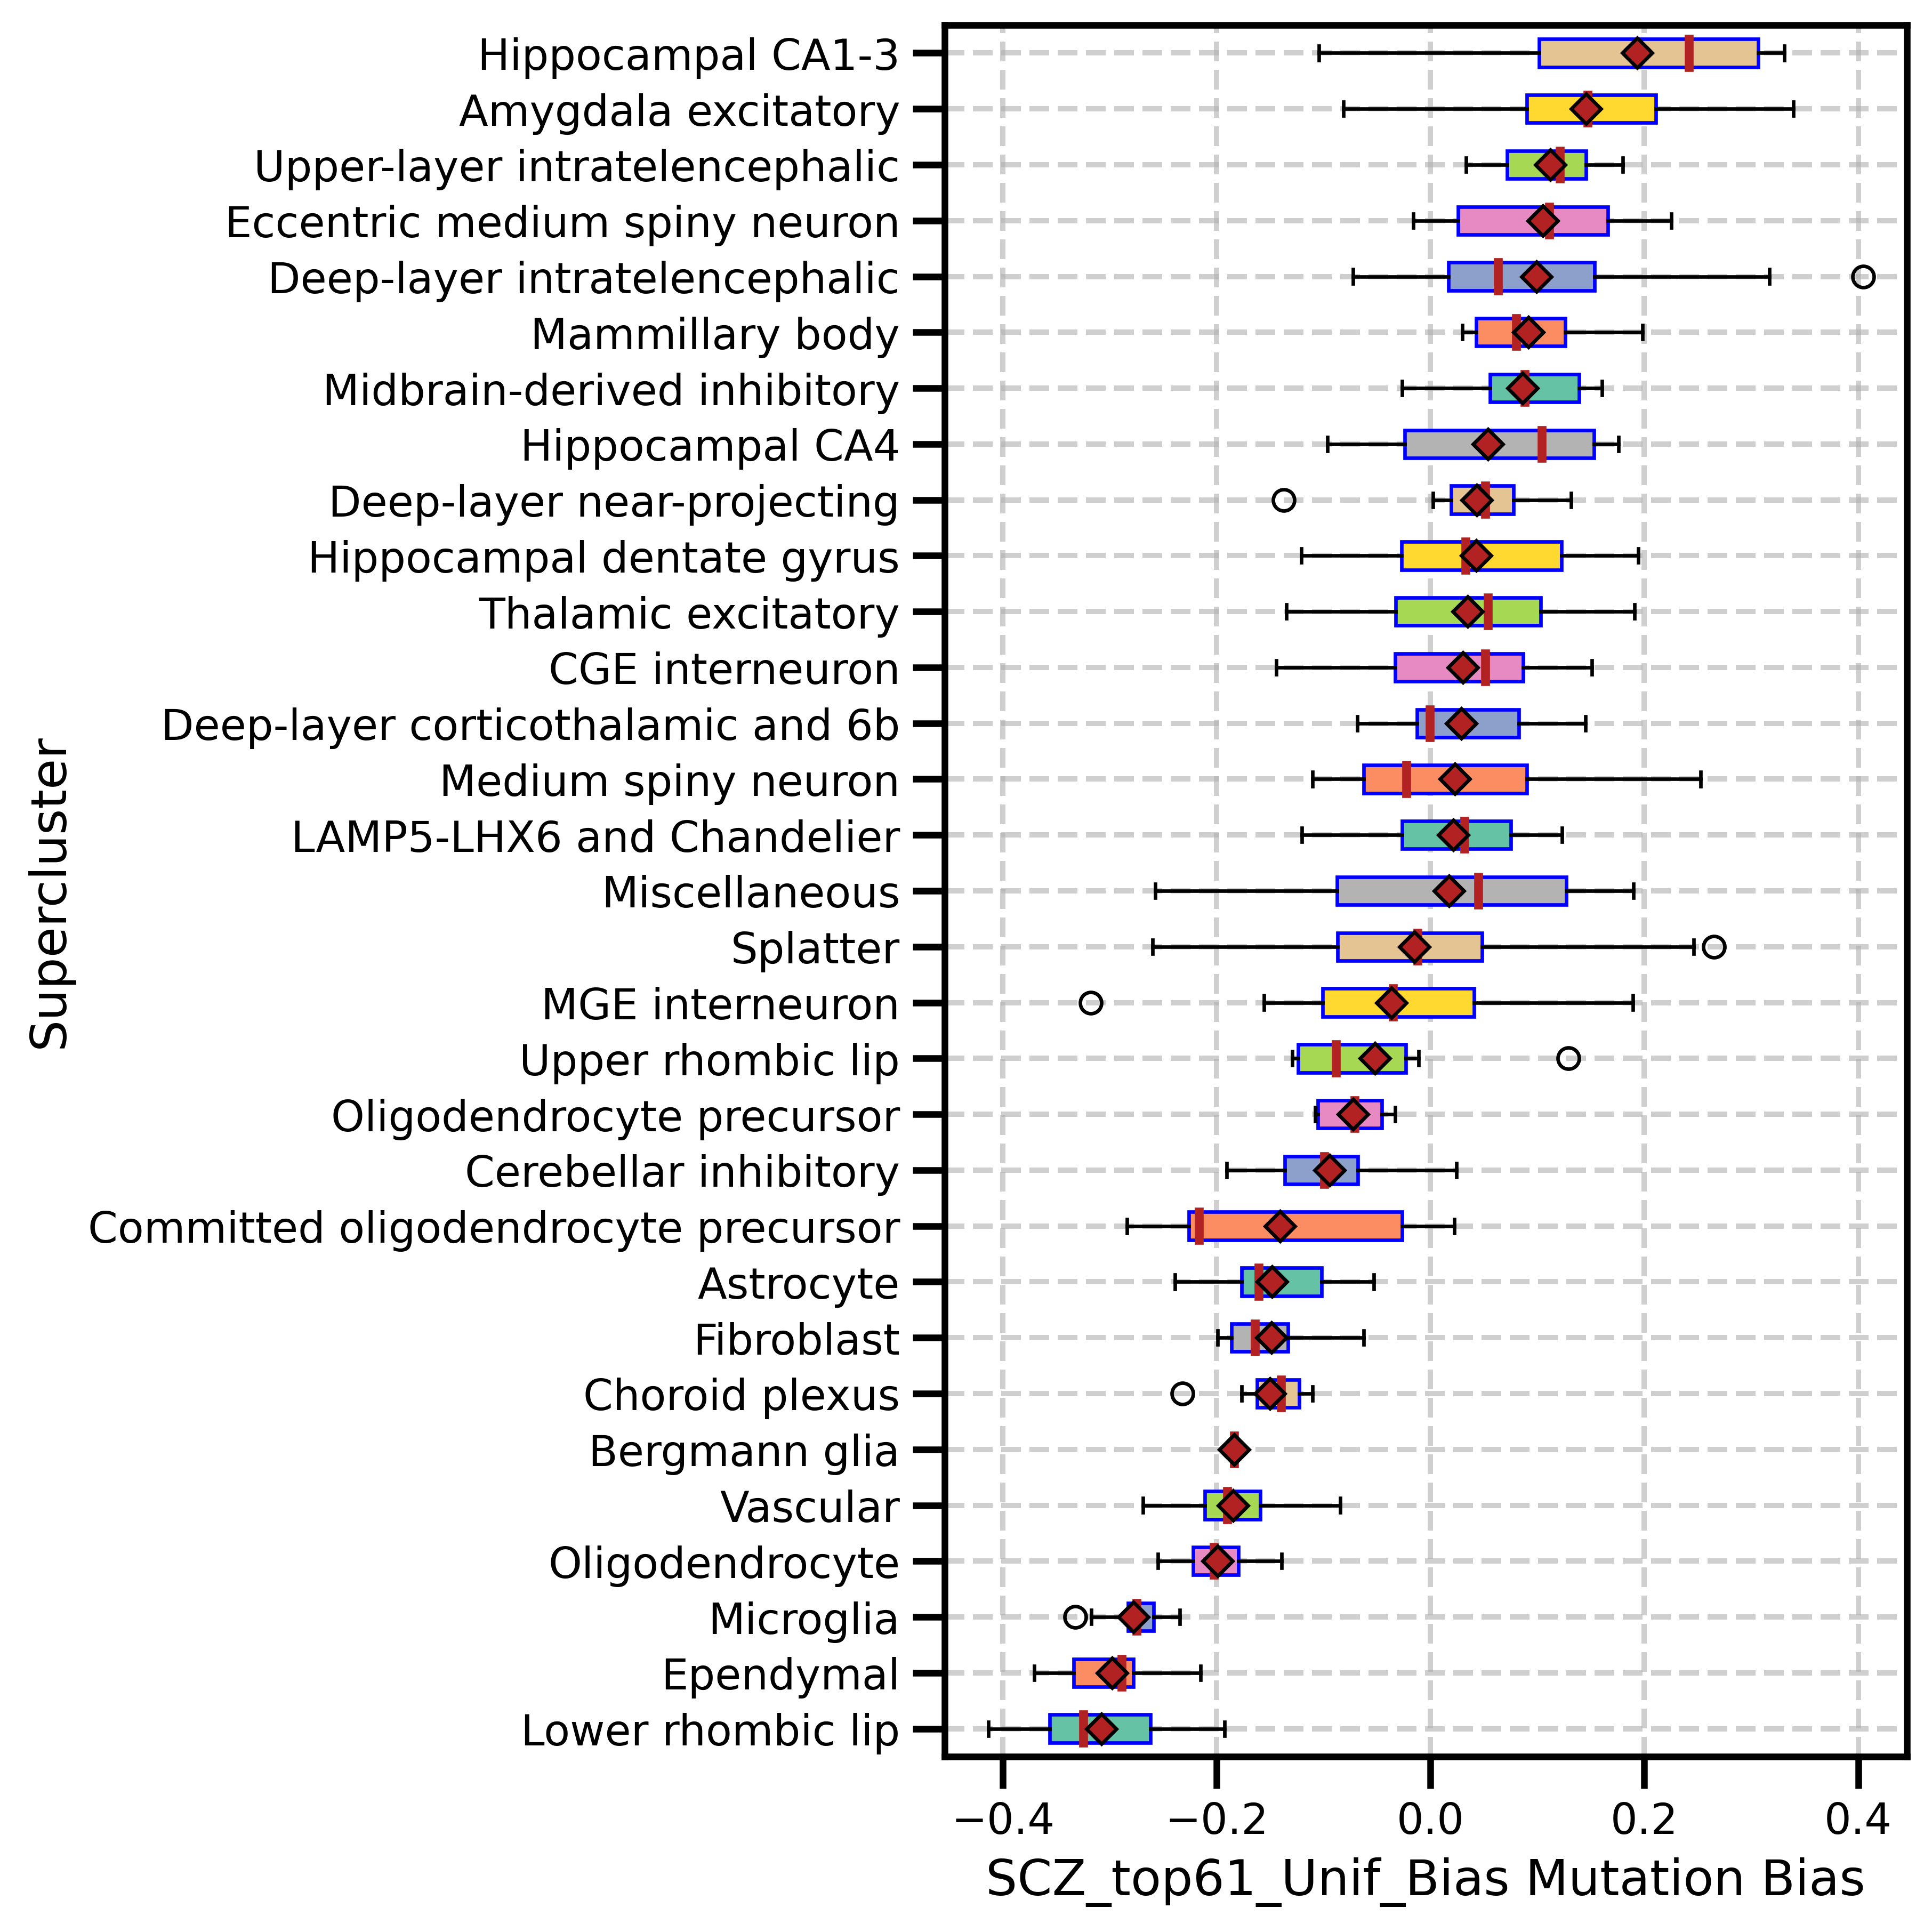

In [453]:
SuperClusterBias_BoxPlot(SCZ_top61_Unif_Bias, "SCZ_top61_Unif_Bias")

In [417]:
#SuperClusterBias_BoxPlot(SCZ_top61_Unif_Bias, "SCZ Unif Bias")

In [423]:
#CT = "CGE interneuron"
#CT = "MGE interneuron"
CT = "Medium spiny neuron"
CT_idx = Anno[Anno["Supercluster"]==CT].index.values
Required = len(CT_idx)
print(Required)

18


In [424]:
ASD_CT_Bias_Array = HIQ_ASD_Bias.loc[CT_idx, "EFFECT"]
SCZ_CT_Bias_Array = SCZ_Bias.loc[CT_idx, "EFFECT"]
Obs_Test = ASD_CT_Bias_Array.sum() - SCZ_CT_Bias_Array.sum()
print(Obs_Test)

0.7191225676390636


In [425]:
ASD_CT_Bias_Array = ASD_HIQ_Unif_Bias.loc[CT_idx, "EFFECT"]
SCZ_CT_Bias_Array = SCZ_top61_Unif_Bias.loc[CT_idx, "EFFECT"]
Obs_Test = ASD_CT_Bias_Array.sum() - SCZ_CT_Bias_Array.sum()
print(Obs_Test)

2.7826140805657977


In [393]:
Diff_with_weight = []
Diff_without_weight = []
for i in range(1000):
    ## with Weights:
    DF1 = RandGDFs_61G_GW[i]
    DF2 = RandGDFs_61G_GW[i+4999]
    DF1_CT_Bias_array = DF1.loc[CT_idx, "EFFECT"]
    DF2_CT_Bias_array = DF2.loc[CT_idx, "EFFECT"]
    _Diff_with_weight = DF1_CT_Bias_array.sum() - DF2_CT_Bias_array.sum()
    Diff_with_weight.append(_Diff_with_weight)
    
    ## with out Weights:
    DF1 = RandGDFs_61G_Unif[i]
    DF2 = RandGDFs_61G_Unif[i+4999]
    DF1_CT_Bias_array = DF1.loc[CT_idx, "EFFECT"]
    DF2_CT_Bias_array = DF2.loc[CT_idx, "EFFECT"]
    _Diff_without_weight = DF1_CT_Bias_array.sum() - DF2_CT_Bias_array.sum()
    Diff_without_weight.append(_Diff_without_weight)

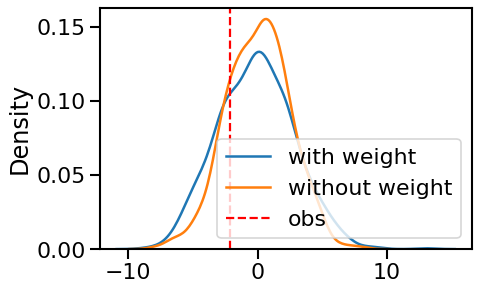

In [396]:
sns.kdeplot(Diff_with_weight, label="with weight")
sns.kdeplot(Diff_without_weight, label="without weight")
plt.axvline(x=Obs_Test, color='red', linestyle='--', linewidth=2, label='obs')
plt.legend()

5.8228307712283005


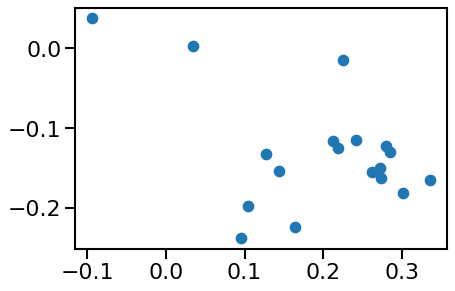

In [428]:
#idx = 14
#idx = 15
idx = 16
DF1 = RandGDFs_61G_Unif[idx]
DF2 = RandGDFs_61G_Unif[idx+4999]
DF1_CT_Bias_array = DF1.loc[CT_idx, "EFFECT"]
DF2_CT_Bias_array = DF2.loc[CT_idx, "EFFECT"]
_Diff_with_weight = DF1_CT_Bias_array.sum() - DF2_CT_Bias_array.sum()
print(_Diff_with_weight)
plt.scatter(DF1_CT_Bias_array, DF2_CT_Bias_array)
#plt.

##### end

In [219]:
Neurons

['Amygdala excitatory',
 'CGE interneuron',
 'Cerebellar inhibitory',
 'Deep-layer corticothalamic and 6b',
 'Deep-layer intratelencephalic',
 'Deep-layer near-projecting',
 'Eccentric medium spiny neuron',
 'Hippocampal CA1-3',
 'Hippocampal CA4',
 'Hippocampal dentate gyrus',
 'LAMP5-LHX6 and Chandelier',
 'Lower rhombic lip',
 'MGE interneuron',
 'Mammillary body',
 'Medium spiny neuron',
 'Midbrain-derived inhibitory',
 'Miscellaneous',
 'Splatter',
 'Thalamic excitatory',
 'Upper rhombic lip',
 'Upper-layer intratelencephalic']

In [240]:
#CT = "CGE interneuron"
#CT = "MGE interneuron"
CT = "Medium spiny neuron"
#CT = "Amygdala excitatory"
#CT = "Splatter"
#CT = "Cerebellar inhibitory"
#CT = "Mammillary body"
CT_idx = Anno[Anno["Supercluster"]==CT].index.values
Required = len(CT_idx)
print(Required)

18


In [241]:
ASD_CT_Bias_Array = HIQ_ASD_Bias.loc[CT_idx, "EFFECT"]
SCZ_CT_Bias_Array = SCZ_Bias.loc[CT_idx, "EFFECT"]

In [242]:
stats_scz = []
stats_asd = []
Test_DiffArray = SCZ_CT_Bias_Array - ASD_CT_Bias_Array
Total_tests = 10000
for i in range(Total_tests):
    DF = RandGDFs_61G_GW[i]
    DF_CT_Bias_array = DF.loc[CT_idx, "EFFECT"]
    stats_asd.append((DF_CT_Bias_array >= ASD_CT_Bias_Array).sum())
    stats_scz.append((DF_CT_Bias_array >= SCZ_CT_Bias_Array).sum())

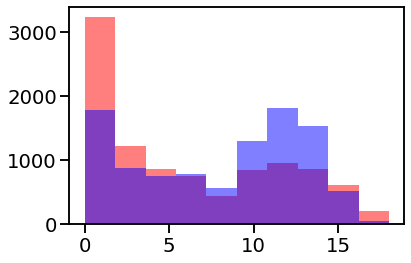

0.0205
0.0059


In [243]:
plt.hist(stats_asd, color="red", alpha=0.5, label="ASD")
plt.hist(stats_scz, color="blue", alpha=0.5, label="SCZ")
plt.show()
#plt.legend()
Pass_asd = (np.array(stats_asd) >= Required*0.9).sum()
Pass_scz = (np.array(stats_scz) >= Required*0.9).sum()
print(Pass_asd/Total_tests)
print(Pass_scz/Total_tests)

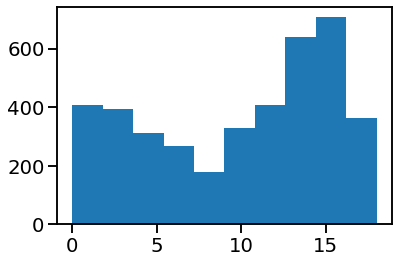

0.0905


In [247]:
Diffstats = []
Test_DiffArray = SCZ_CT_Bias_Array - ASD_CT_Bias_Array
#Test_DiffArray = ASD_CT_Bias_Array - SCZ_CT_Bias_Array
for i in range(4000):
    DF1 = RandGDFs_61G_GW[i]
    DF2 = RandGDFs_61G_GW[i+4999]
    DF1_CT_Bias_array = DF1.loc[CT_idx, "EFFECT"]
    DF2_CT_Bias_array = DF2.loc[CT_idx, "EFFECT"]
    Diff = DF1_CT_Bias_array - DF2_CT_Bias_array
    N_diff = (Diff >= Test_DiffArray).sum()
    Diffstats.append(N_diff)
plt.hist(Diffstats)
plt.show()
Pass = (np.array(Diffstats) >= Required-1).sum()
print(Pass/4000)

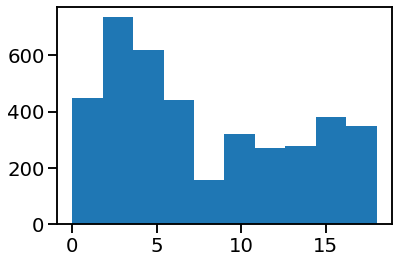

0.087


In [248]:
Diffstats = []
#Test_DiffArray = SCZ_CT_Bias_Array - ASD_CT_Bias_Array
Test_DiffArray = ASD_CT_Bias_Array - SCZ_CT_Bias_Array
for i in range(4000):
    DF1 = RandGDFs_61G_GW[i]
    DF2 = RandGDFs_61G_GW[i+4999]
    DF1_CT_Bias_array = DF1.loc[CT_idx, "EFFECT"]
    DF2_CT_Bias_array = DF2.loc[CT_idx, "EFFECT"]
    Diff = DF1_CT_Bias_array - DF2_CT_Bias_array
    N_diff = (Diff >= Test_DiffArray).sum()
    Diffstats.append(N_diff)
plt.hist(Diffstats)
plt.show()
Pass = (np.array(Diffstats) >= Required-1).sum()
print(Pass/4000)

In [249]:
Test_DiffArray

206    0.190330
207    0.047997
208    0.104046
209    0.109737
210    0.066135
211    0.060063
212    0.026974
213    0.077675
214    0.087512
215    0.094171
216   -0.001390
217   -0.102197
218    0.073716
219    0.108608
220   -0.020029
221   -0.242920
427   -0.184210
430    0.024377
Name: EFFECT, dtype: float64

In [116]:
HIQ_ASD_Bias = pd.read_csv("../dat/Bias/HCT.ASD.HIQ61.Z2.HCT.csv", index_col=0)
SCZ_Bias = pd.read_csv("../dat/Bias/HCT.SCZ61.Z2.HCT.csv", index_col=0)

In [175]:
CT = "CGE interneuron"
CT = "MGE interneuron"
CT = "Medium Spiney Neurons"
CT_idx = Anno[Anno["Supercluster"]==CT].index.values
Required = len(CT_idx)

In [176]:
ASD_CT_Bias_Array = HIQ_ASD_Bias.loc[CT_idx, "EFFECT"]
SCZ_CT_Bias_Array = SCZ_Bias.loc[CT_idx, "EFFECT"]
Test_DiffArray = SCZ_CT_Bias_Array - ASD_CT_Bias_Array

In [177]:
stats = []
for i in range(4000):
    DF1 = RandGDFs_61G_GW[i]
    DF2 = RandGDFs_61G_GW[i+4999]
    DF1_CT_Bias_array = DF1.loc[CT_idx, "EFFECT"]
    DF2_CT_Bias_array = DF2.loc[CT_idx, "EFFECT"]
    Diff = DF1_CT_Bias_array - DF2_CT_Bias_array
    N_diff = (Diff >= Test_DiffArray).sum()
    stats.append(N_diff)

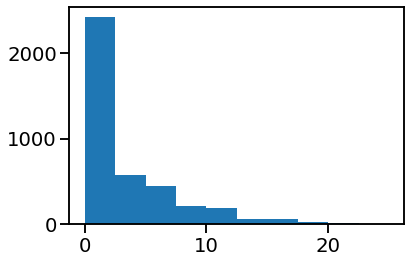

0.0


In [178]:
plt.hist(stats)
plt.show()
Pass = (np.array(stats) >= Required).sum()
print(Pass/4000)

In [250]:
#ASD_GW = Fil2Dict("../dat/GeneWeights/")
HIQ_GW = Fil2Dict("../../ASD_Circuits/dat/Unionize_bias/ASD.HIQ.gw.csv")
LIQ_GW = Fil2Dict("../../ASD_Circuits/dat/Unionize_bias/ASD.LIQ.gw.csv")
SCZ_GW = Fil2Dict("../dat3/SCZ_MutCount_61.gw")

In [251]:
def GeneRand(GW1, GW2):
    GW1_keys = list(GW1.keys())
    GW1_Weights = list(GW1.values())
    
    GW2_keys = list(GW2.keys())
    GW2_Weights = list(GW2.values())
    
    AB = list(GW1_keys) + list(GW2_keys)
    
    random.shuffle(AB)
    Ap = AB[:len(GW1_keys)]
    Bp = AB[len(GW2_keys):]
    
    GW1_Rand = dict(zip(Ap, GW1_Weights))
    GW2_Rand = dict(zip(Bp, GW2_Weights))
    
    return GW1_Rand, GW2_Rand

In [252]:
GenePermDF1, GenePermDF2 = [], []
for i in range(1000):
    GW1, GW2 = GeneRand(HIQ_GW, SCZ_GW)
    DF1 = AvgCTZ_Weighted(HCT_Z2_MAT_HCT_clip, GW1, Method = 1)
    DF2 = AvgCTZ_Weighted(HCT_Z2_MAT_HCT_clip, GW2, Method = 1)
    GenePermDF1.append(DF1)
    GenePermDF2.append(DF2)

KeyboardInterrupt: 

In [253]:
print(len(GenePermDF1), len(GenePermDF2))

847 847


In [257]:
N_test = len(GenePermDF1)

In [362]:
#CT = "CGE interneuron"
#CT = "MGE interneuron"
CT = "Medium spiny neuron"
CT_idx = Anno[Anno["Supercluster"]==CT].index.values
Required = len(CT_idx)
ASD_CT_Bias_Array = HIQ_ASD_Bias.loc[CT_idx, "EFFECT"]
SCZ_CT_Bias_Array = SCZ_Bias.loc[CT_idx, "EFFECT"]
Test_DiffArray = (SCZ_CT_Bias_Array - ASD_CT_Bias_Array)
stats2_obs = Test_DiffArray.sum()
print(Required, stats2_obs)

18 -0.5205948561854441


In [363]:
stats = []
stats2 = []
for i in range(N_test):
    DF1 = GenePermDF1[i]
    DF2 = GenePermDF2[i]
    DF1.index = [int(x) for x in DF1.index.values]
    DF2.index = [int(x) for x in DF2.index.values]
    DF1_CT_Bias_array = DF1.loc[CT_idx, "EFFECT"]
    DF2_CT_Bias_array = DF2.loc[CT_idx, "EFFECT"]
    Diff = DF1_CT_Bias_array - DF2_CT_Bias_array
    N_diff = (Diff >= Test_DiffArray).sum()
    stats2.append(Diff.sum())
    stats.append(N_diff)

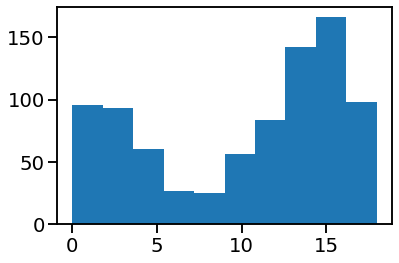

0.030696576151121605


In [364]:
plt.hist(stats)
plt.show()
Pass = (np.array(stats) >= Required).sum()
print(Pass/N_test)

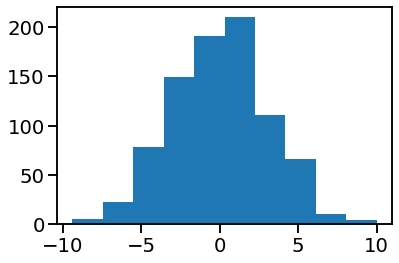

0.5855962219598583


In [365]:
plt.hist(stats2)
plt.show()
Pass = (np.array(stats2) >= stats2_obs).sum()
print(Pass/N_test)

#### Mutation Redistribution

In [562]:
Permut_ASD_DF_MutPerm_CT = []
Permut_SCZ_DF_MutPerm_CT = []
#DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/BiasDiff_RW/HIQASD_SCZ/"
#DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/BiasDiff_RW/HIQASD_SCZ_v2/"
#DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/BiasDiff_RW/HIQASD_SCZ_v3/"
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/BiasDiff_RW/HIQASD_SCZ_v4/"
N=10000
for i in range(N):
    try:
        DF1 = pd.read_csv("{}/{}.ASD.perm.bias.csv".format(DIR, i), index_col=0)
        DF2 = pd.read_csv("{}/{}.SCZ.perm.bias.csv".format(DIR, i), index_col=0)
        Permut_ASD_DF_MutPerm_CT.append(DF1)
        Permut_SCZ_DF_MutPerm_CT.append(DF2)
    except:
        continue
N_Perm = len(Permut_ASD_DF_MutPerm_CT)
print(N_Perm)

10000


In [563]:
ASD_CT_Bias = pd.read_csv("../dat/Bias/HCT.ASD61.HIQ.Z2.HCT.csv", index_col=0)
SCZ_CT_Bias = pd.read_csv("../dat/Bias/HCT.SCZ61.Z2.HCT.csv", index_col=0)

In [577]:
def TestDiff_Perm(CT, ASD_CT_Bias, SCZ_CT_Bias, Permut_ASD_DF_MutPerm_CT, Permut_SCZ_DF_MutPerm_CT):
    CT_ASD_Bias = ASD_CT_Bias[ASD_CT_Bias["Supercluster"]==CT]
    CT_SCZ_Bias = SCZ_CT_Bias[SCZ_CT_Bias["Supercluster"]==CT]
    ct_ASD_Bias = CT_ASD_Bias["EFFECT"].sum()
    ct_SCZ_Bias = CT_SCZ_Bias["EFFECT"].sum()
    BiasDiff = ct_ASD_Bias - ct_SCZ_Bias
    #print(ct_ASD_Bias, ct_SCZ_Bias, BiasDiff)
    PermutedASD = []
    PermutedSCZ = []
    PermutedDiff = []
    for i in range(N_Perm):
        DF1 = Permut_ASD_DF_MutPerm_CT[i]
        DF2 = Permut_SCZ_DF_MutPerm_CT[i]
        DF1_Bias = DF1[DF1["Supercluster"]==CT]
        DF2_Bias = DF2[DF2["Supercluster"]==CT]
        _ct_ASD_Bias = DF1_Bias["EFFECT"].sum()
        _ct_SCZ_Bias = DF2_Bias["EFFECT"].sum()
        _BiasDiff = _ct_ASD_Bias - _ct_SCZ_Bias
        PermutedASD.append(_ct_ASD_Bias)
        PermutedSCZ.append(_ct_SCZ_Bias)
        PermutedDiff.append(_BiasDiff)
        
    P,Z = xxGetPermutationP(Obs = BiasDiff, Null=PermutedDiff)
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(24,6), dpi=120)

    PlotPermutationP(Obs = ct_ASD_Bias, ax=ax1, Null=PermutedASD)
    ax1.set_xlabel("ASD")

    PlotPermutationP(Obs = ct_SCZ_Bias, ax=ax2, Null=PermutedSCZ)
    ax2.set_xlabel("SCZ")

    PlotPermutationP(Obs = BiasDiff, ax=ax3, Null=PermutedDiff)
    ax3.set_xlabel("Bias Diff")
    #ax3.set_title(CT + " [Mut Perm]", fontsize=15)
    plt.tight_layout()
    plt.suptitle(CT, fontsize=30, y=1.02)
    plt.show()

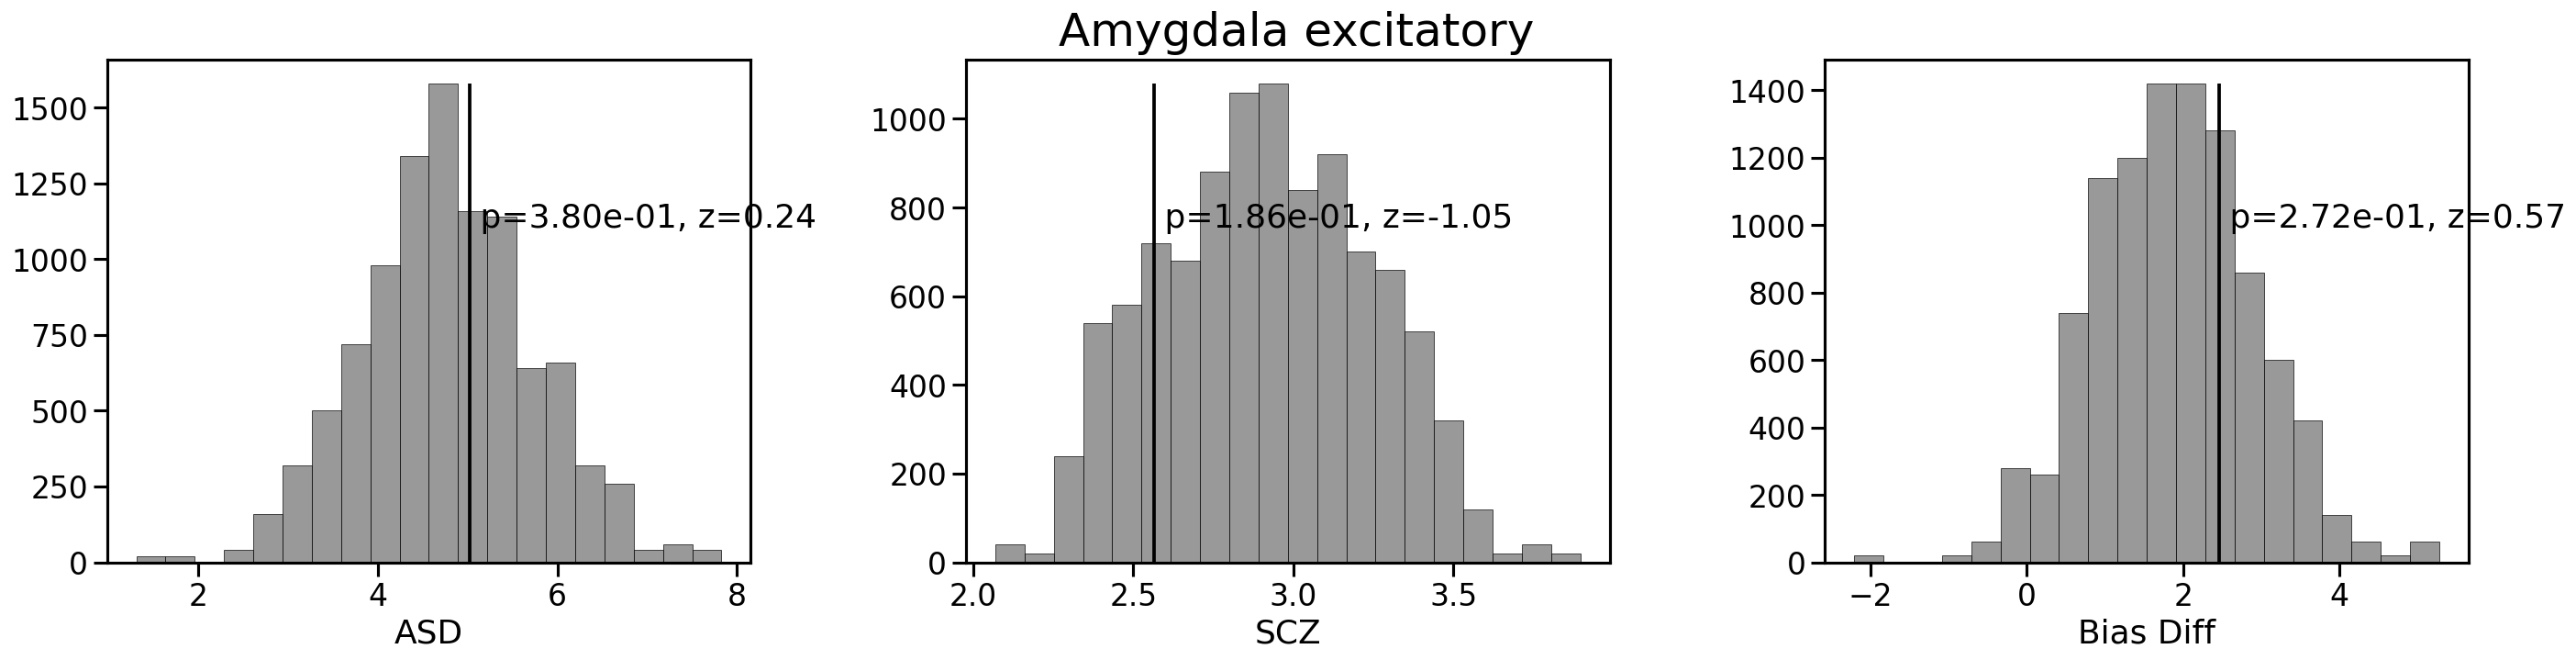

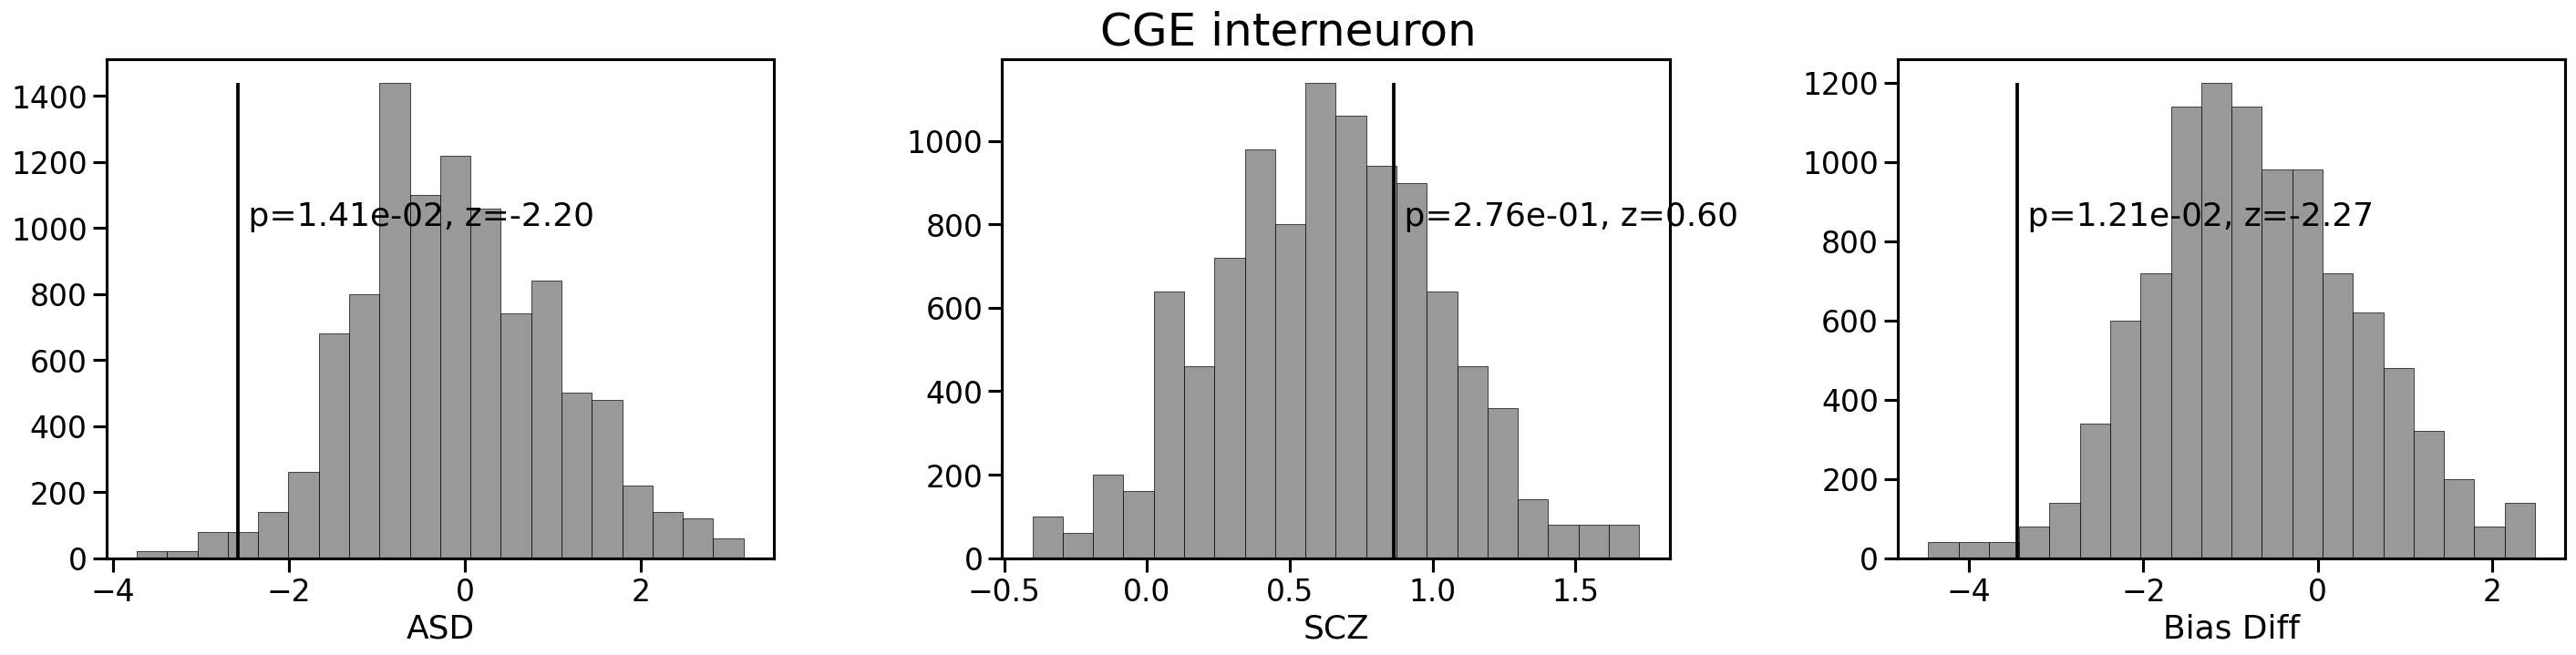

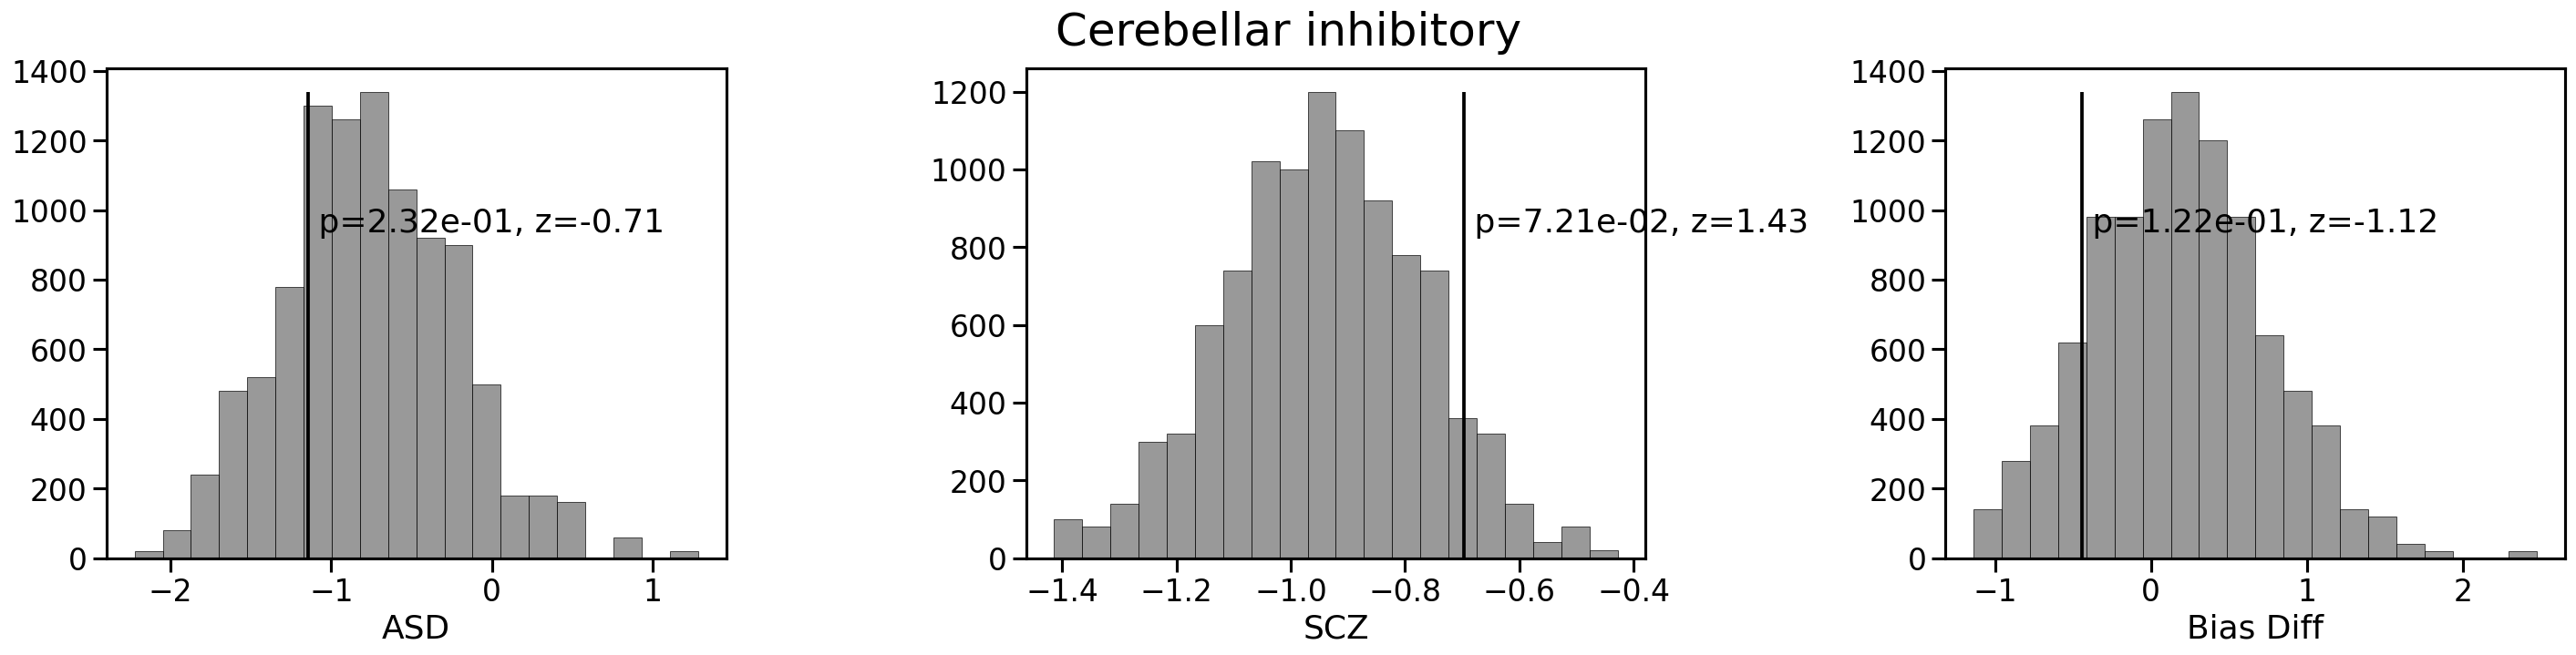

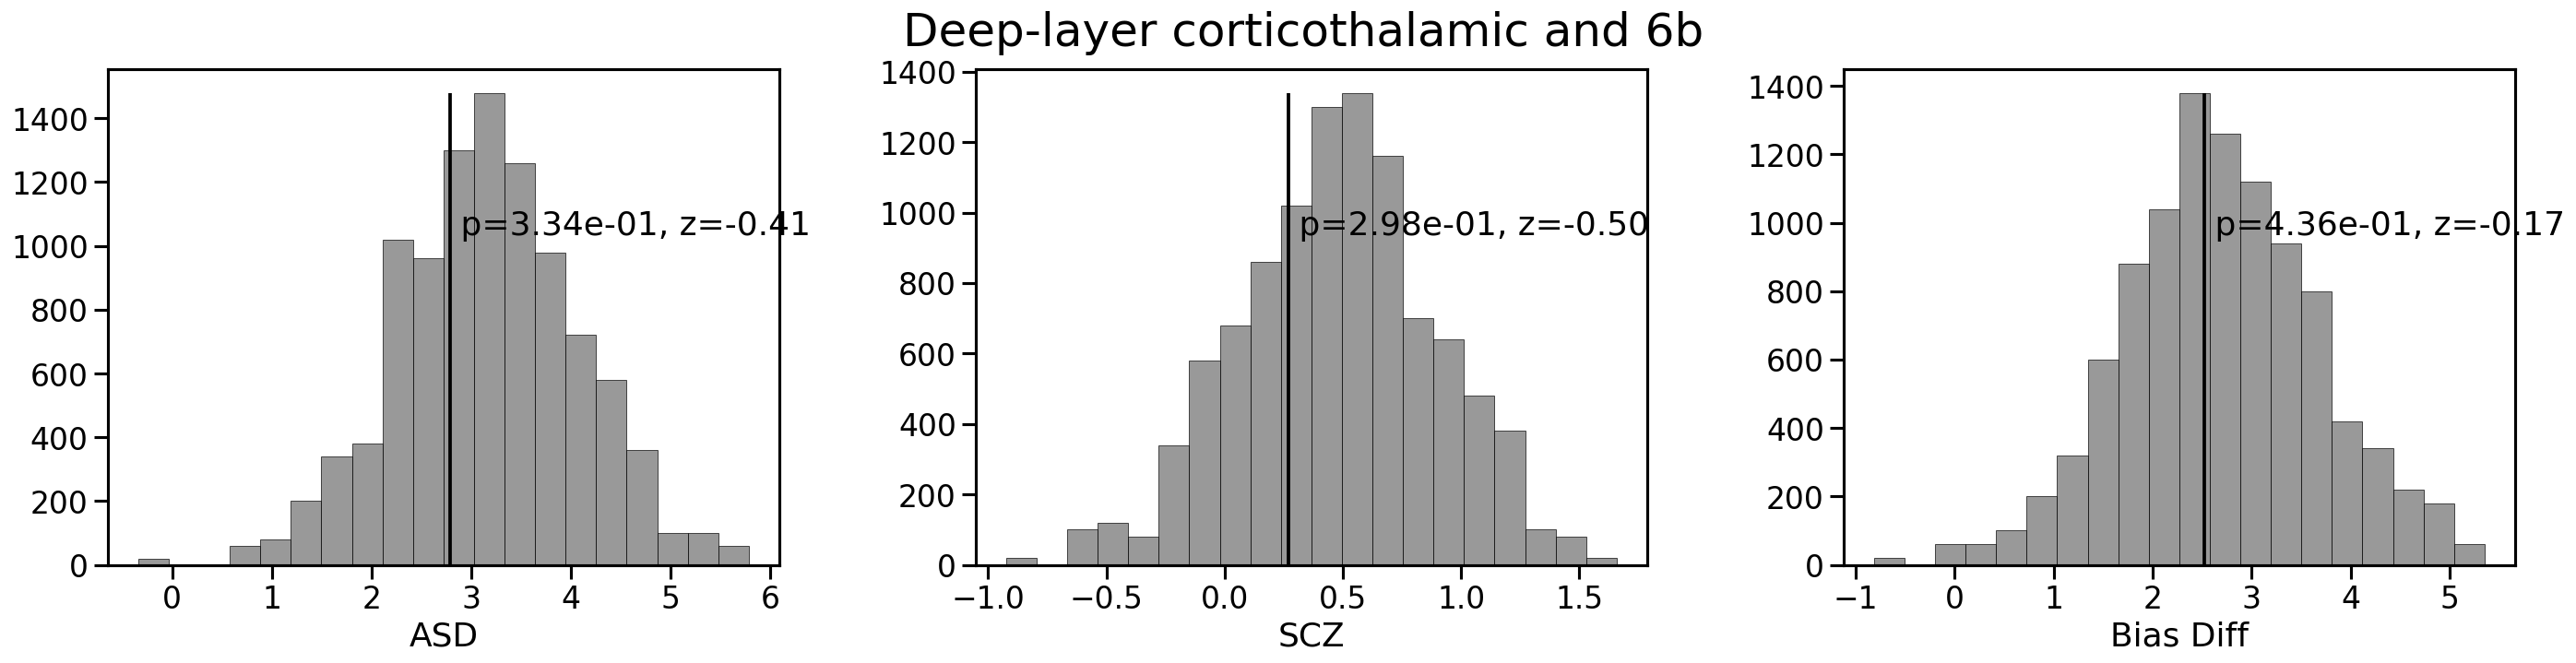

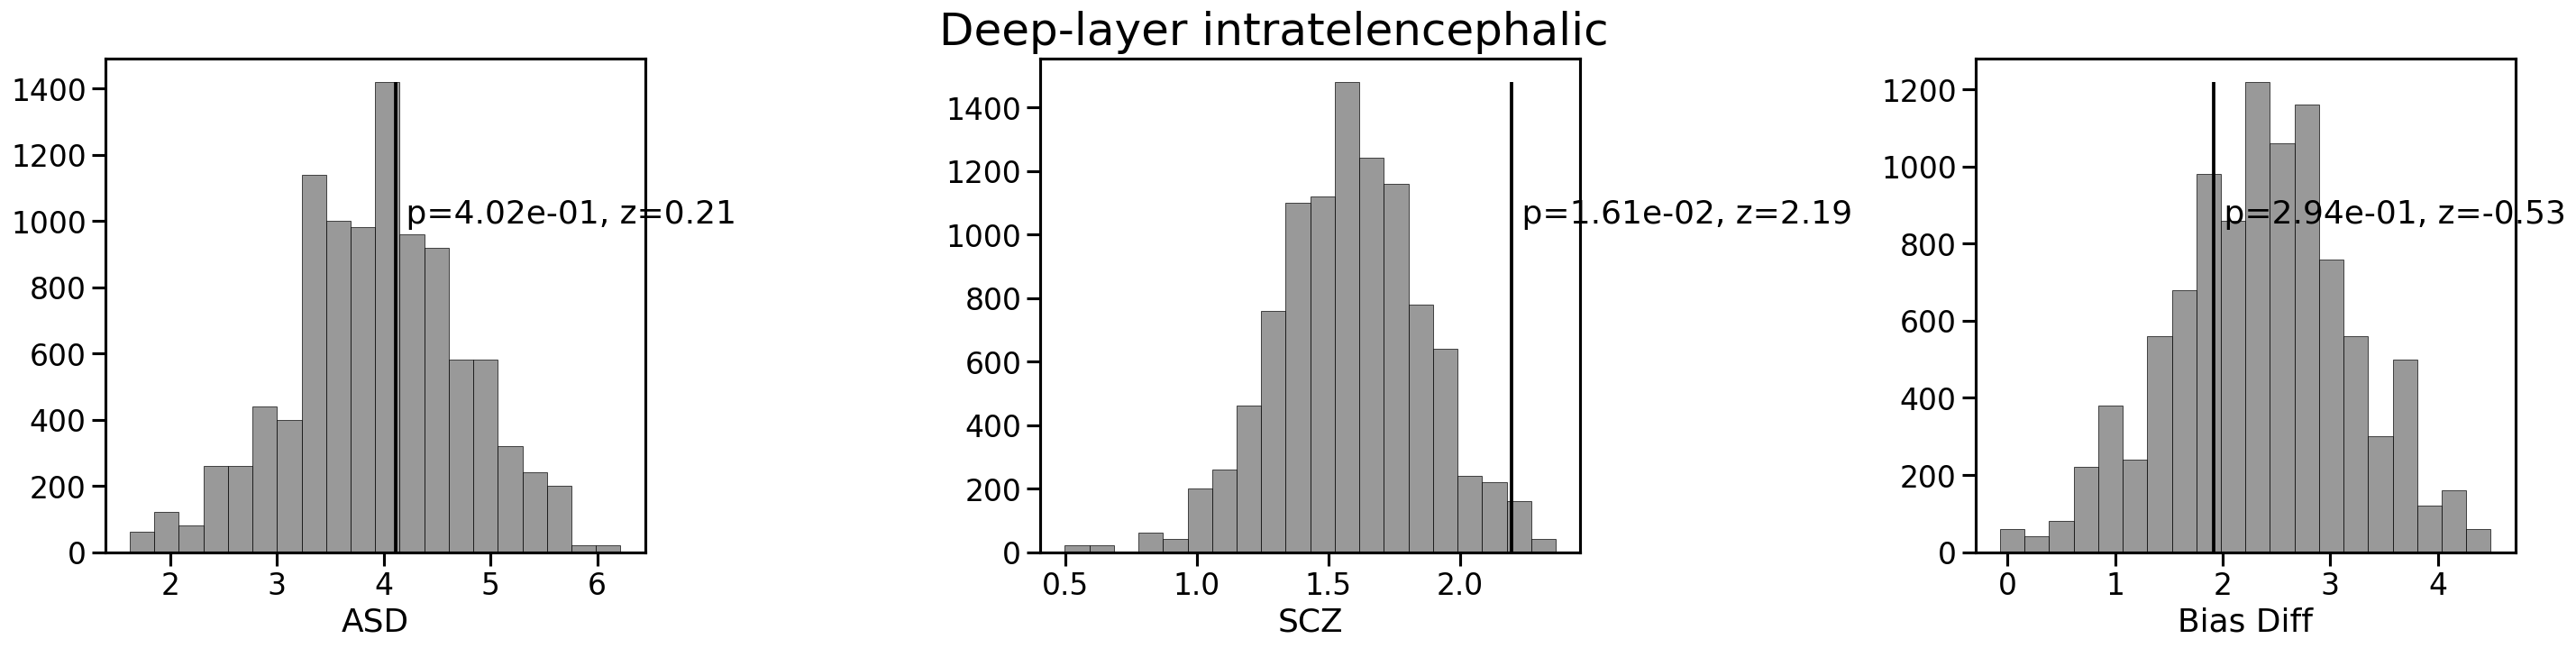

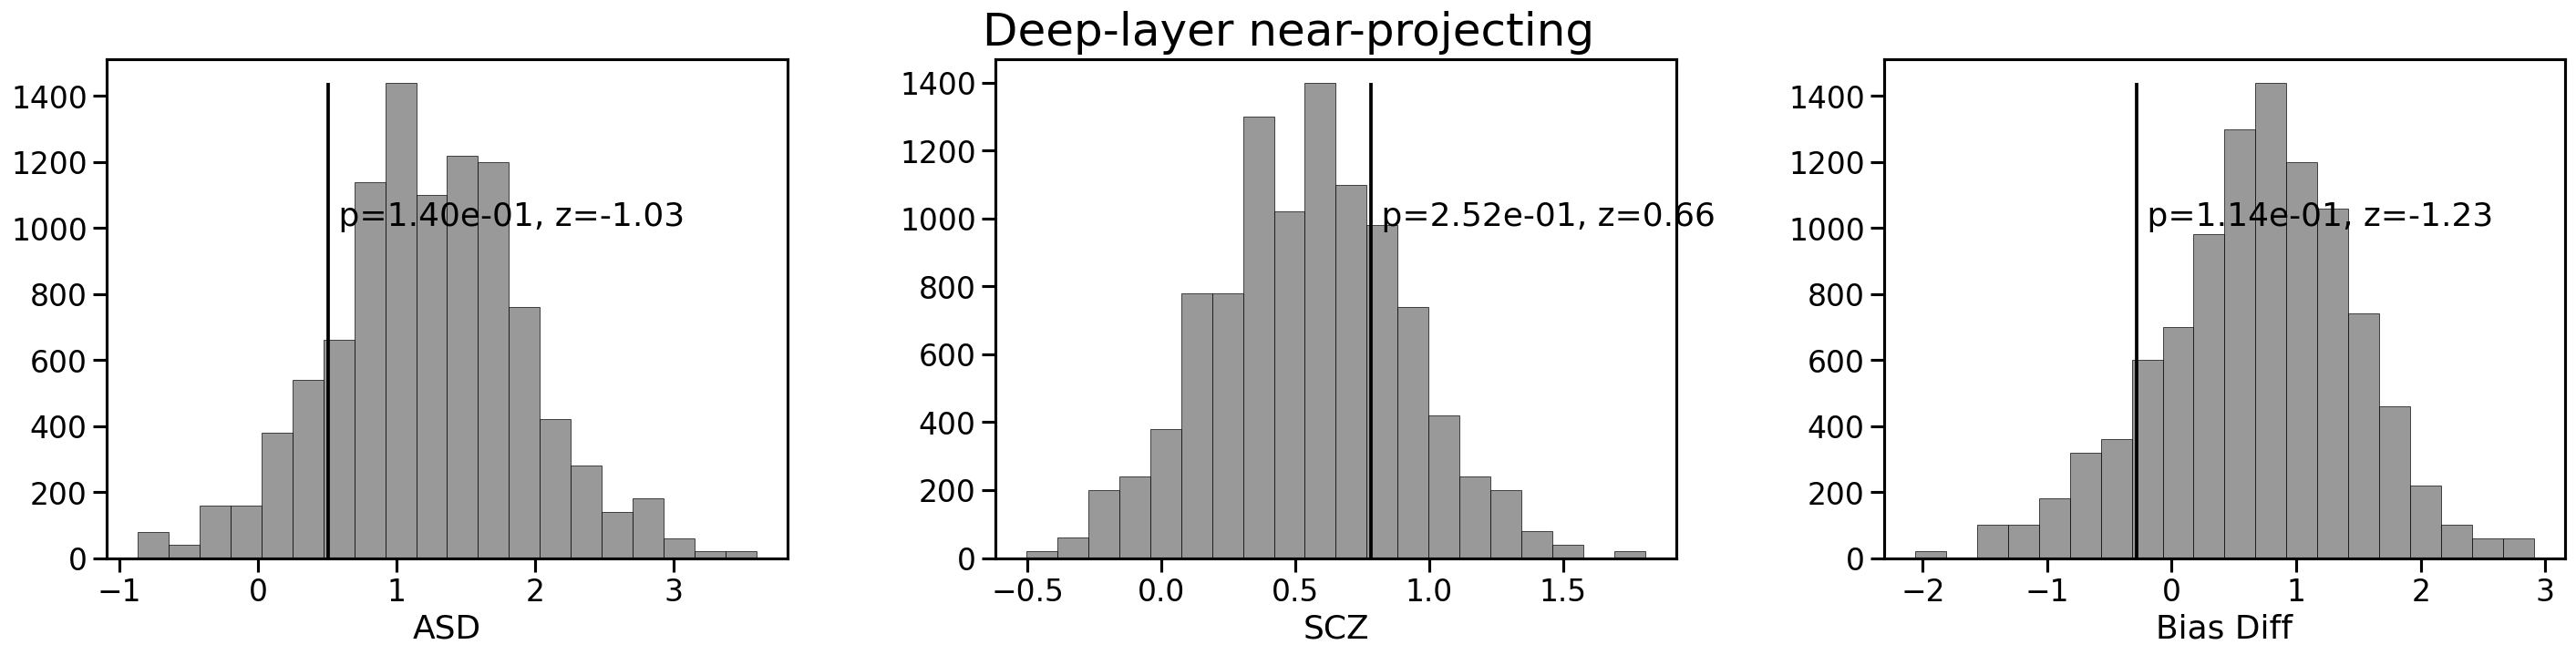

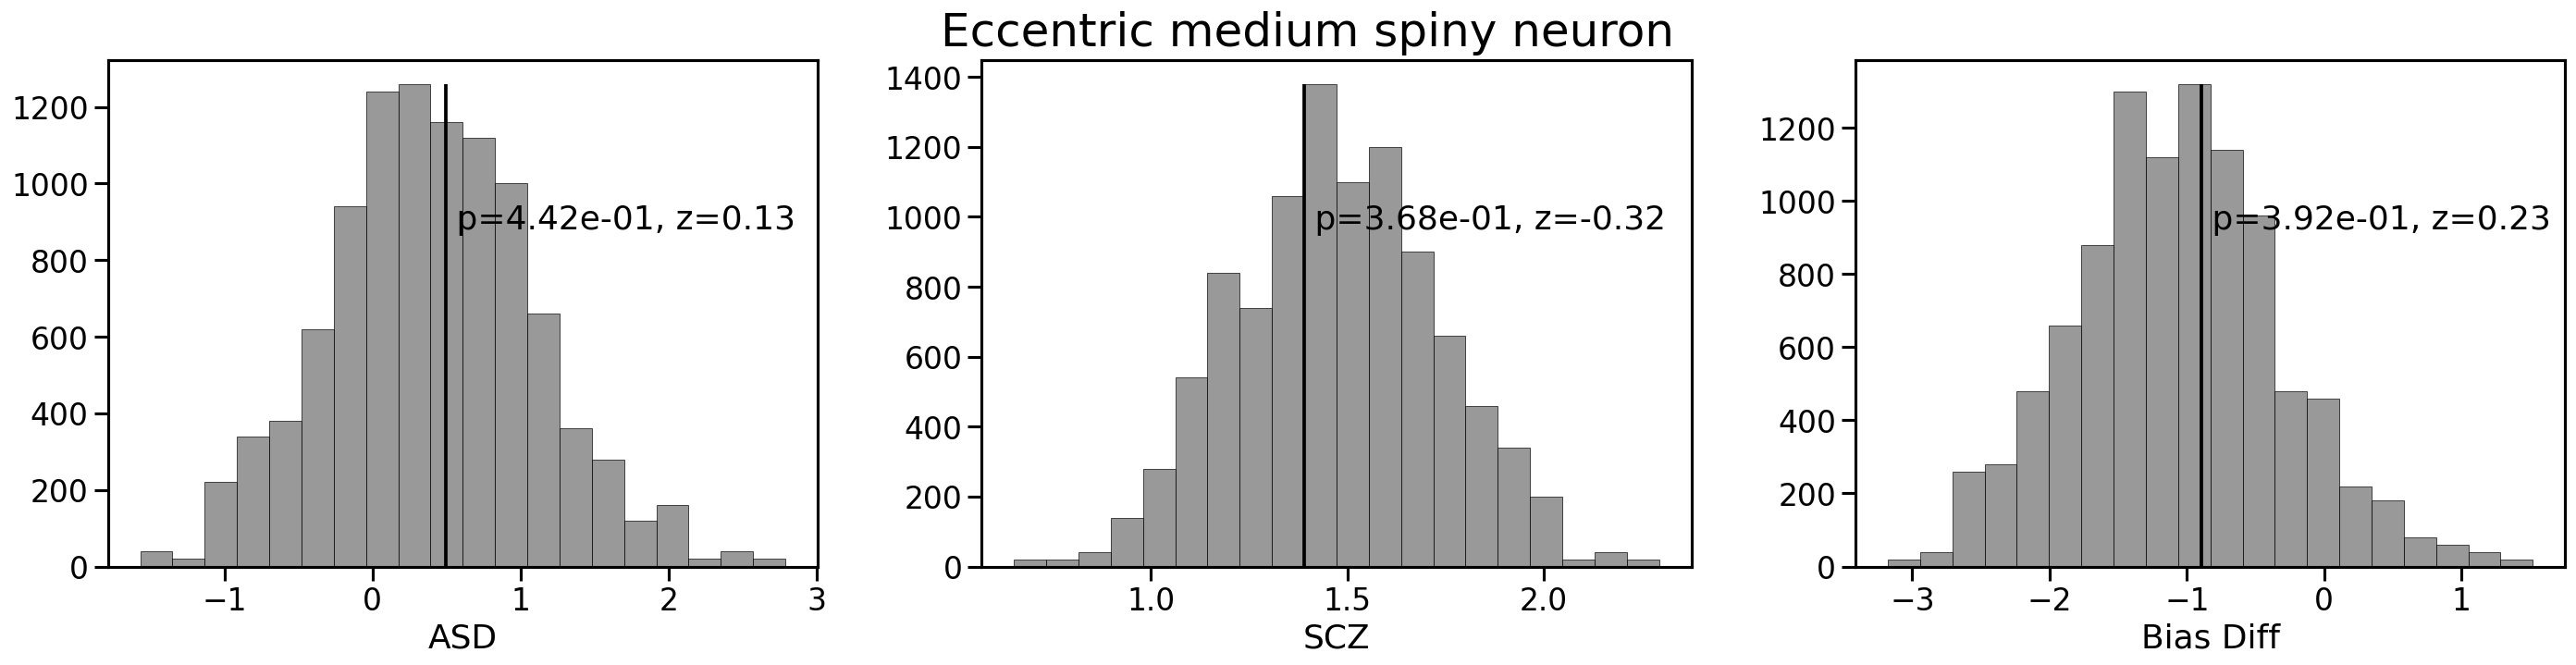

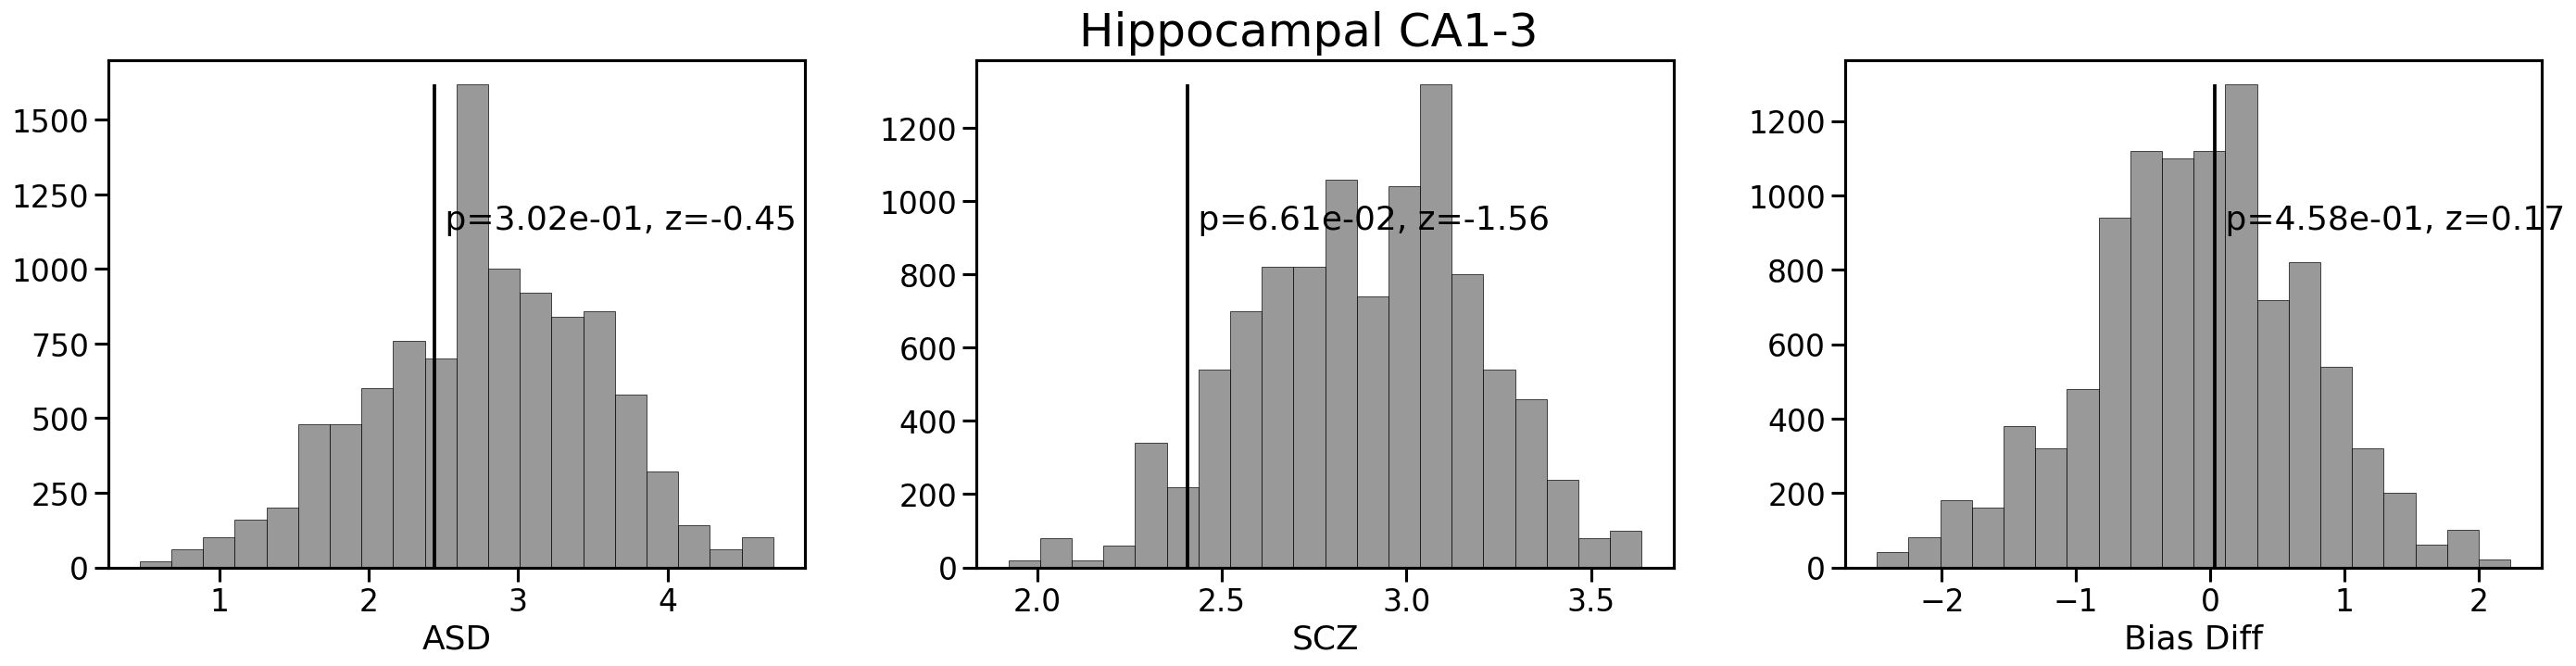

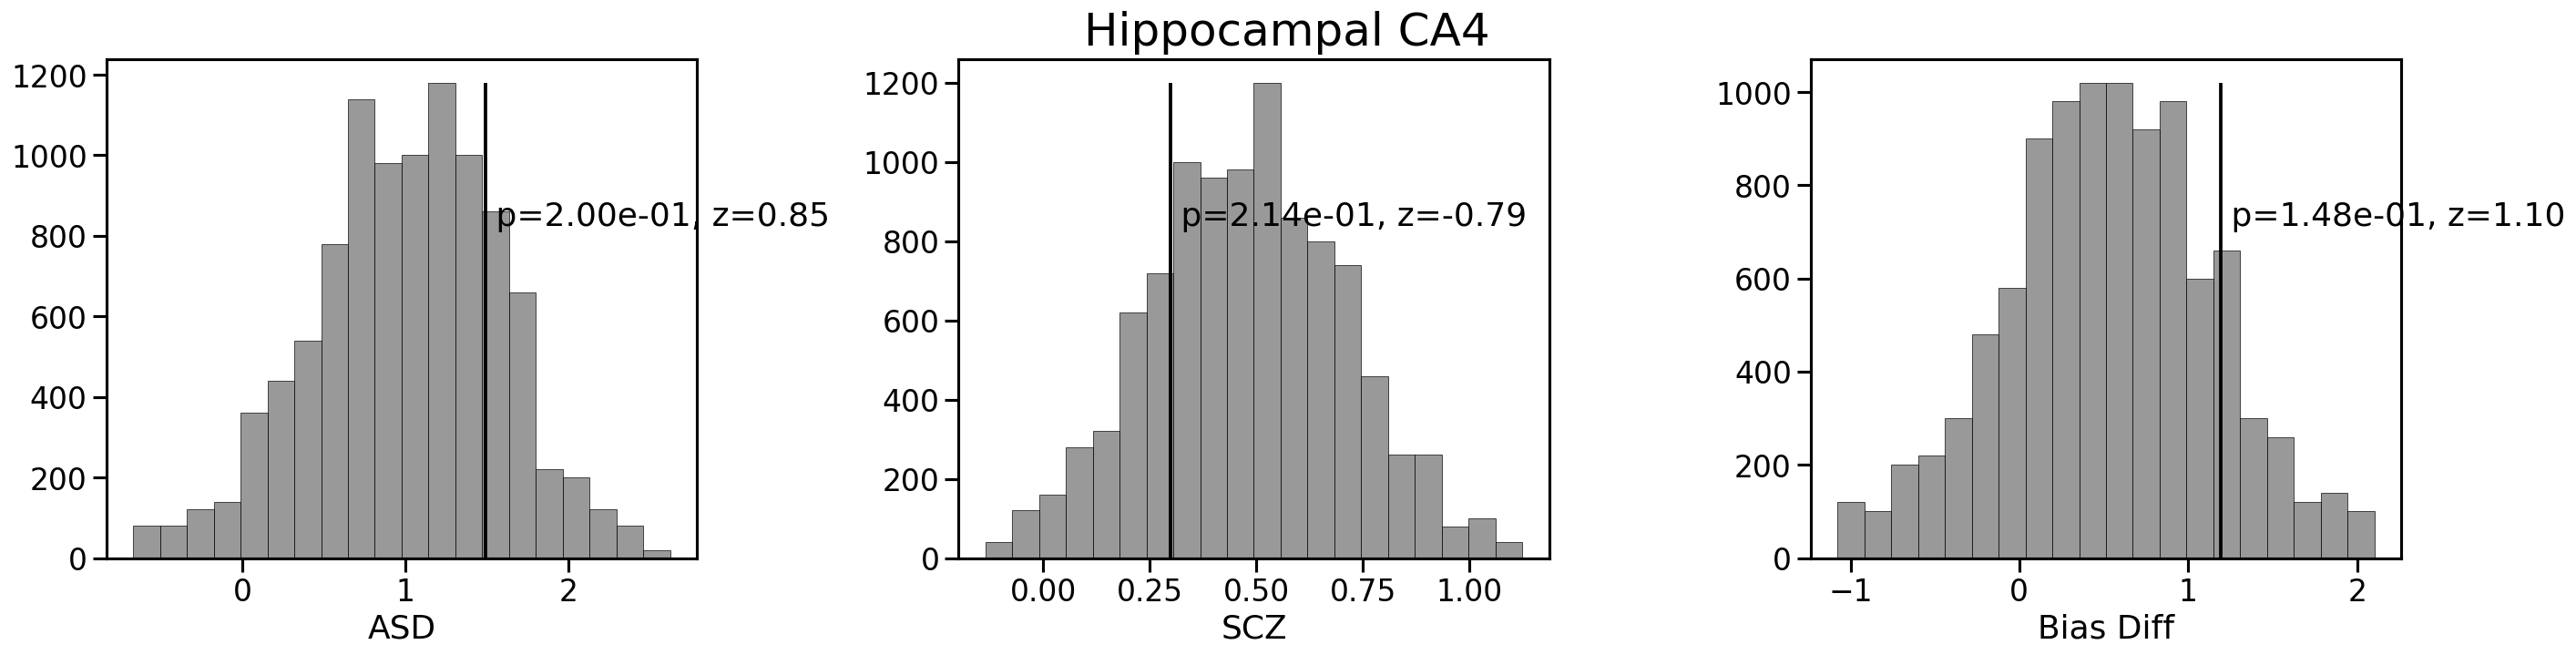

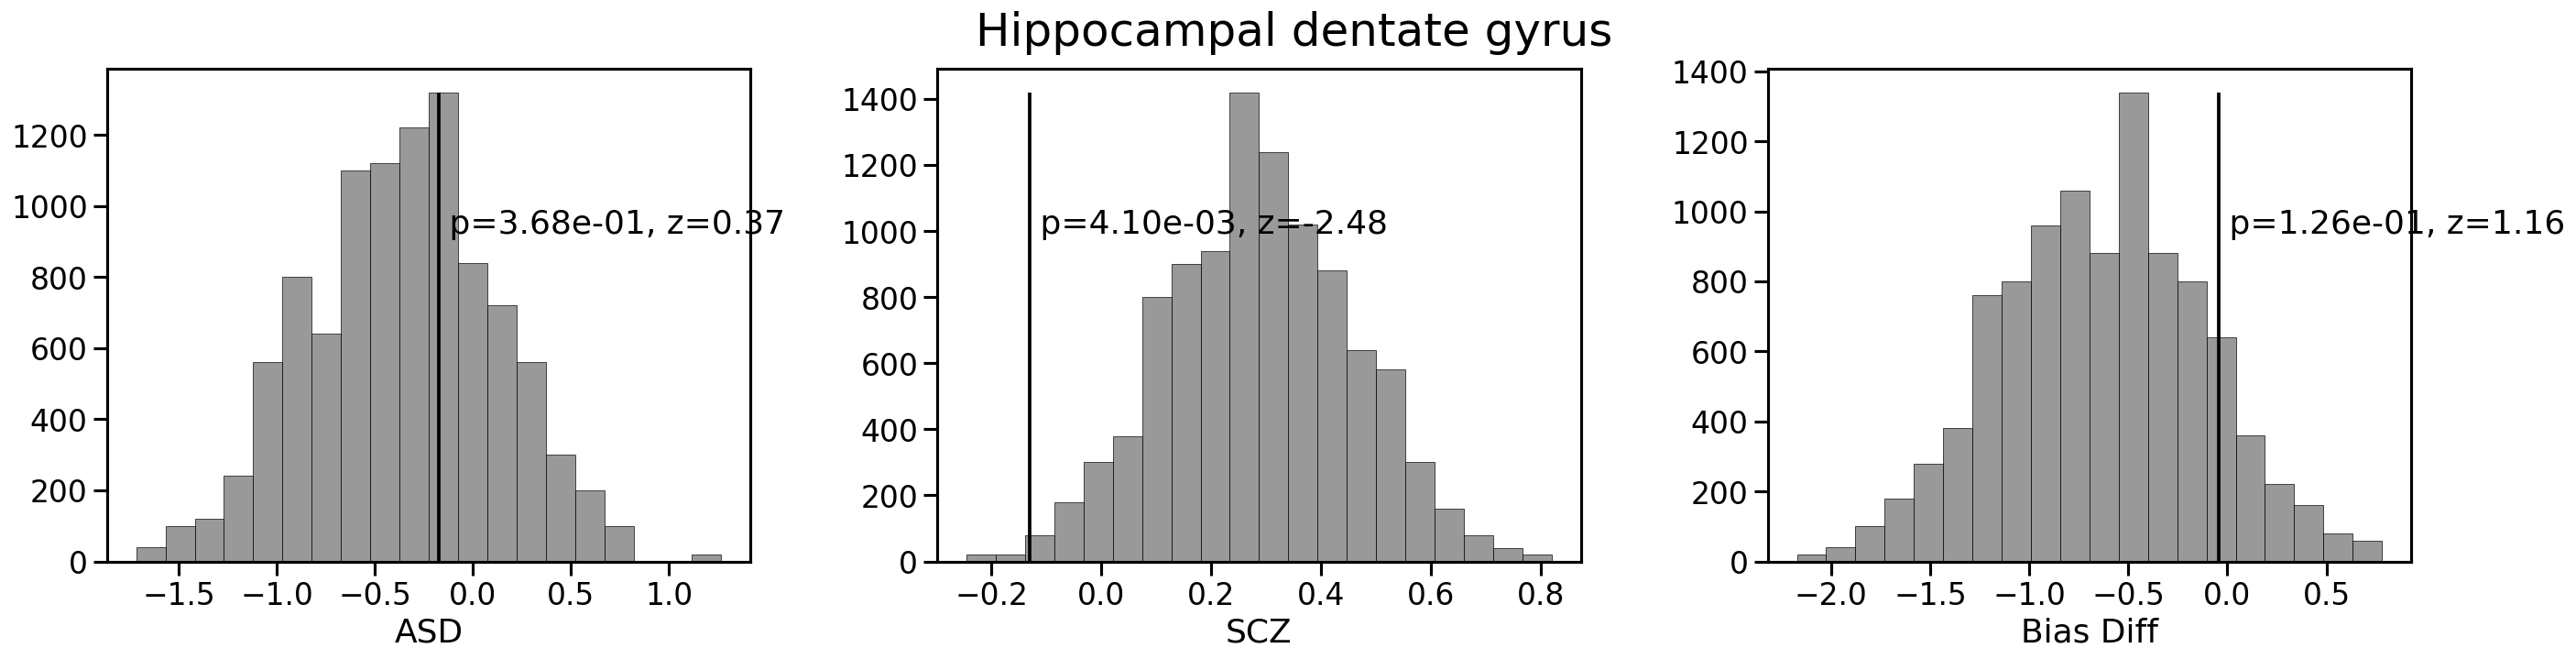

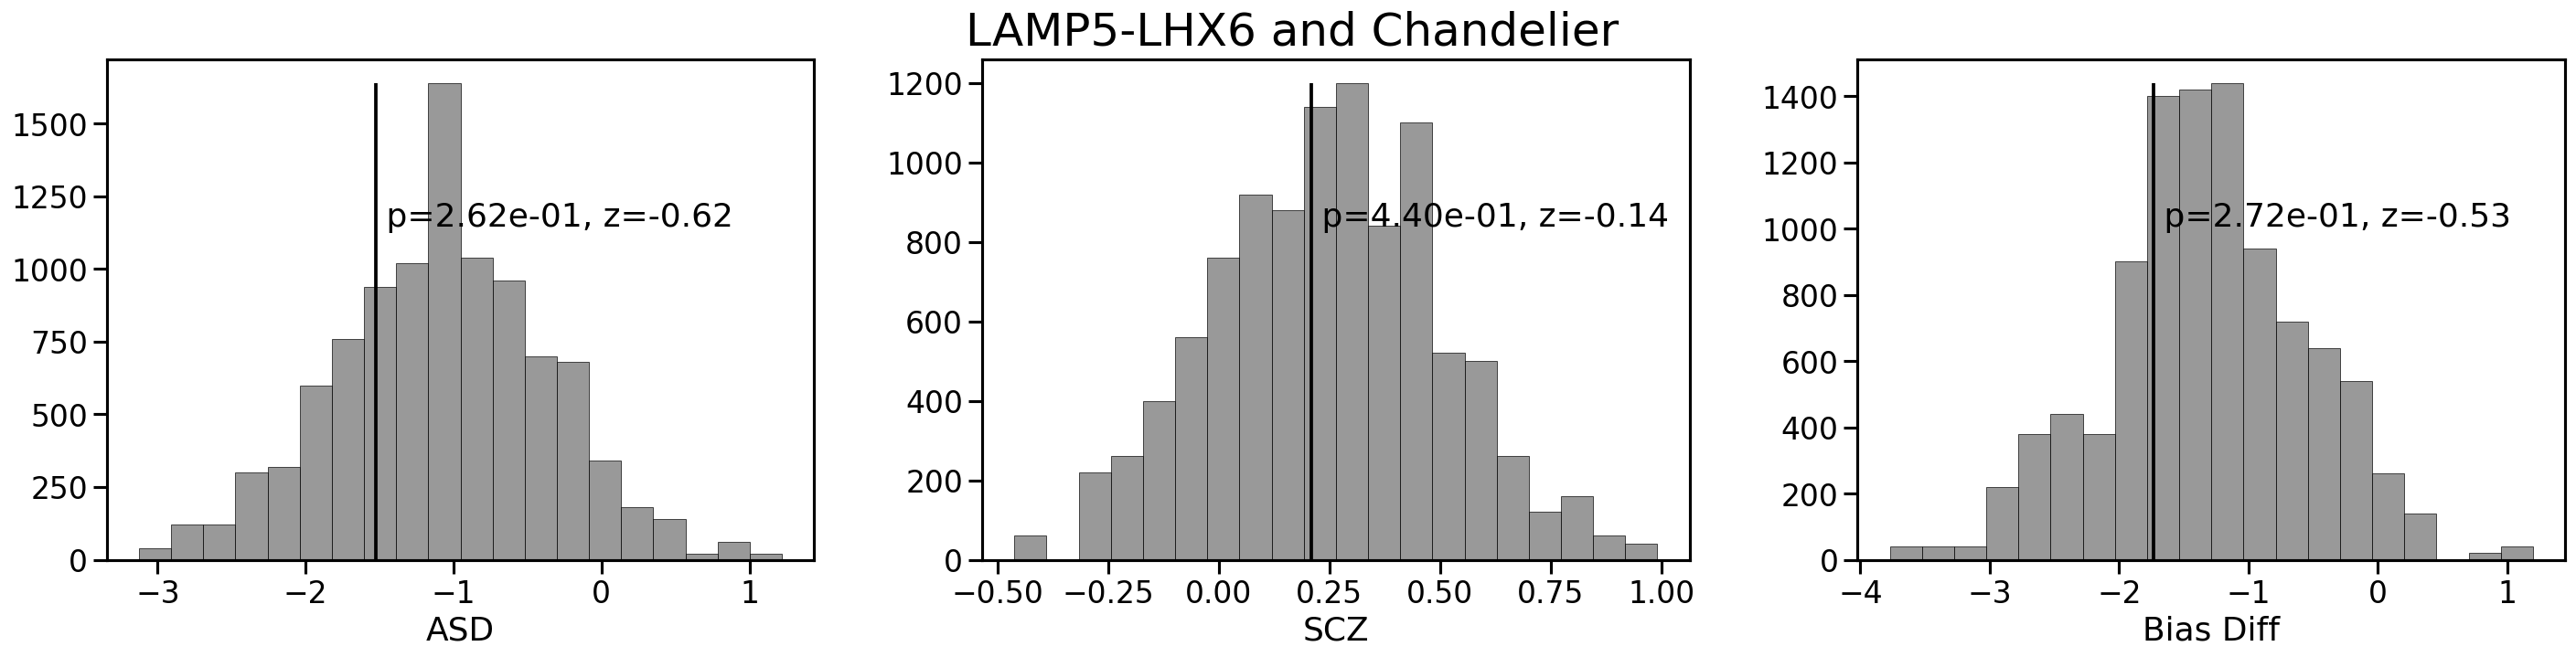

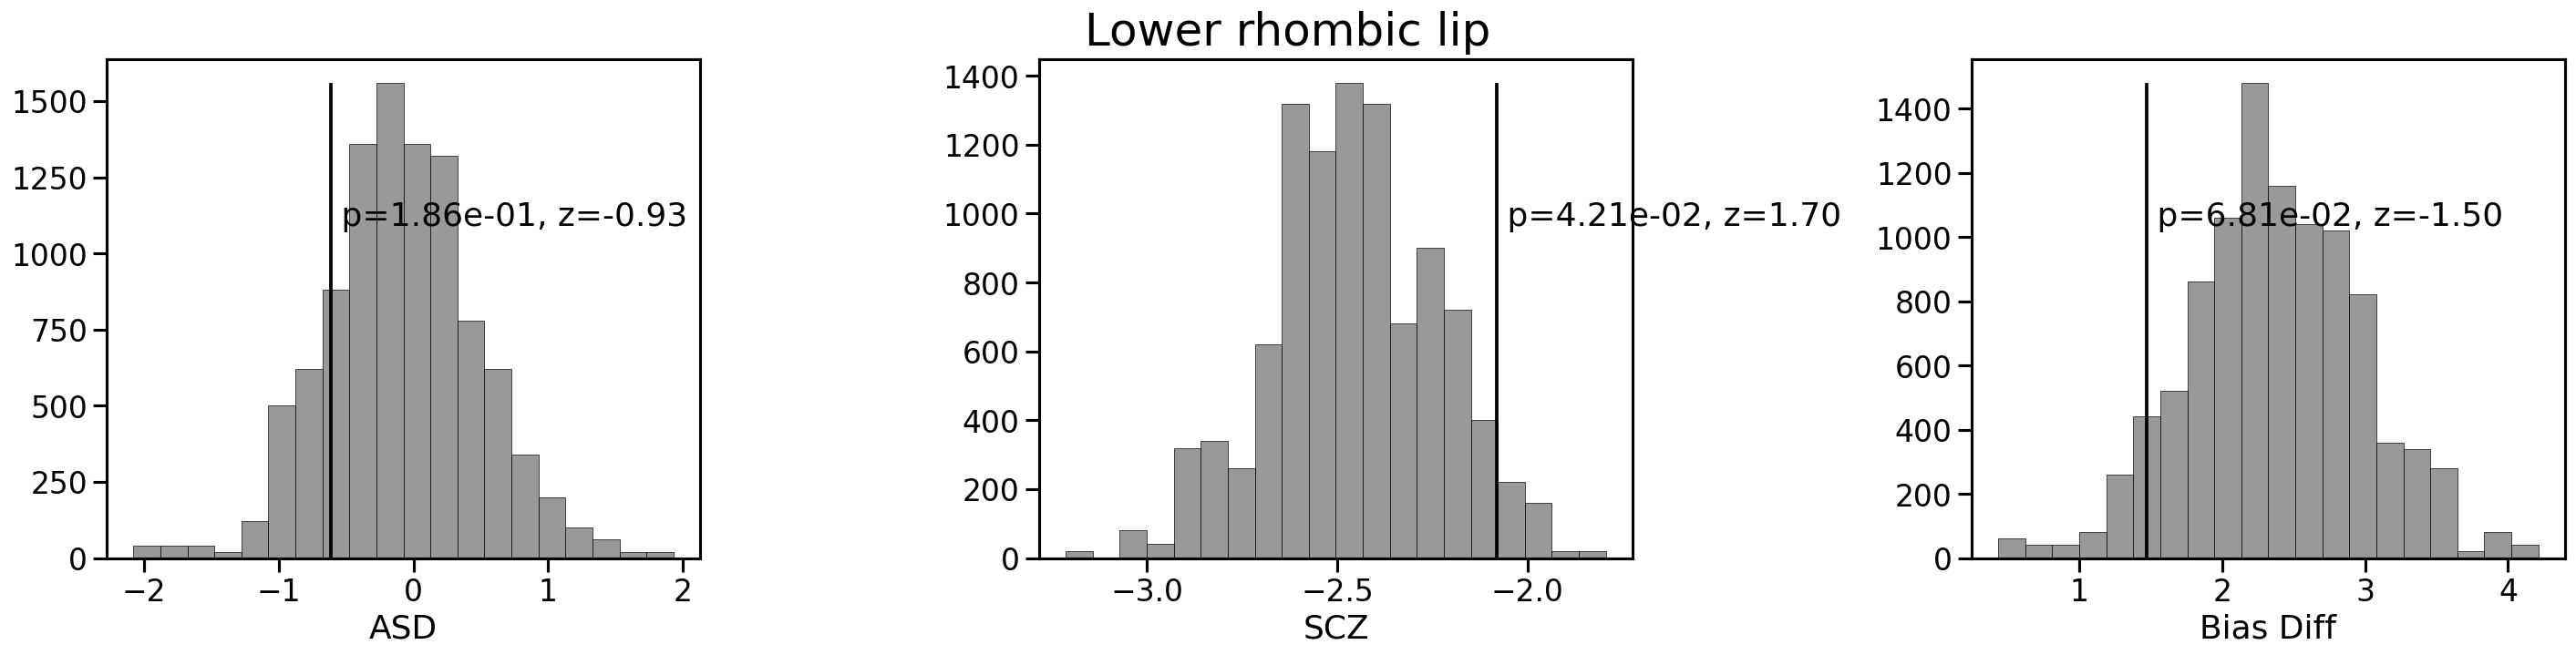

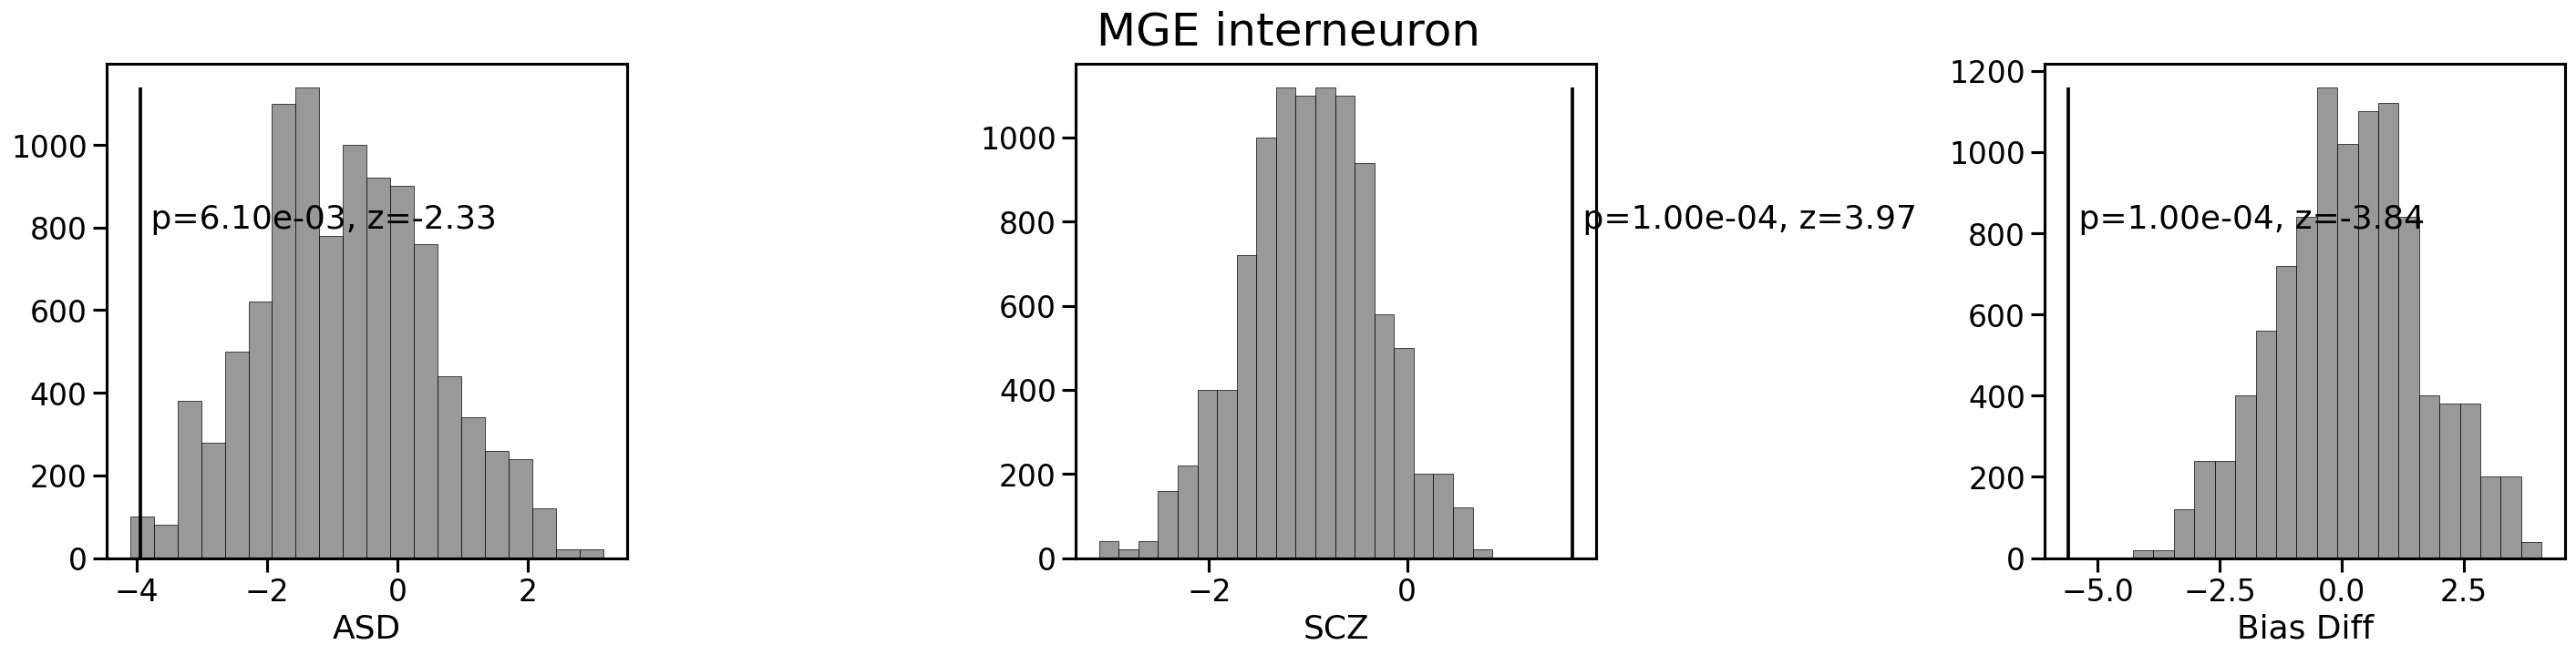

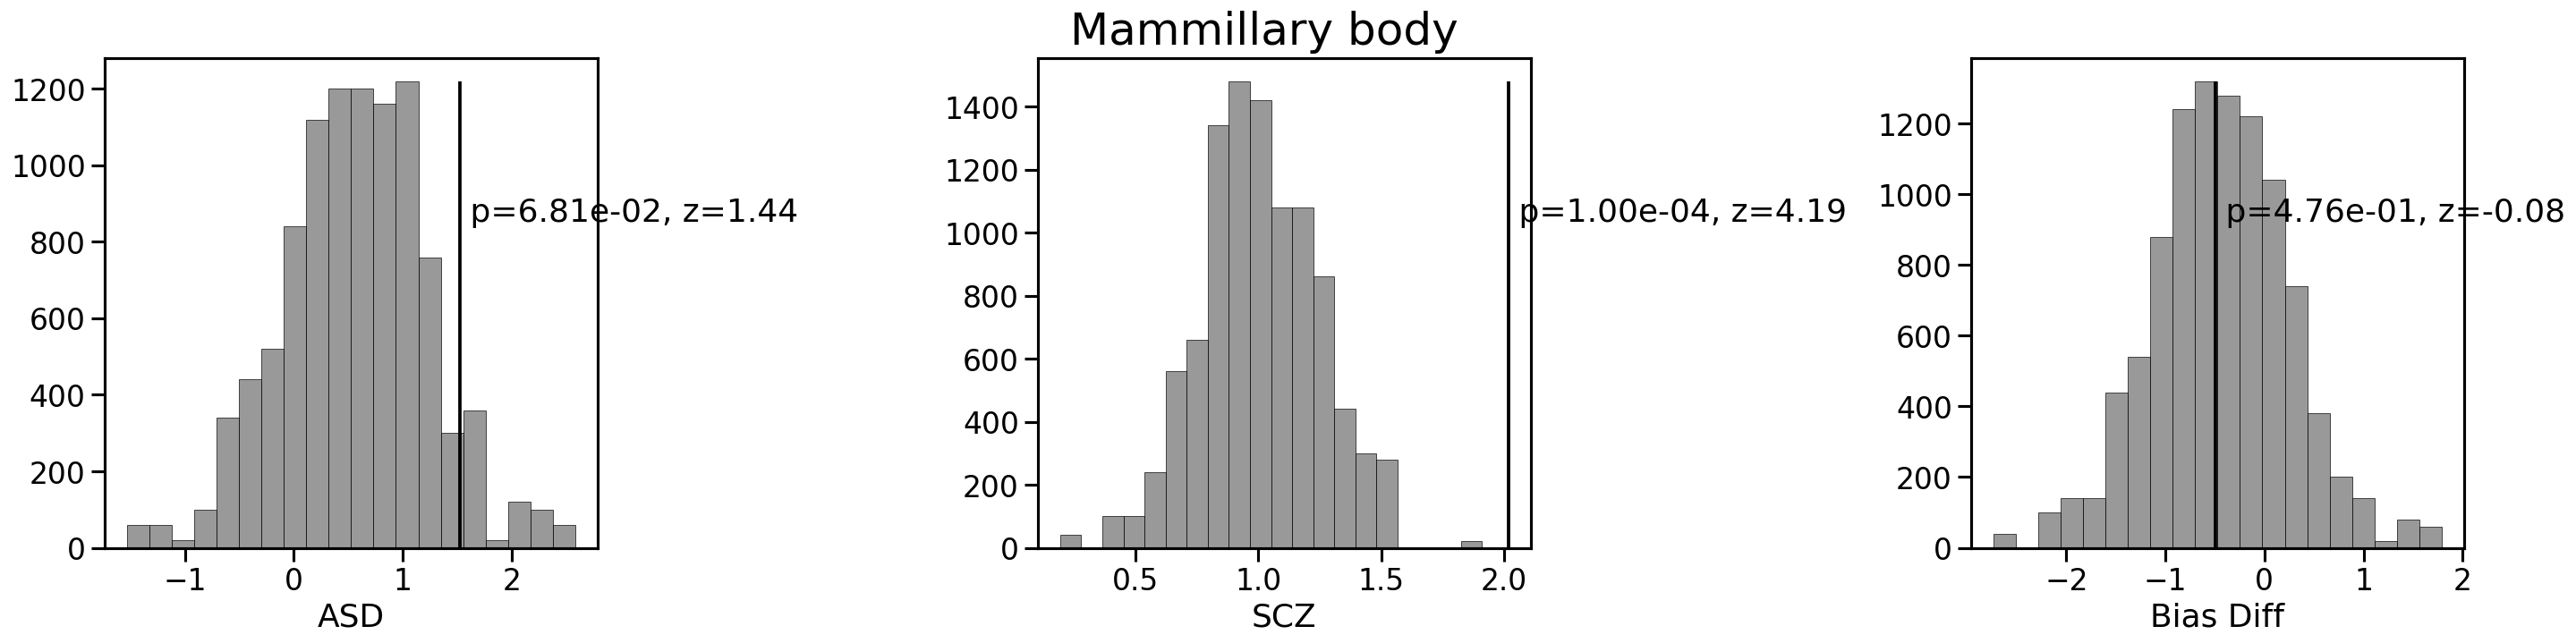

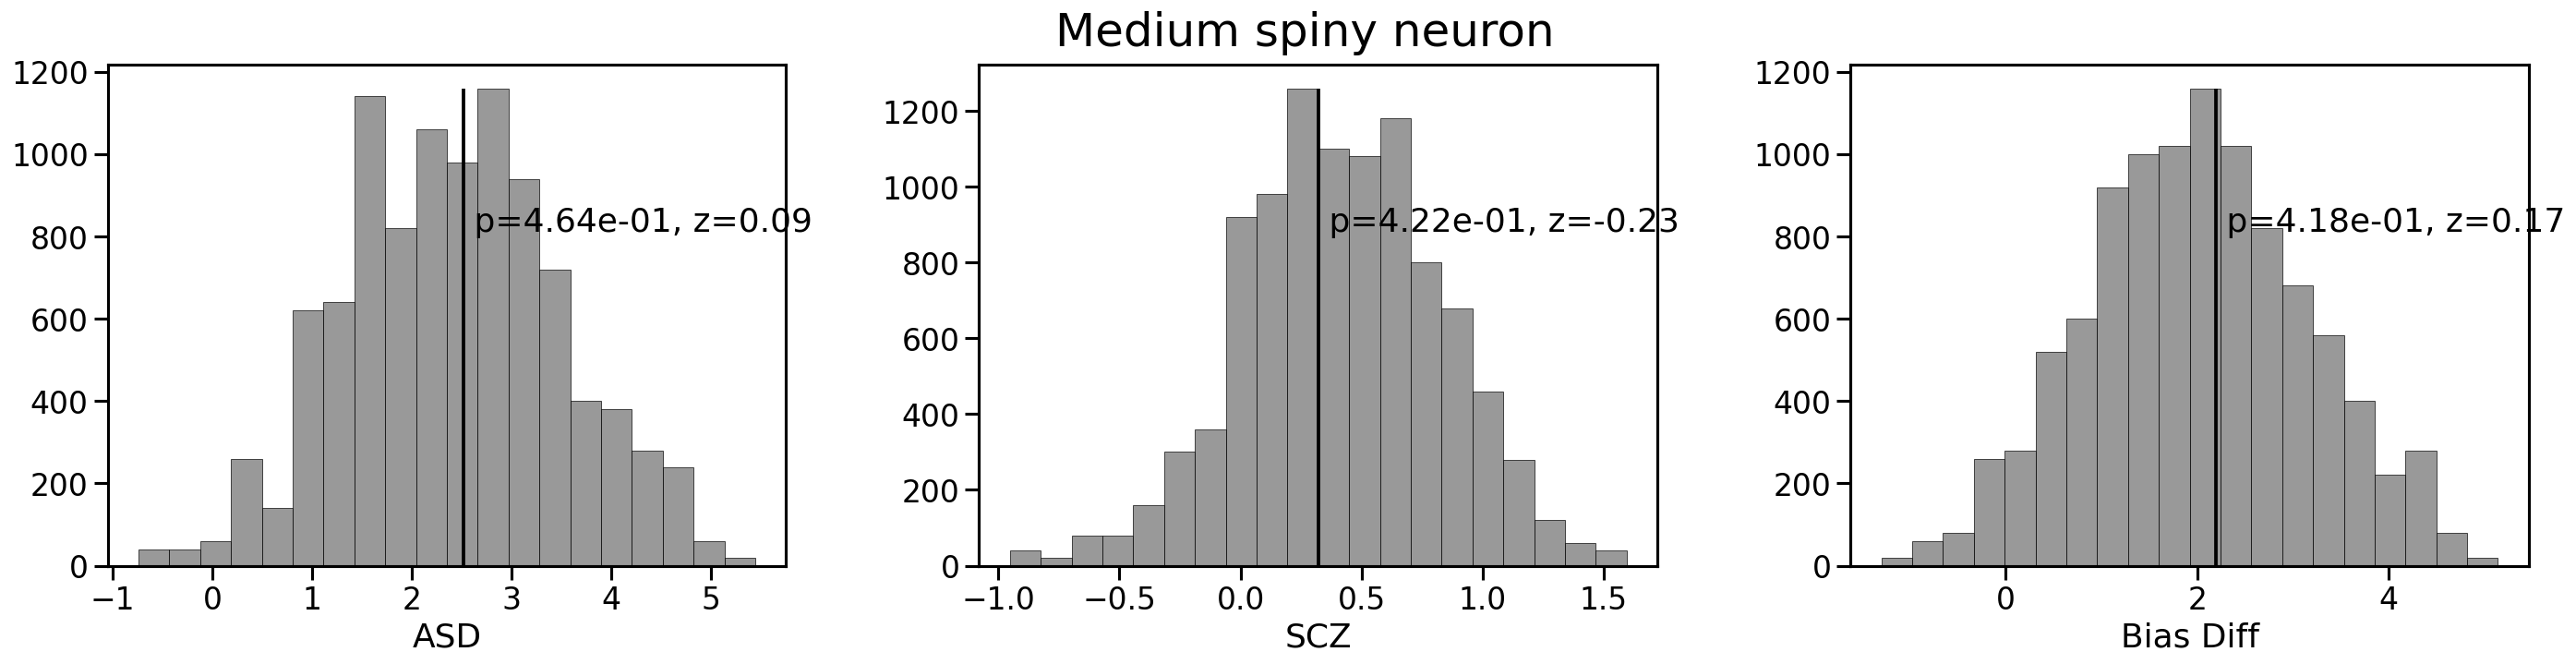

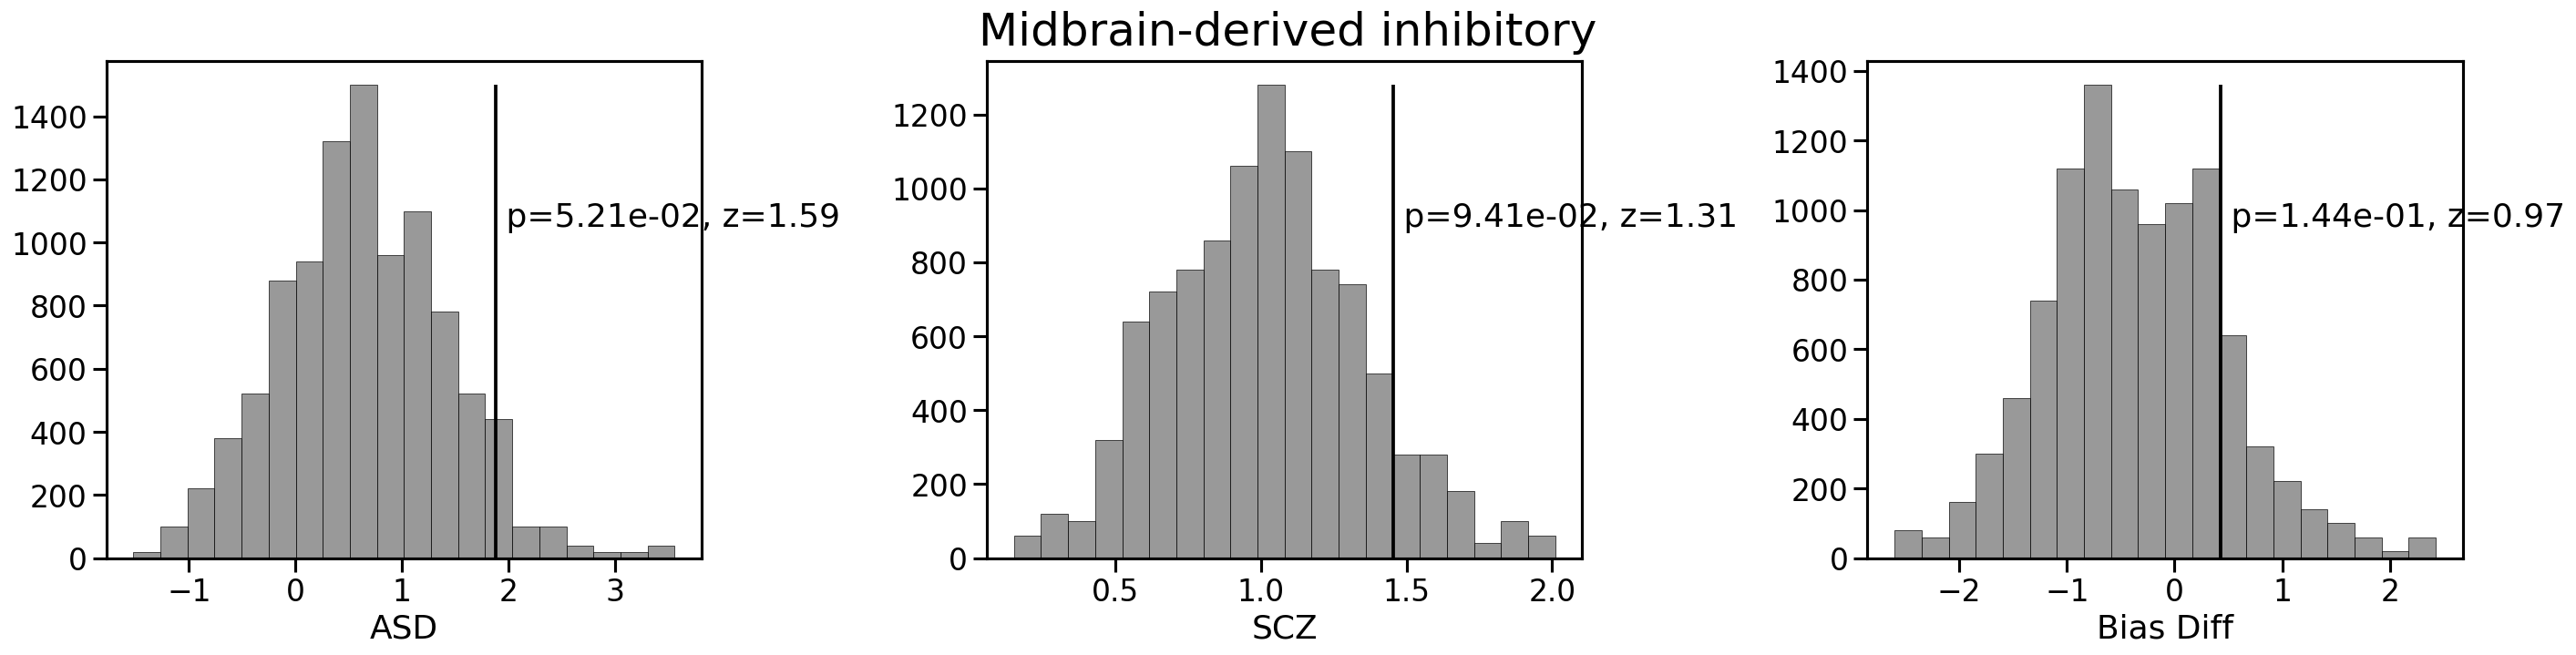

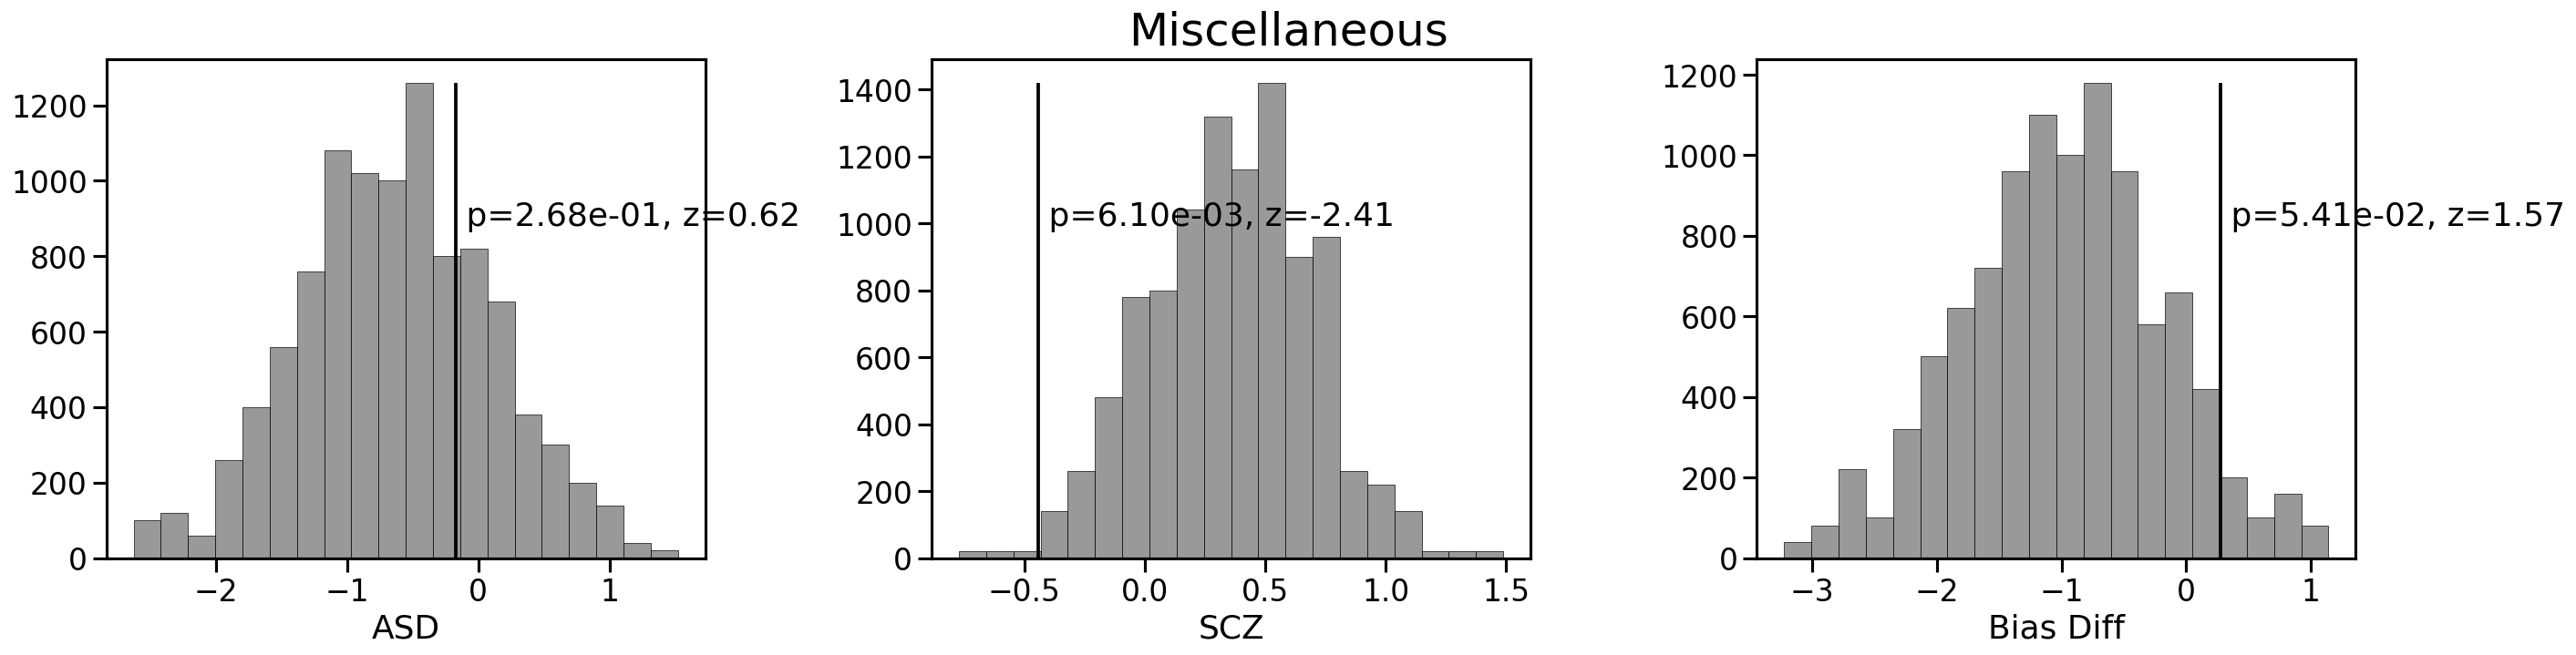

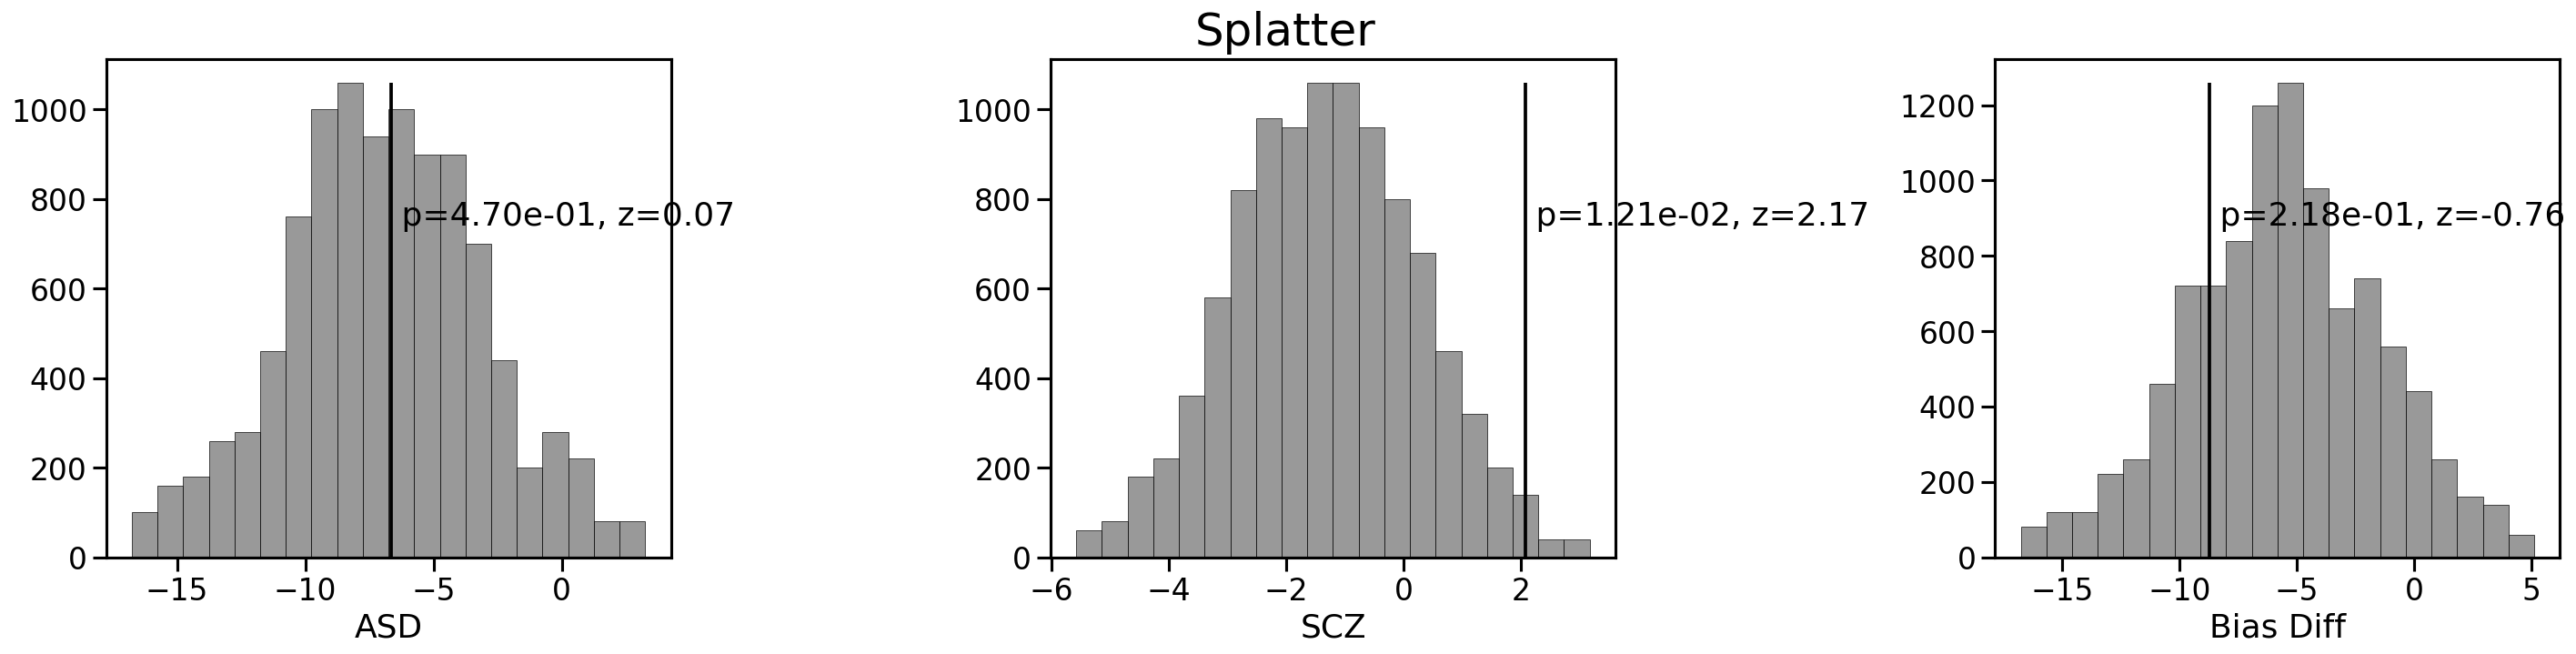

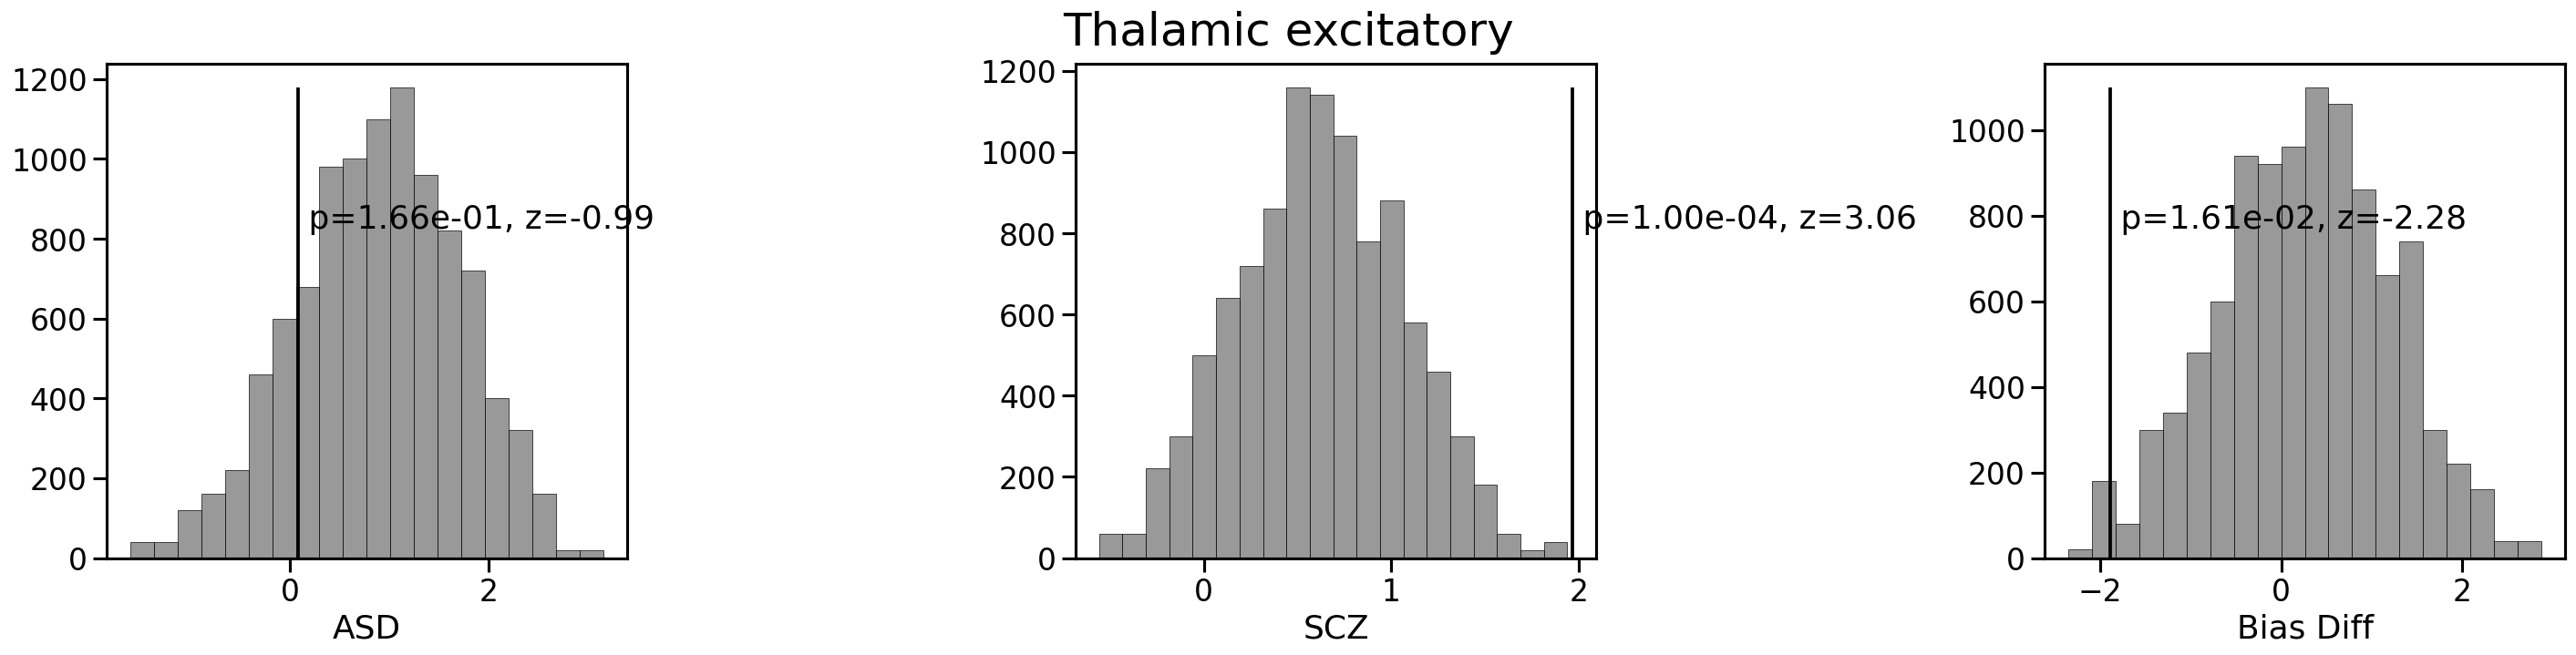

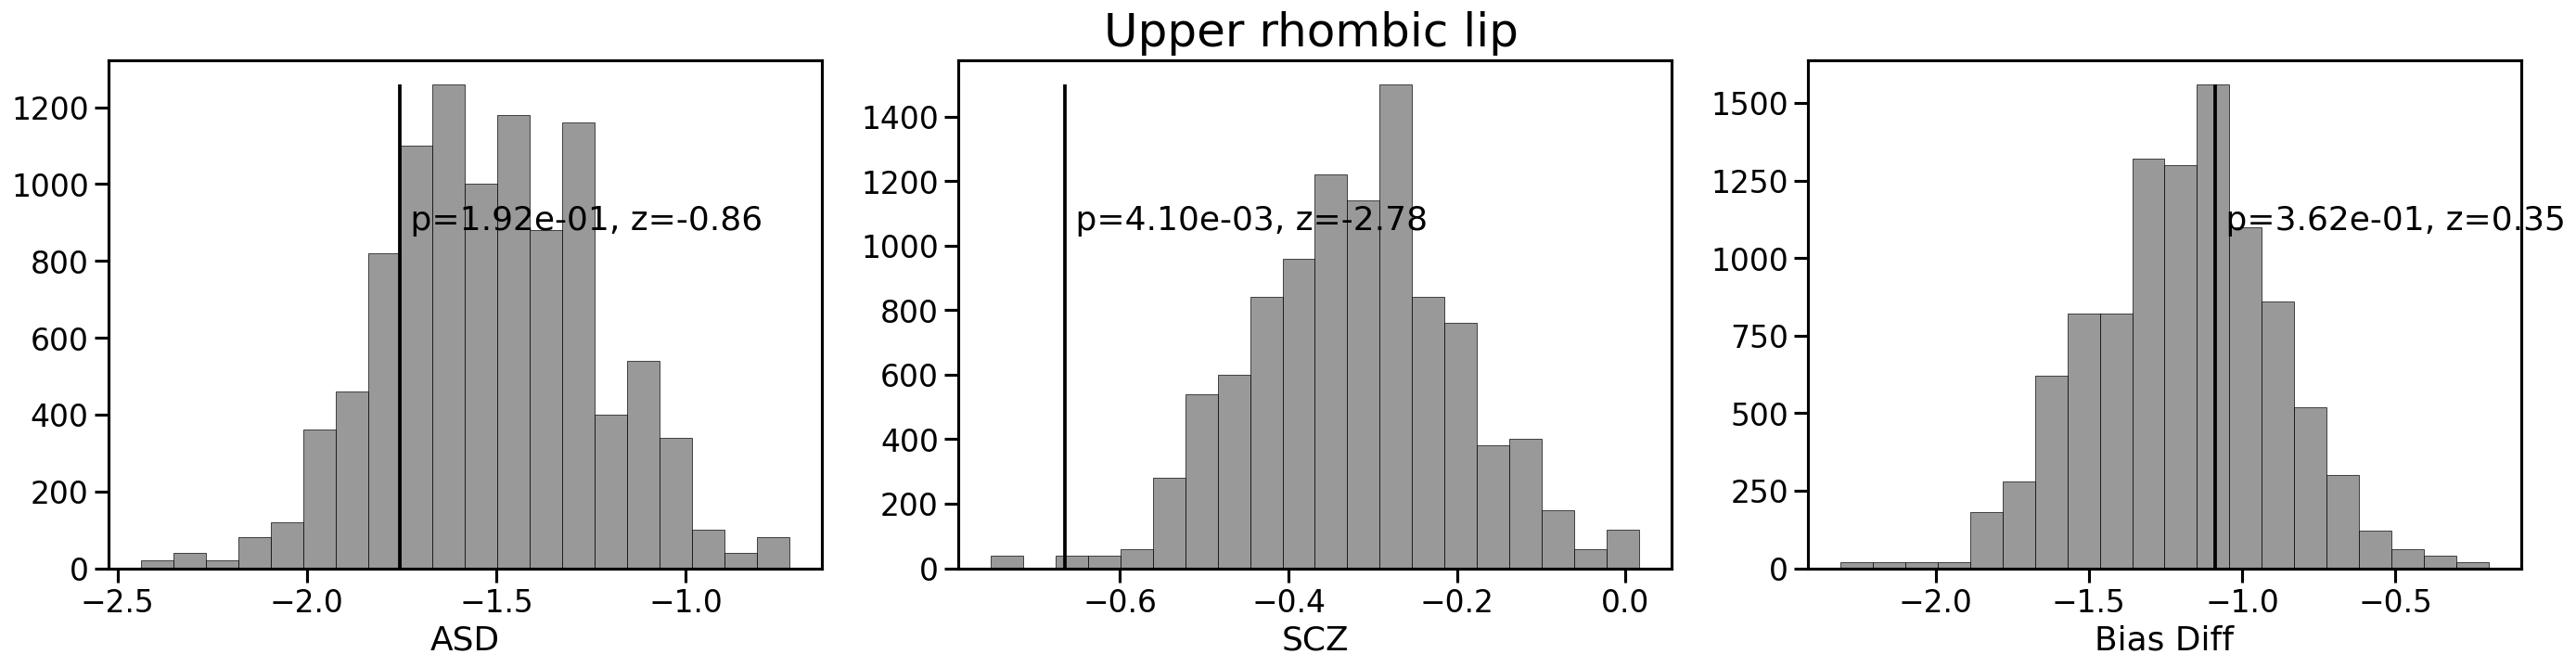

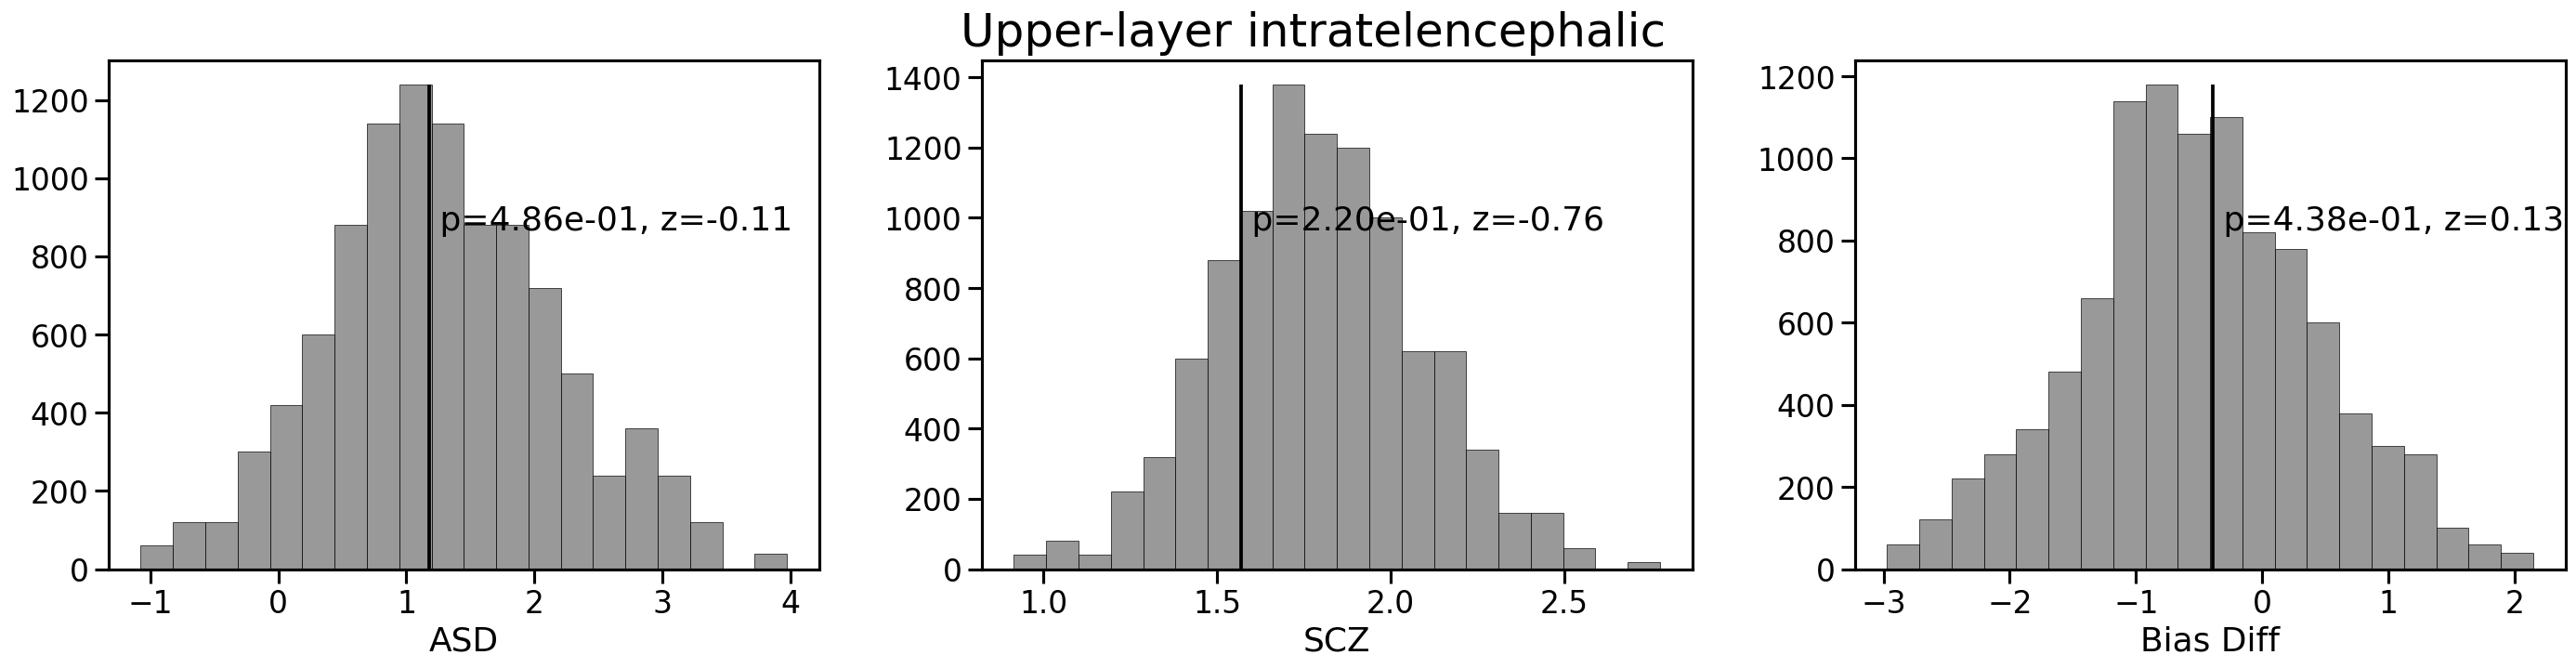

In [578]:
#CT = "CGE interneuron"
for CT in Neurons:
    TestDiff_Perm(CT, ASD_CT_Bias, SCZ_CT_Bias, Permut_ASD_DF_MutPerm_CT, Permut_SCZ_DF_MutPerm_CT)

In [624]:
Permut_ASD_DF_MutPerm_v5 = []
Permut_SCZ_DF_MutPerm_v5 = []
DIR = "/home/jw3514/Work/CellType_Psy/dat/CTRL/BiasDiff_RW/HIQASD_SCZ_v5/"
N=10000
for i in range(N):
    try:
        DF1 = pd.read_csv("{}/{}.ASD.perm.bias.csv".format(DIR, i), index_col=0)
        DF2 = pd.read_csv("{}/{}.SCZ.perm.bias.csv".format(DIR, i), index_col=0)
        Permut_ASD_DF_MutPerm_v5.append(DF1)
        Permut_SCZ_DF_MutPerm_v5.append(DF2)
    except:
        continue
N_Perm = len(Permut_ASD_DF_MutPerm_v5)
print(N_Perm)

10000


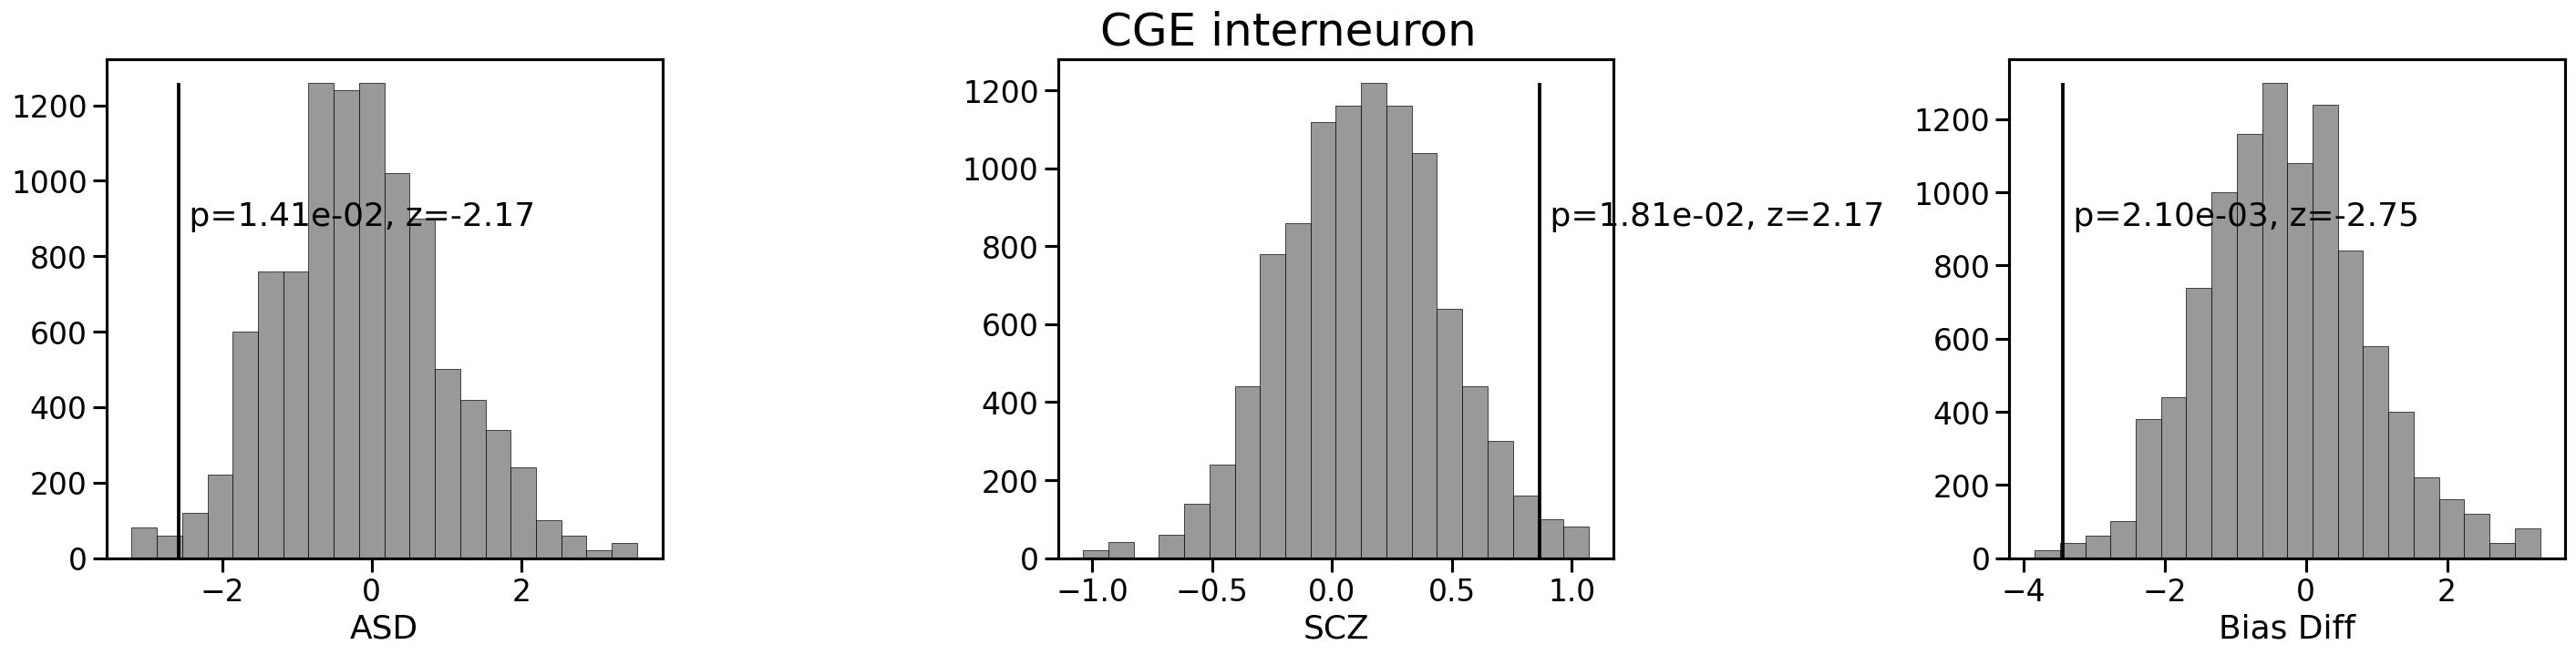

In [625]:
CT = "CGE interneuron"
TestDiff_Perm(CT, ASD_CT_Bias, SCZ_CT_Bias, Permut_ASD_DF_MutPerm_v5, Permut_SCZ_DF_MutPerm_v5)

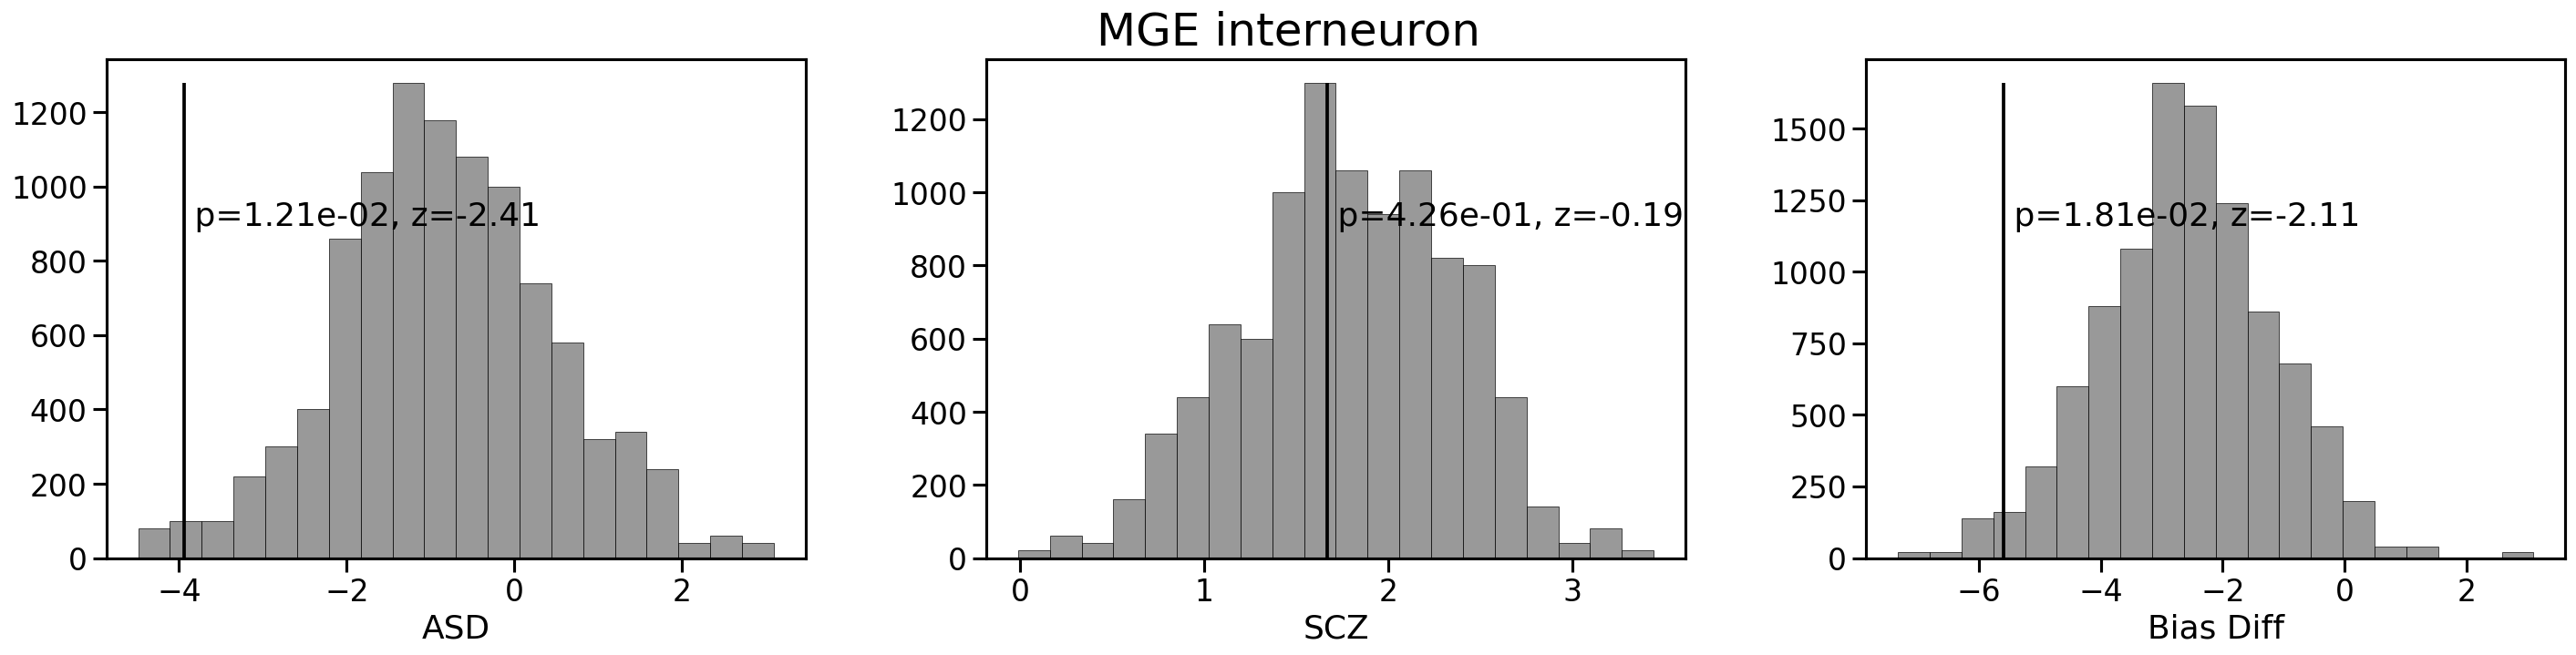

In [626]:
CT = "MGE interneuron"
TestDiff_Perm(CT, ASD_CT_Bias, SCZ_CT_Bias, Permut_ASD_DF_MutPerm_v5, Permut_SCZ_DF_MutPerm_v5)

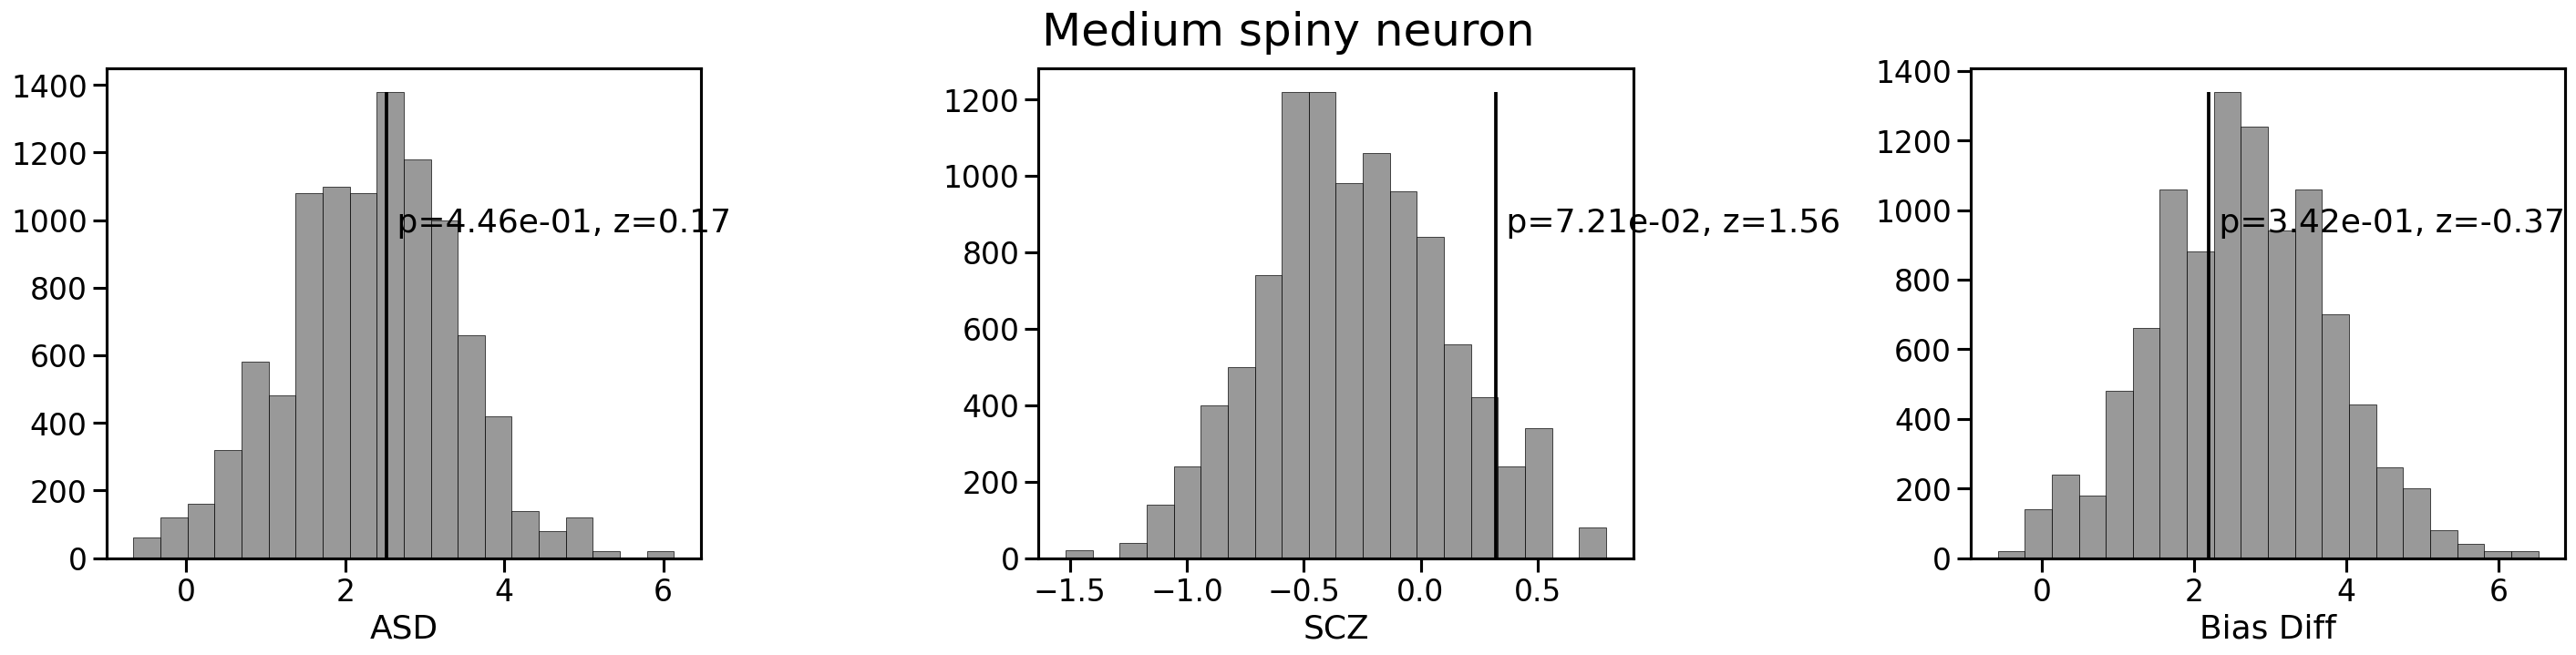

In [627]:
CT = "Medium spiny neuron"
TestDiff_Perm(CT, ASD_CT_Bias, SCZ_CT_Bias, Permut_ASD_DF_MutPerm_v5, Permut_SCZ_DF_MutPerm_v5)

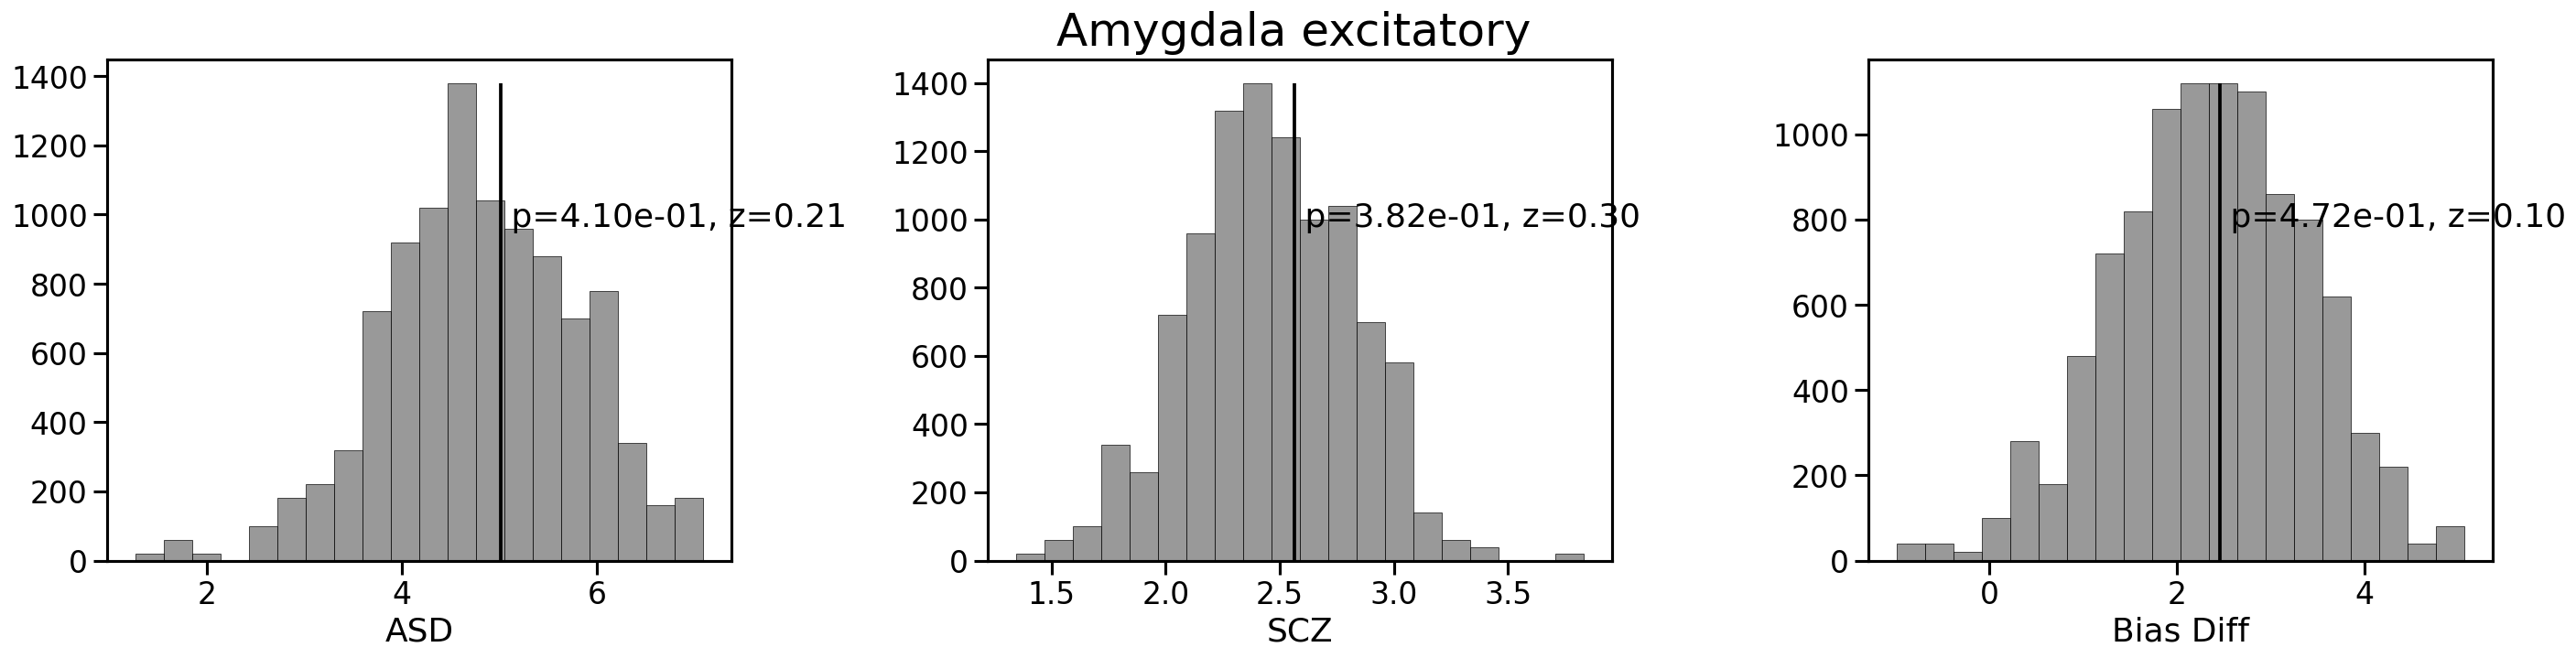

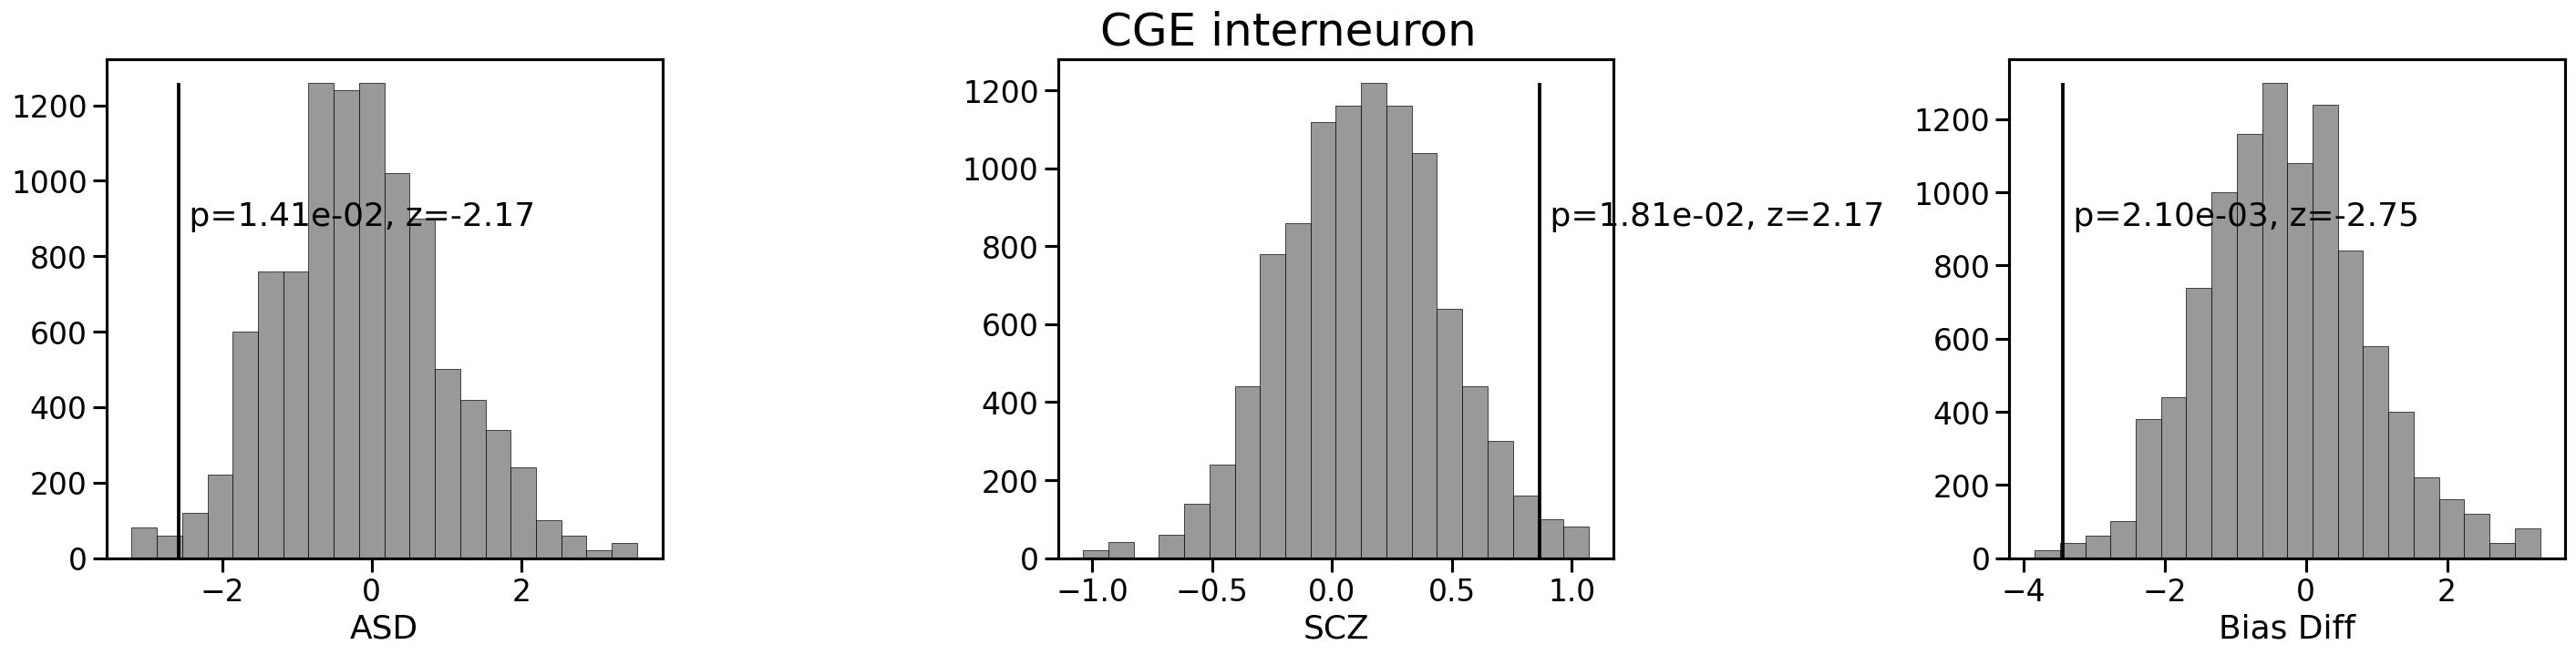

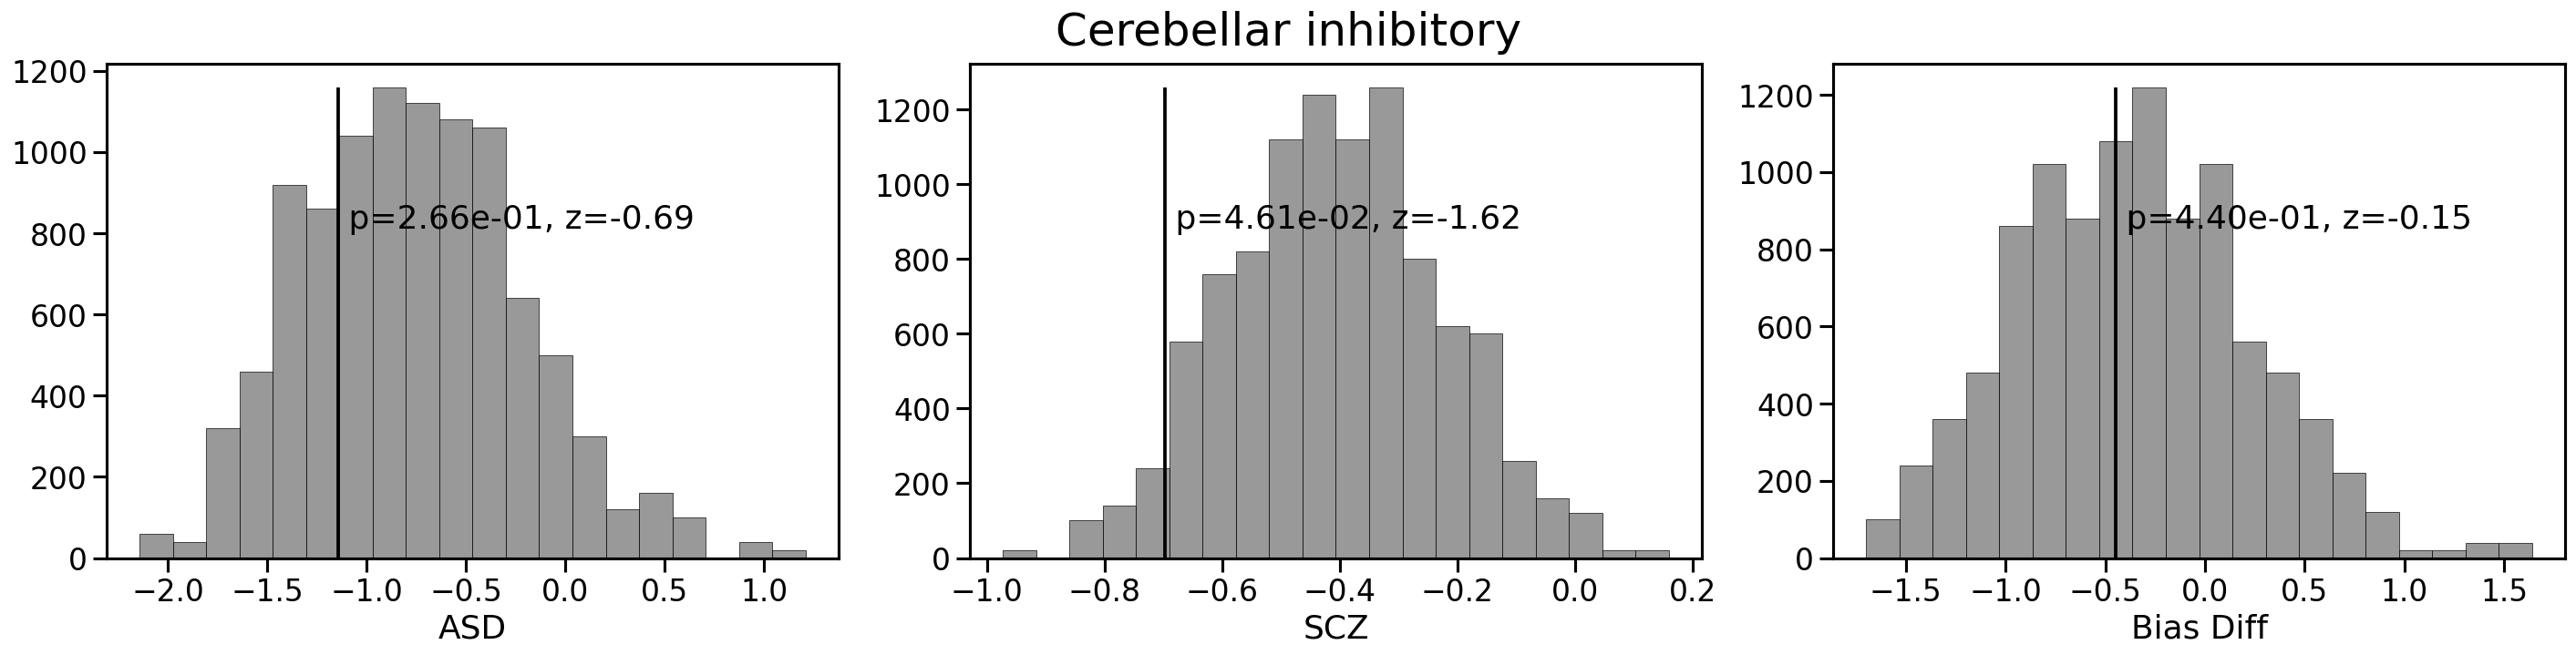

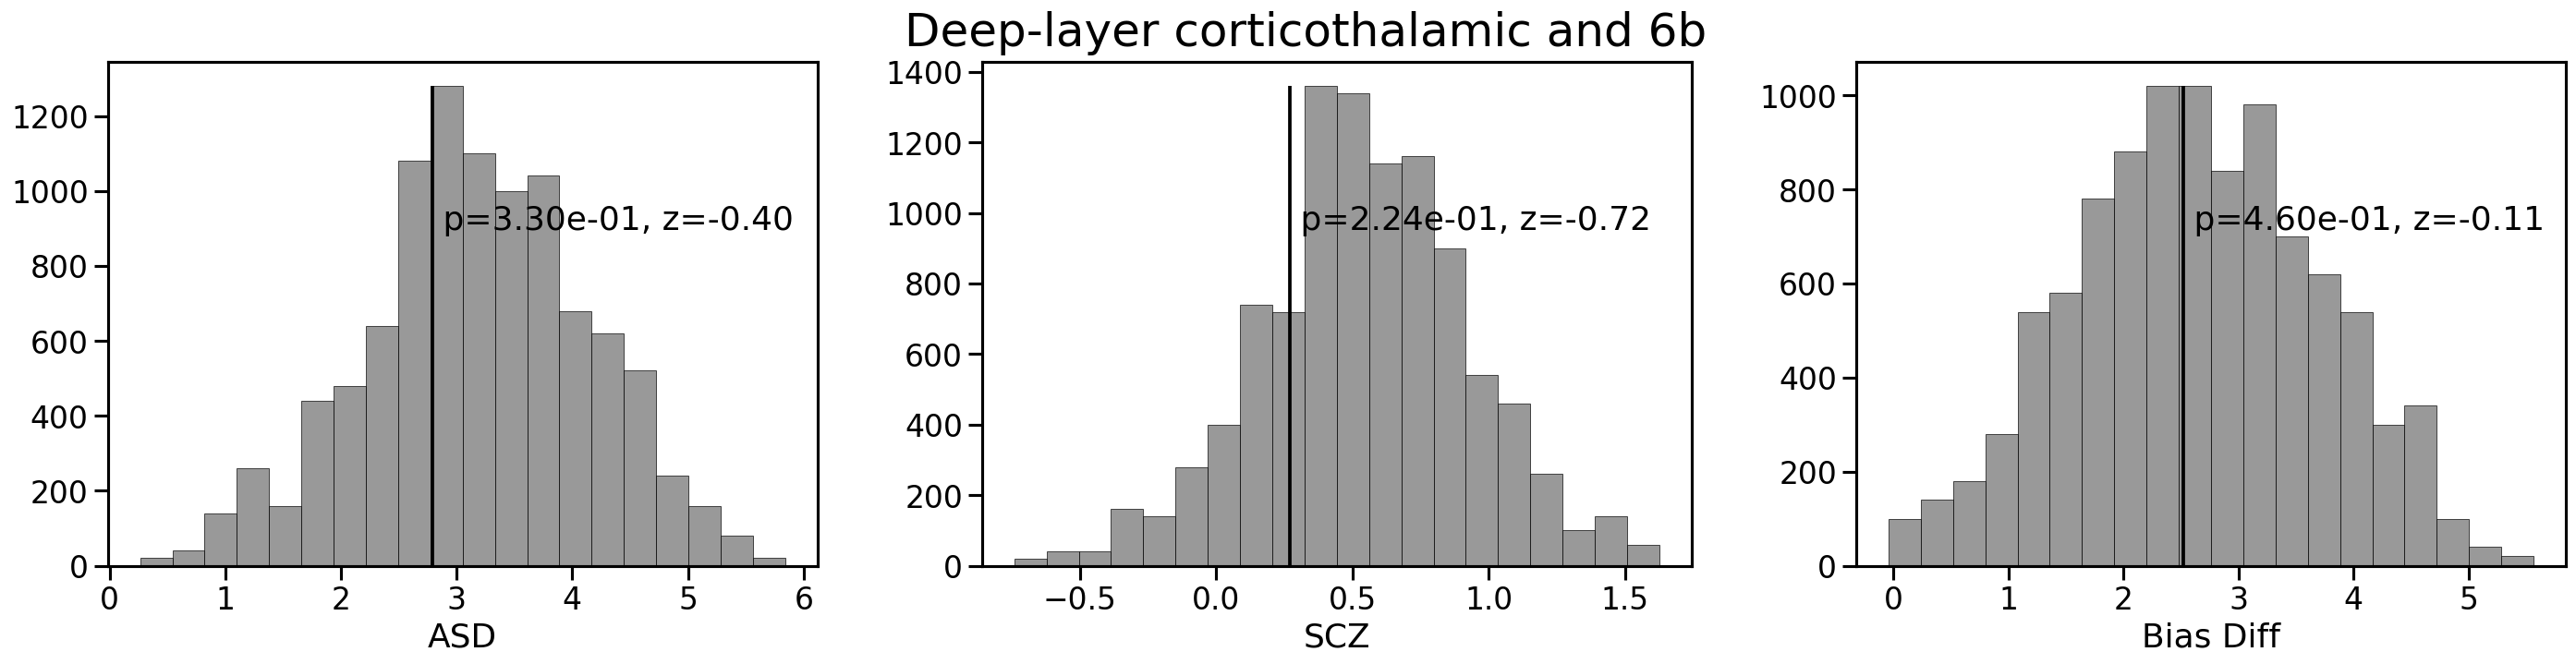

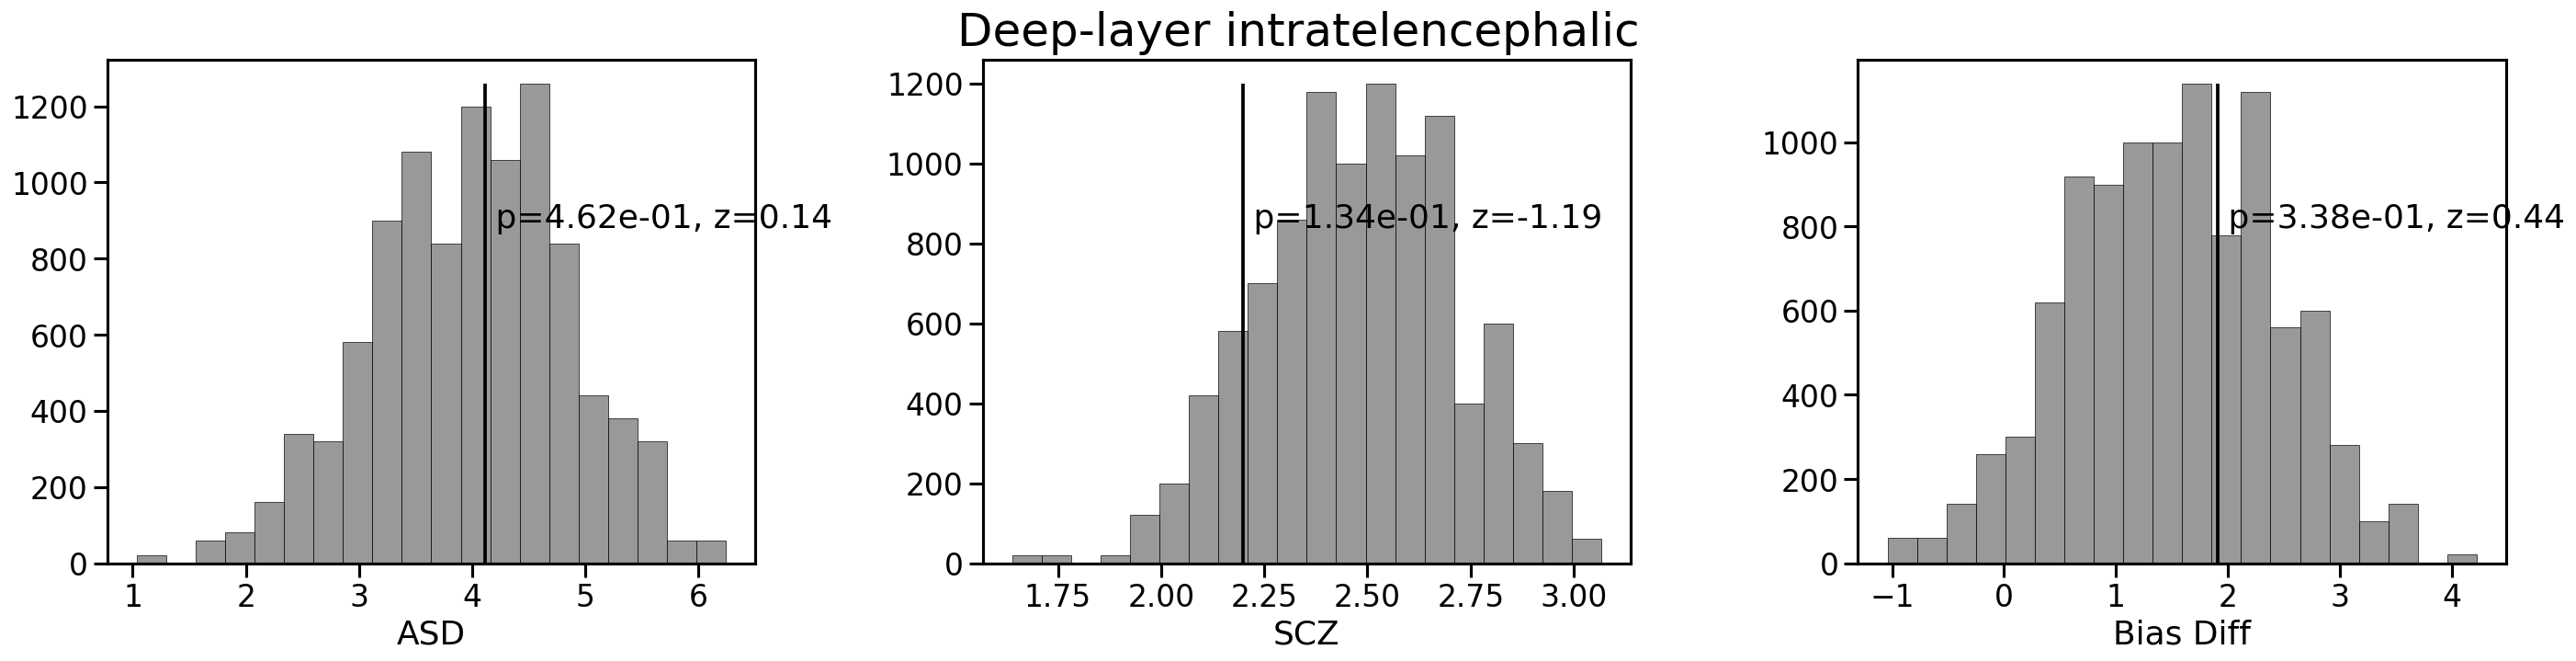

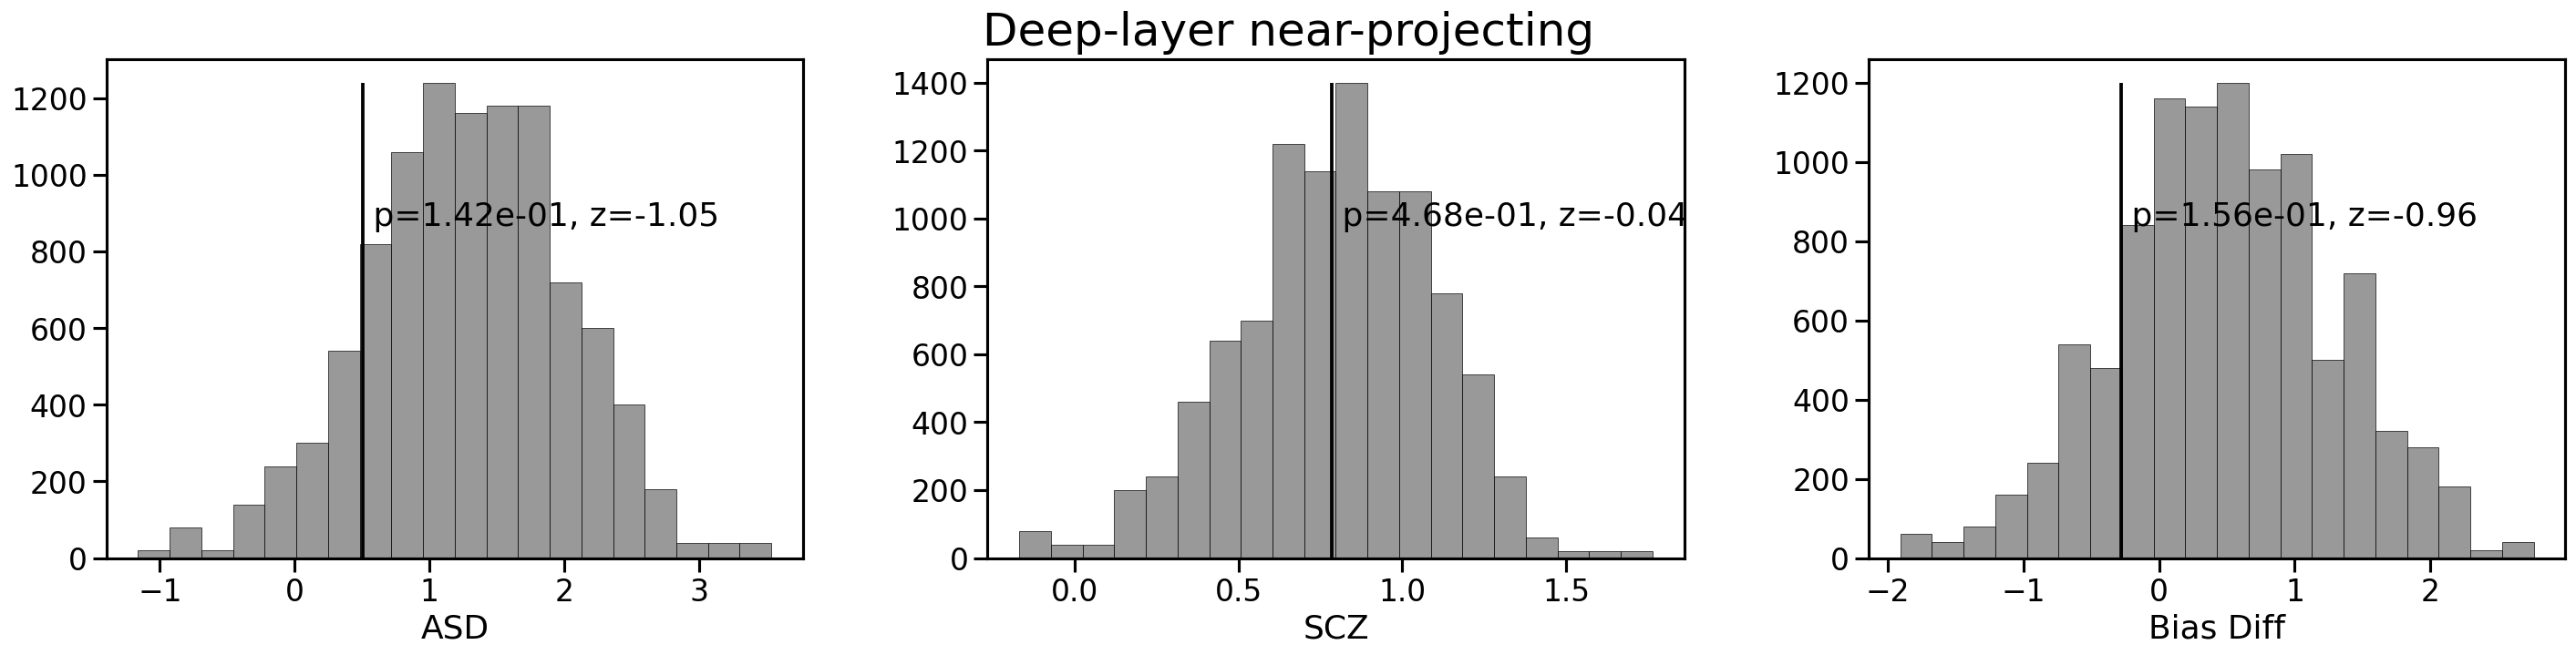

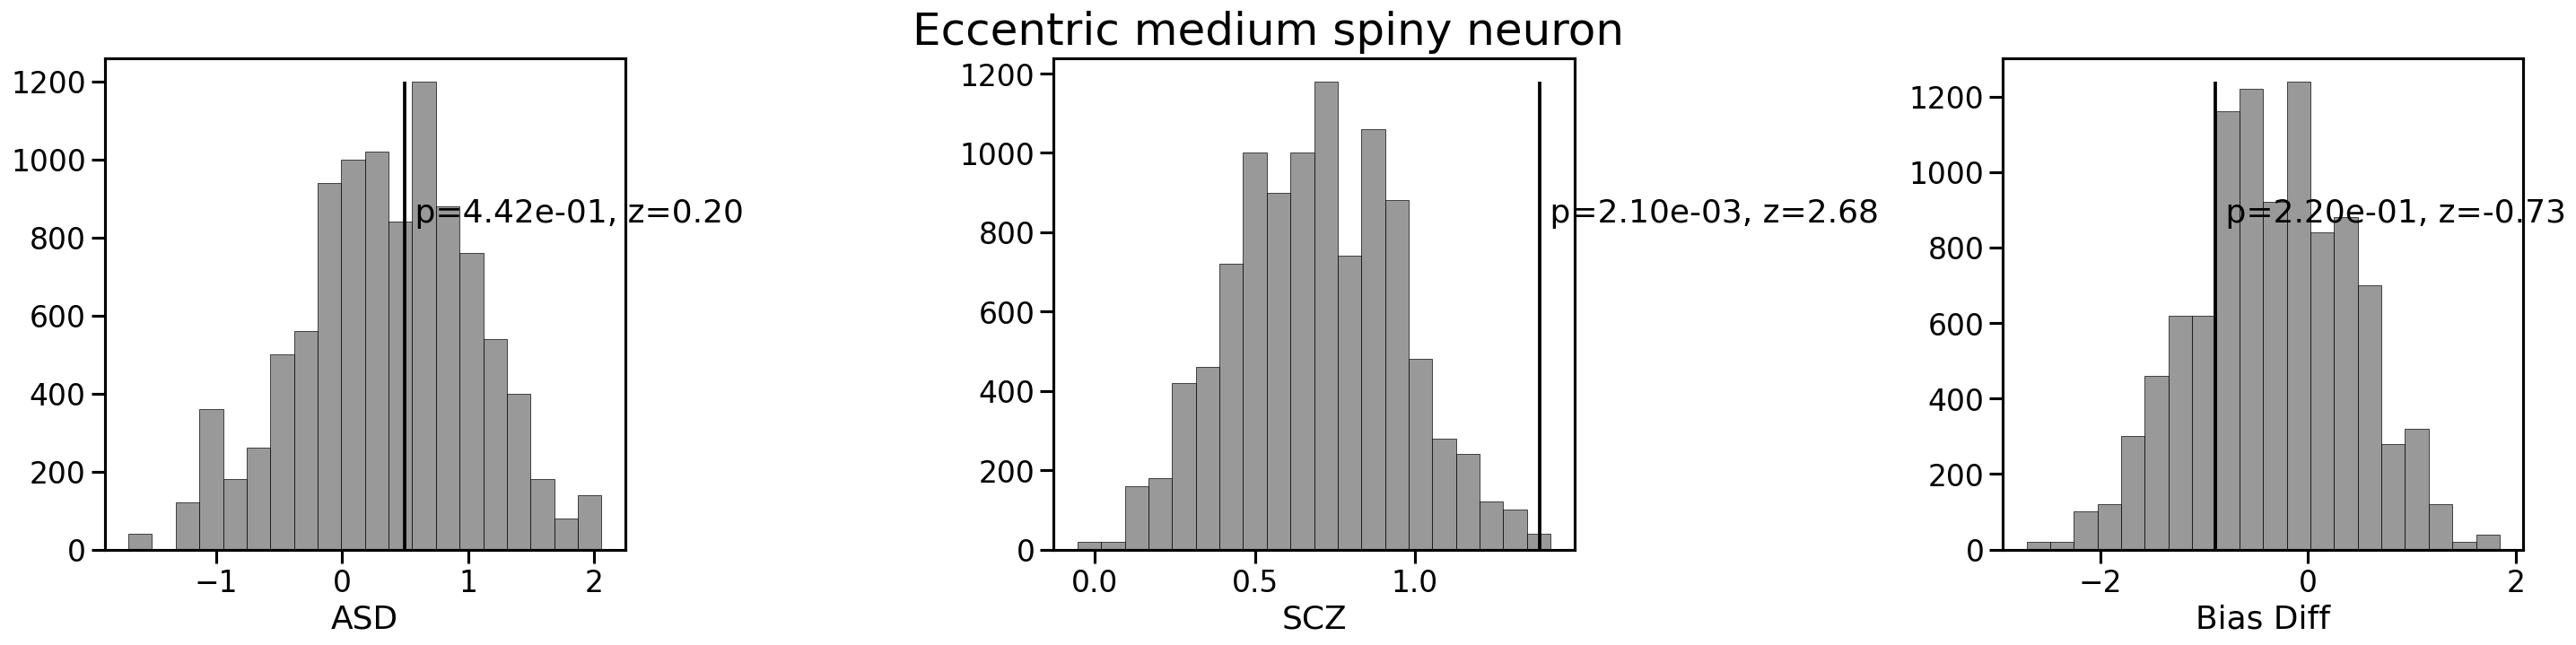

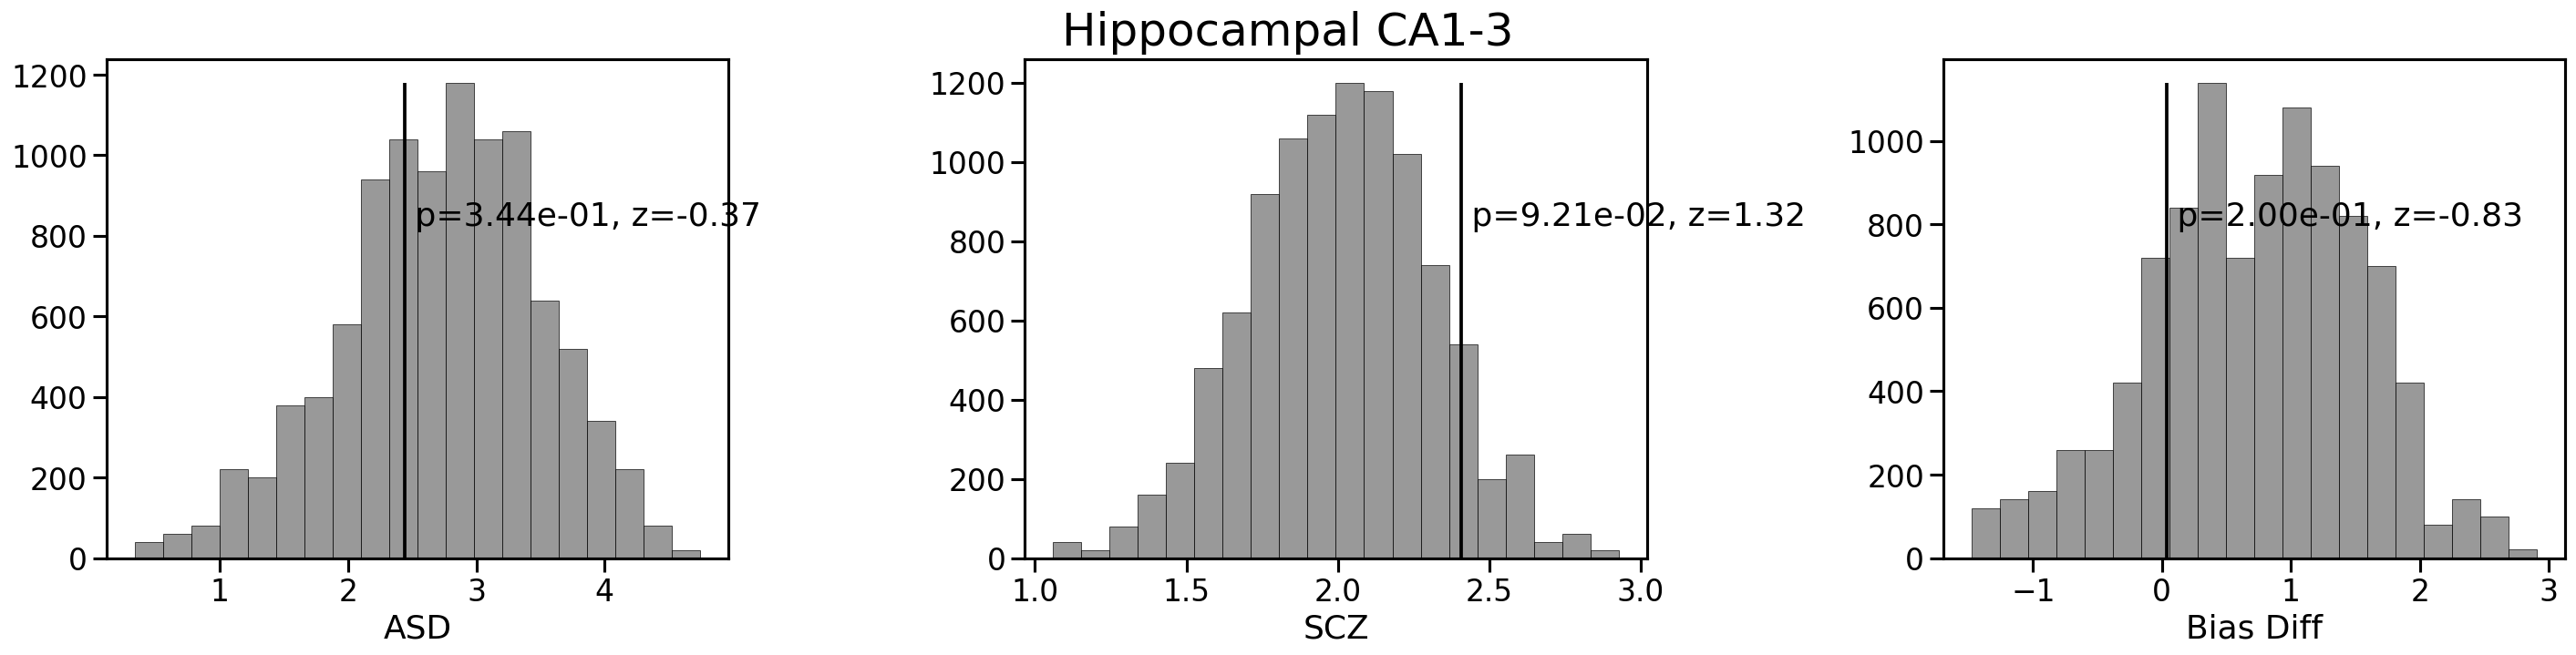

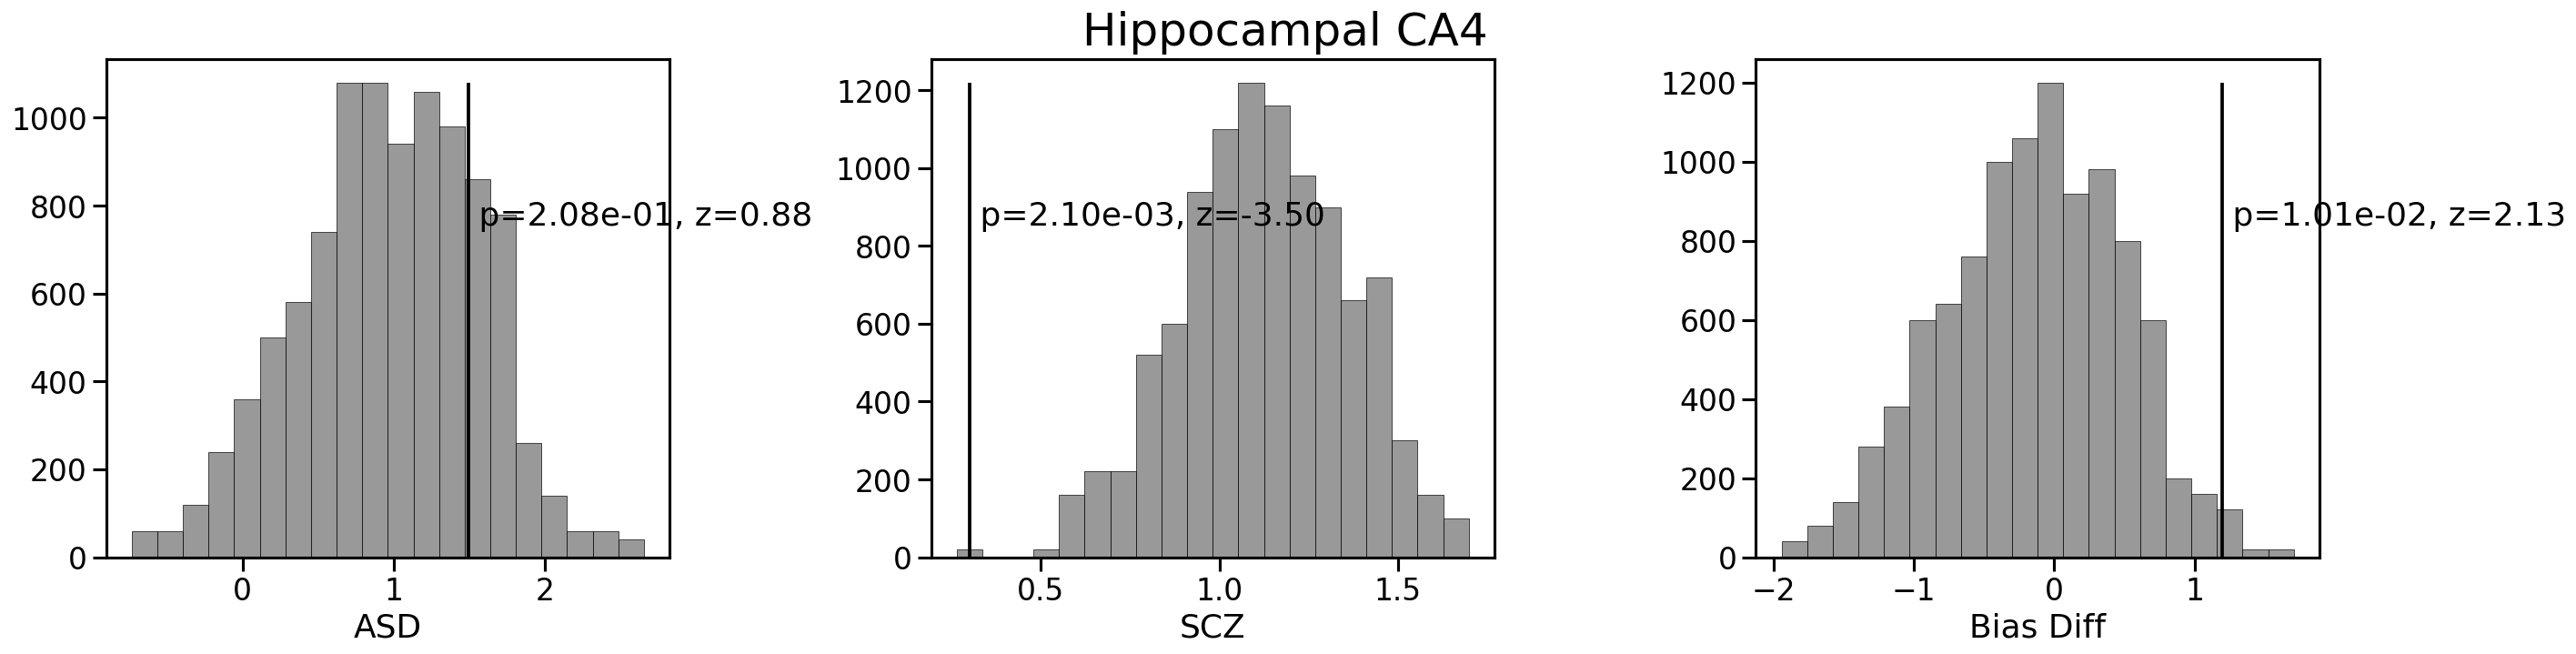

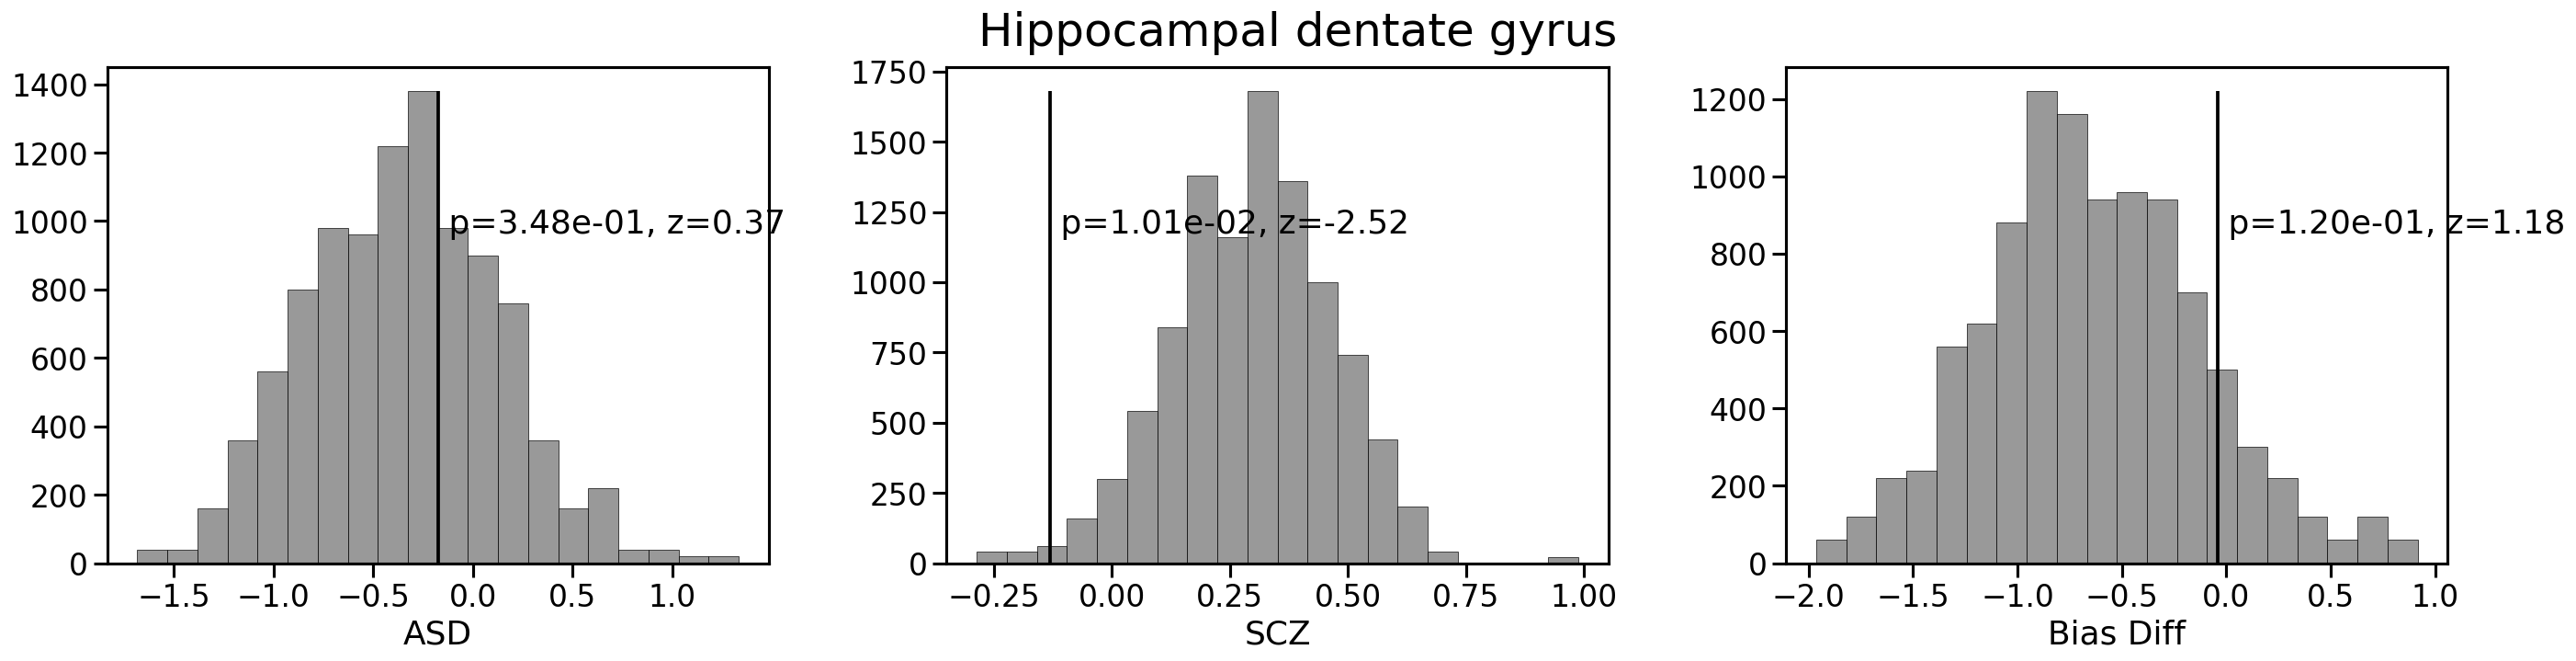

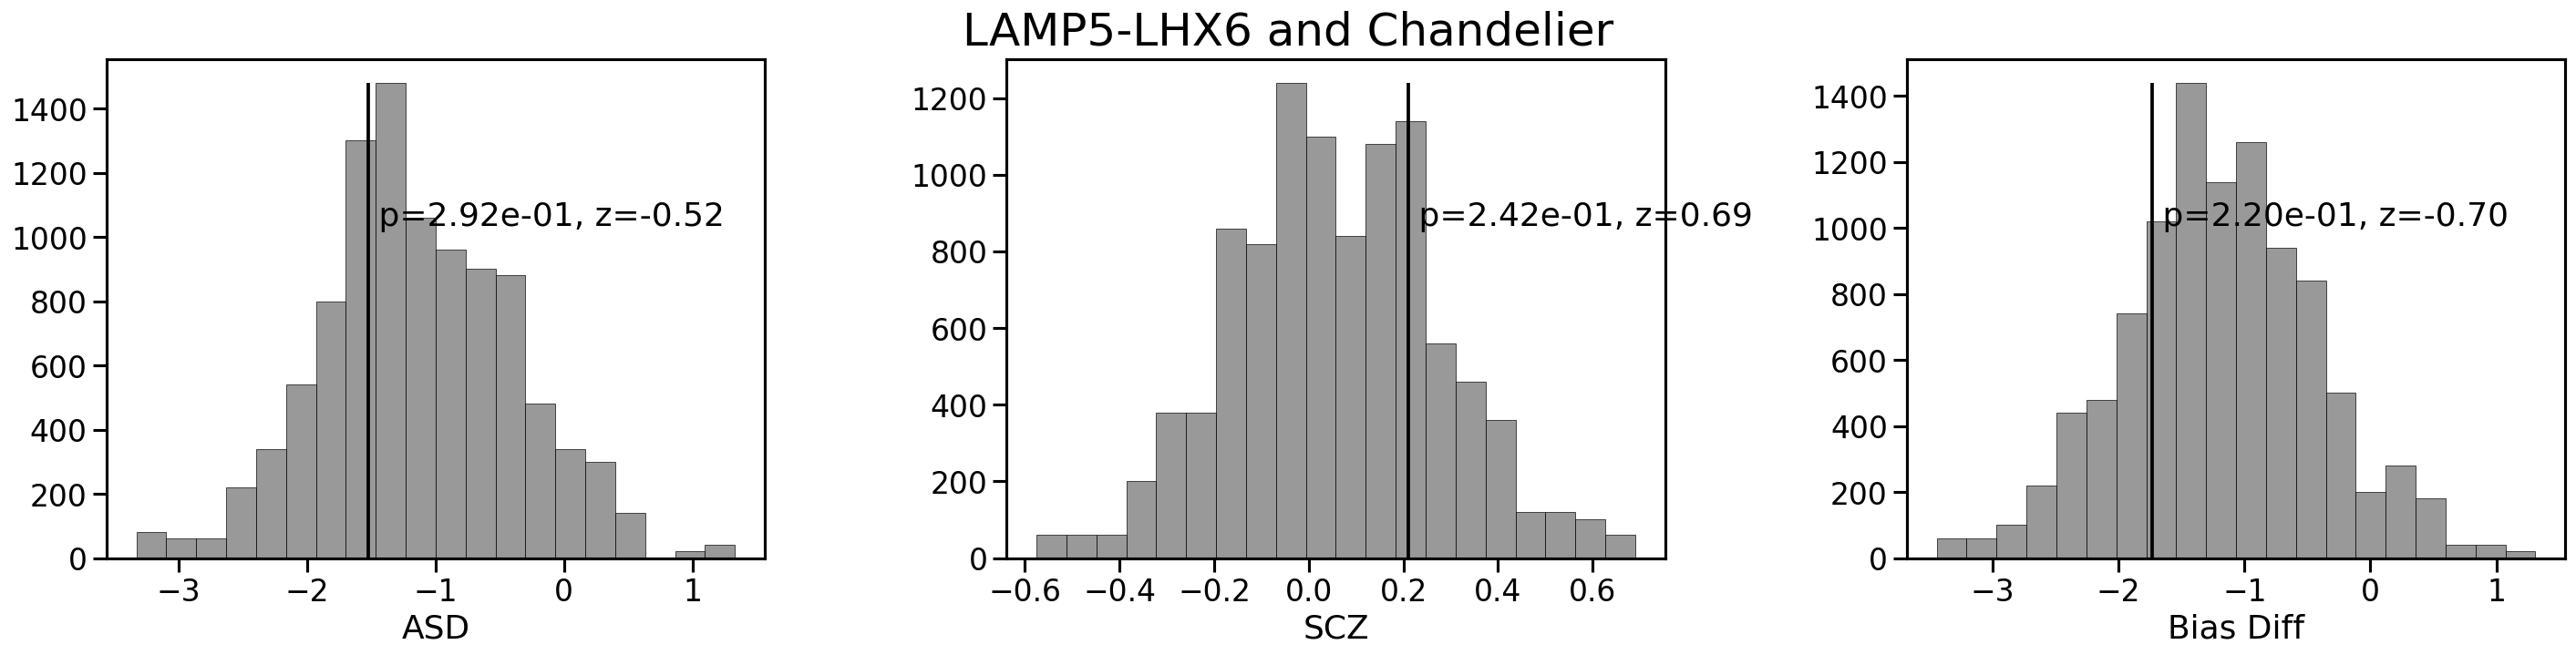

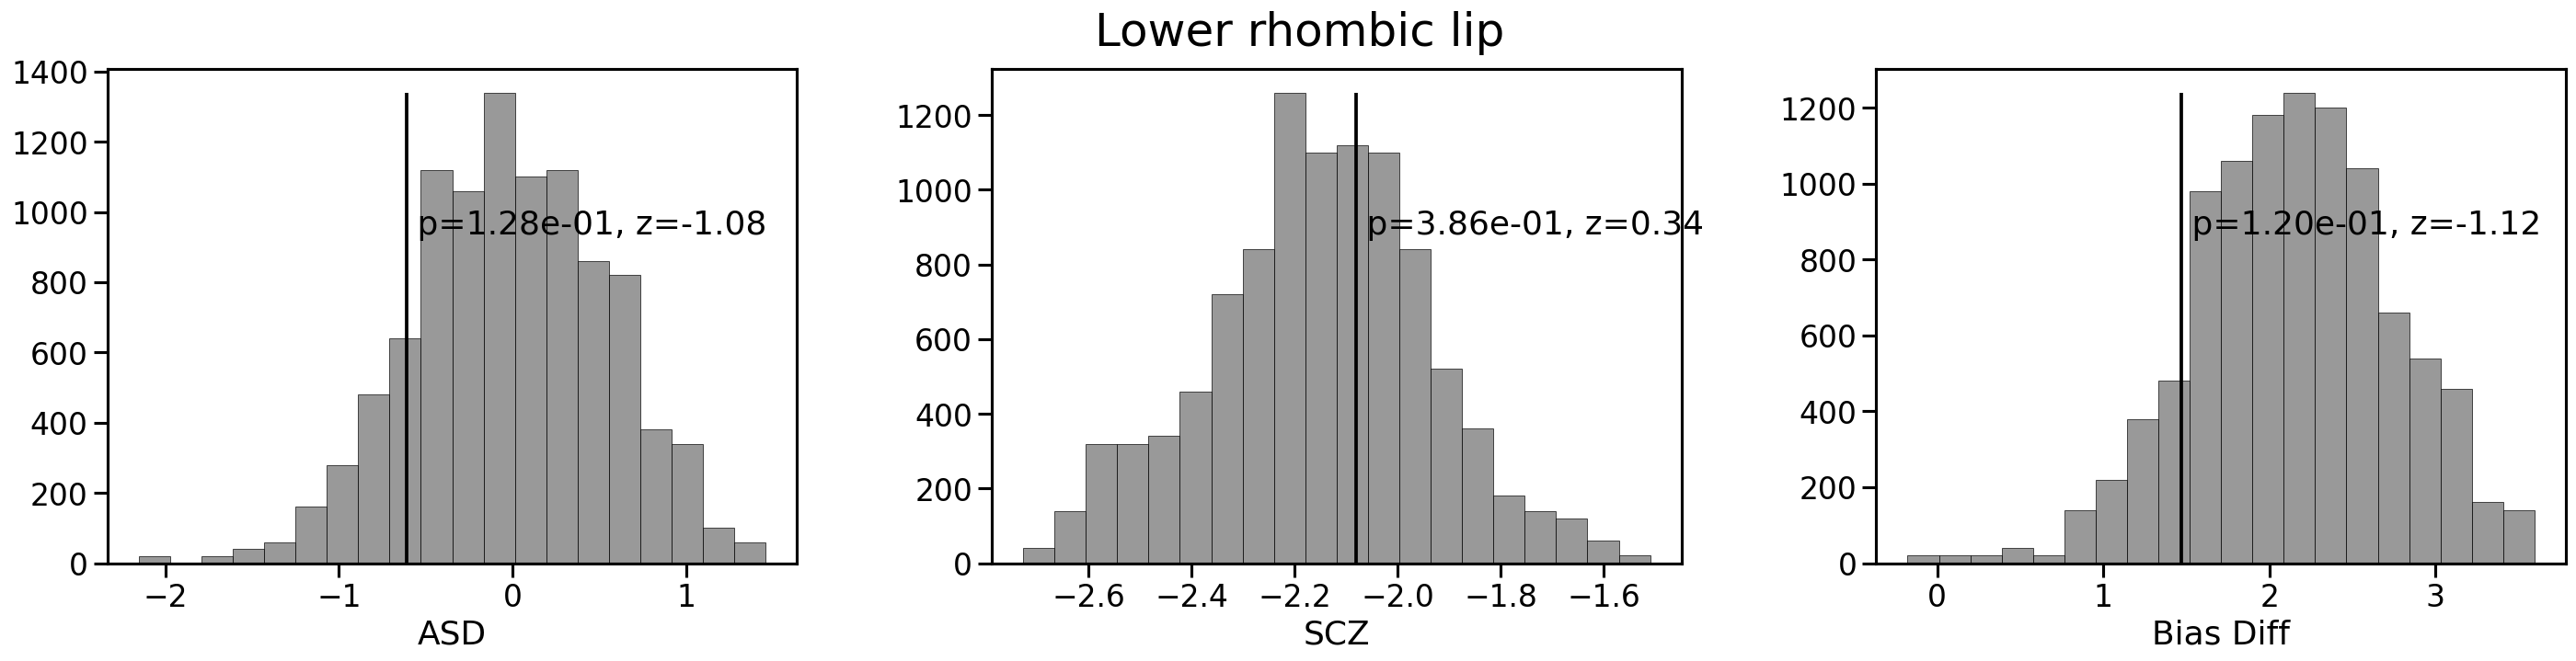

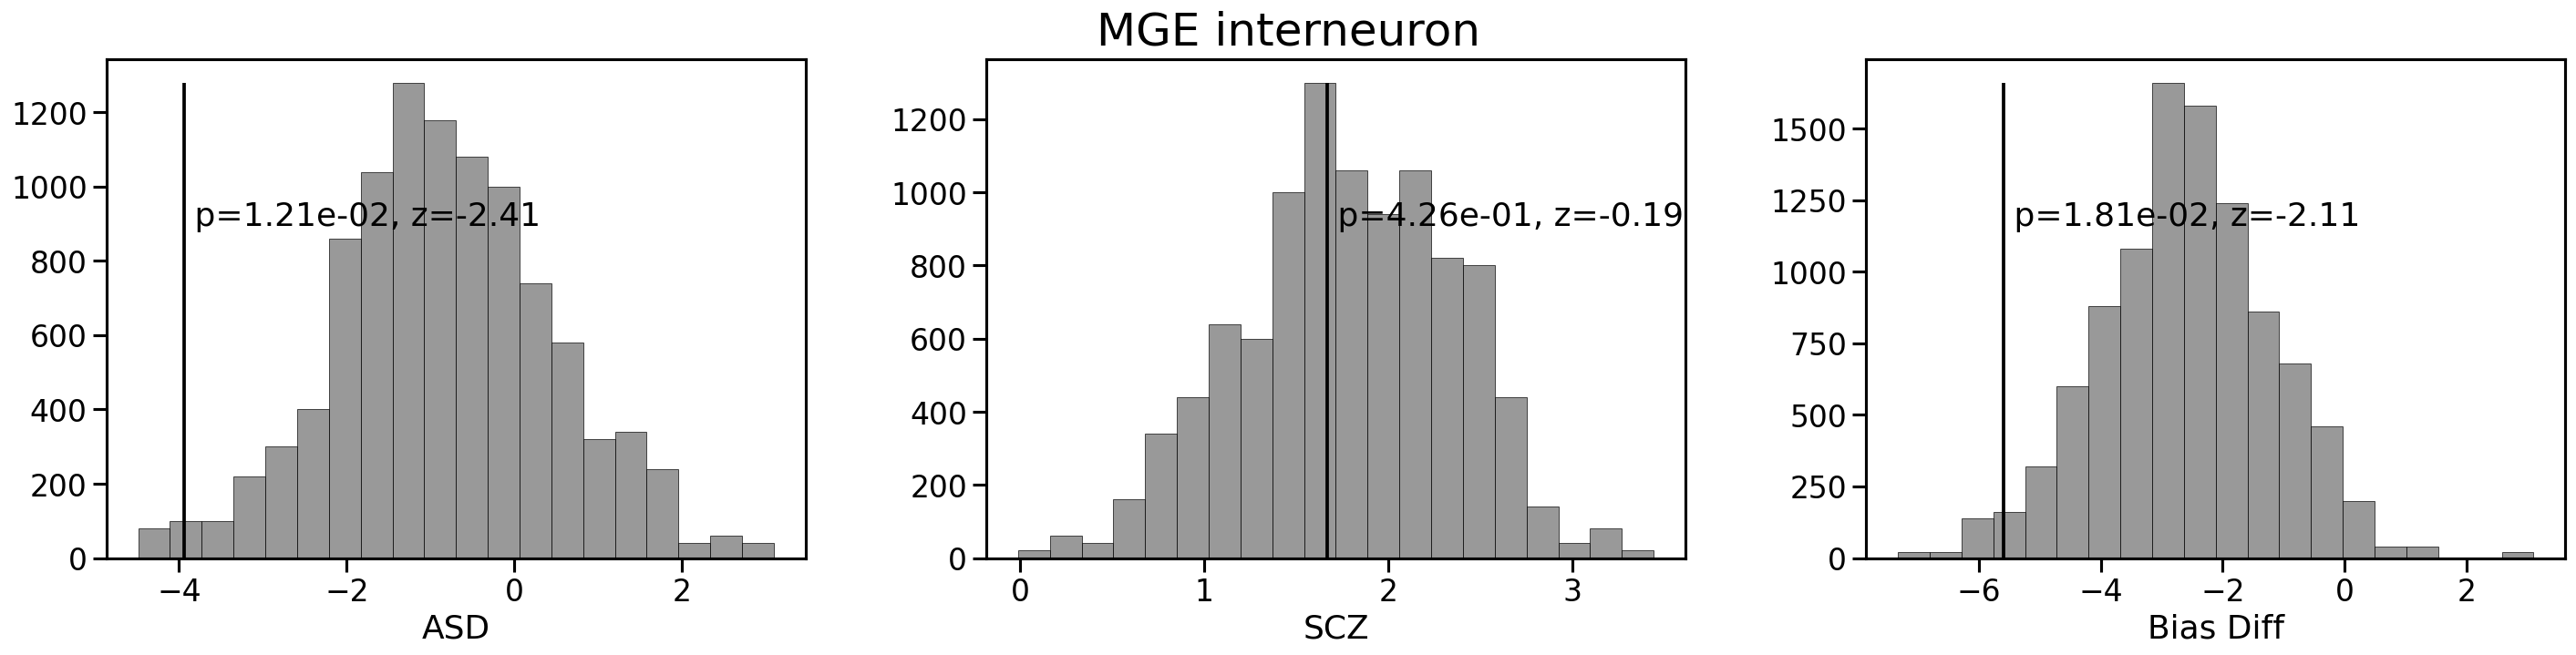

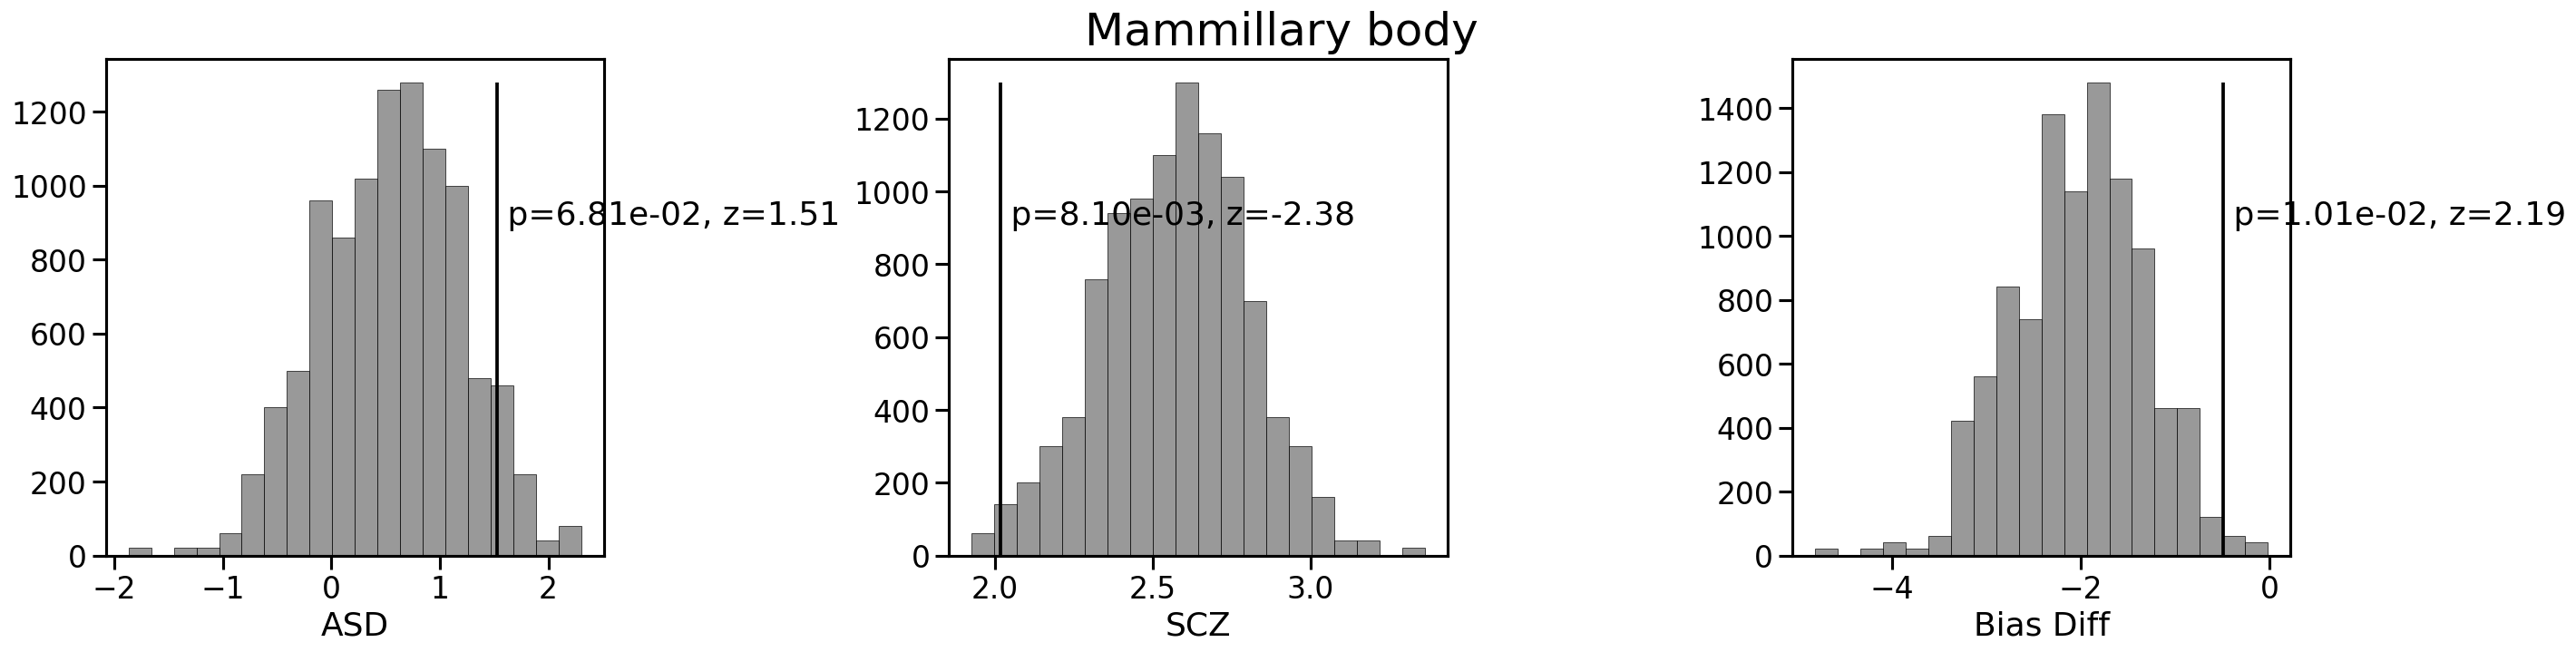

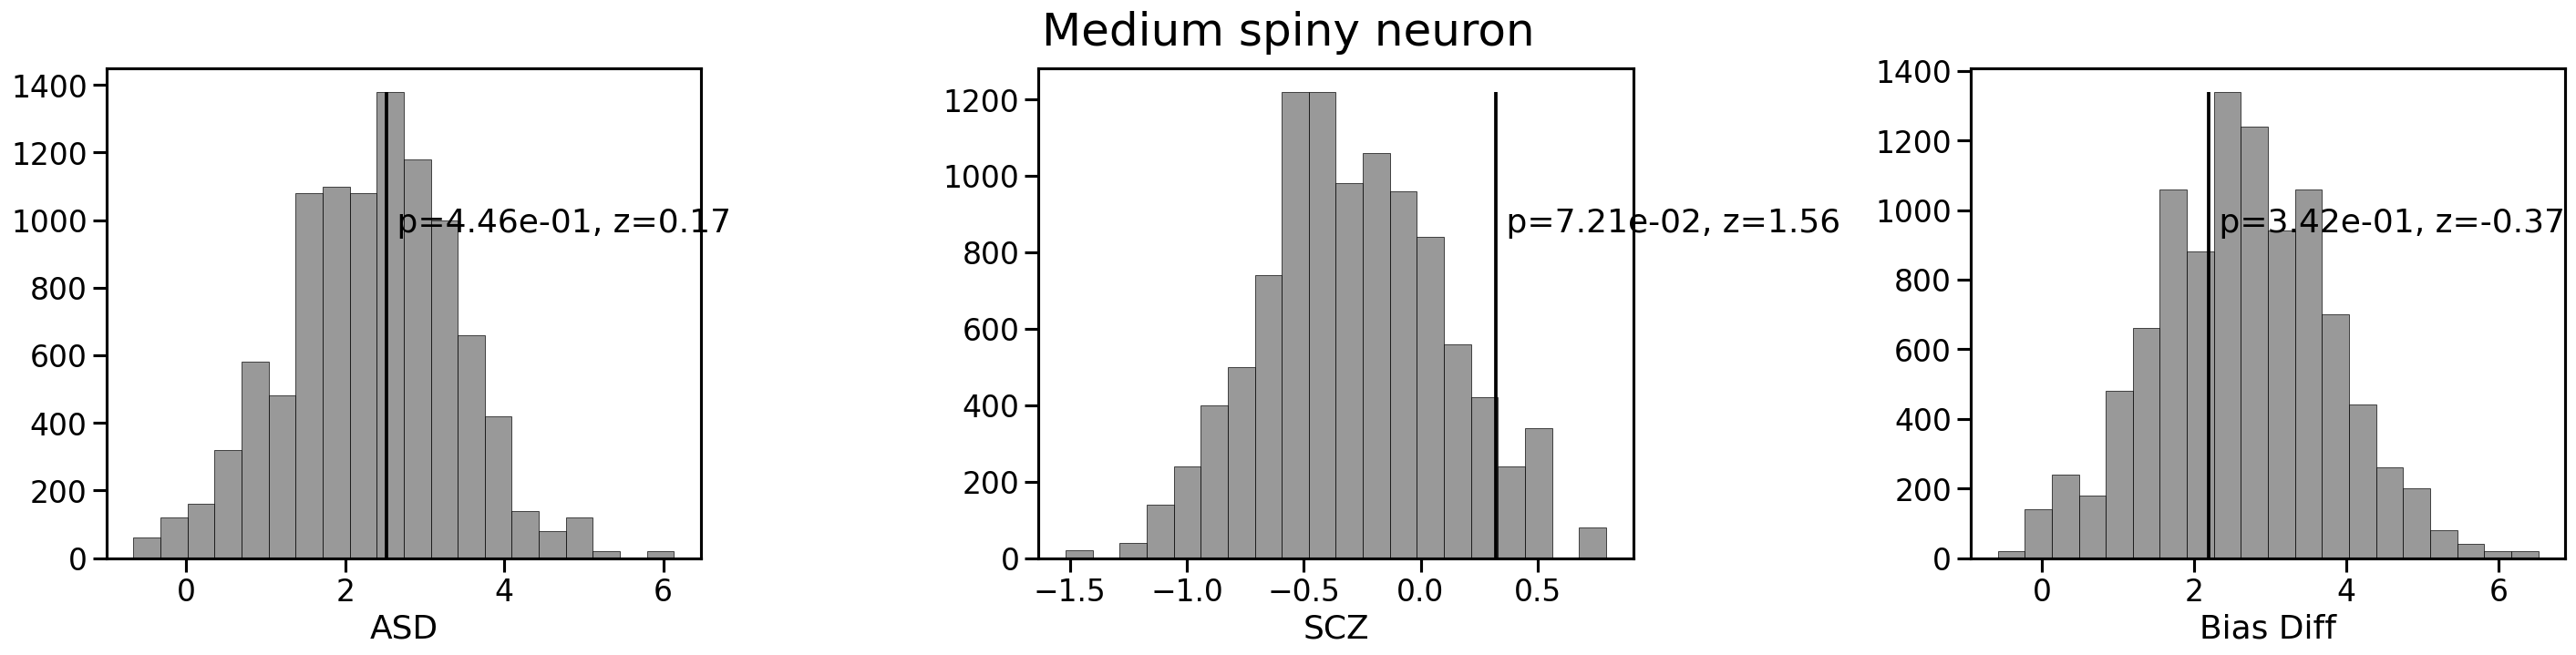

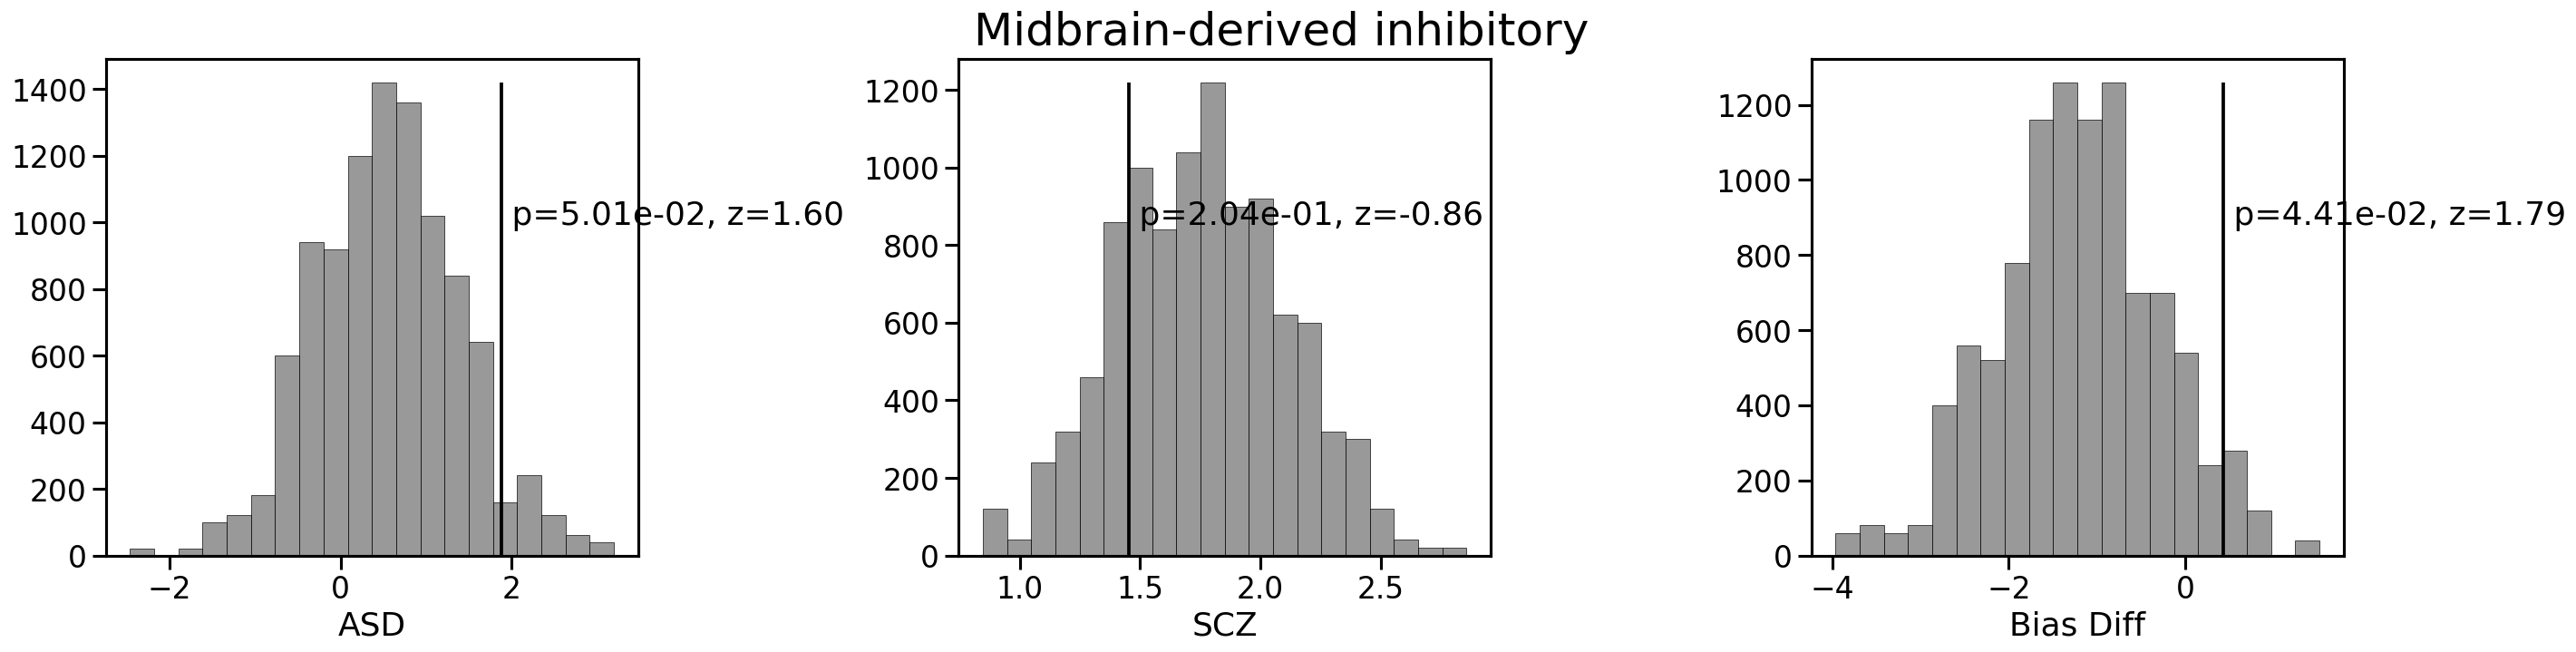

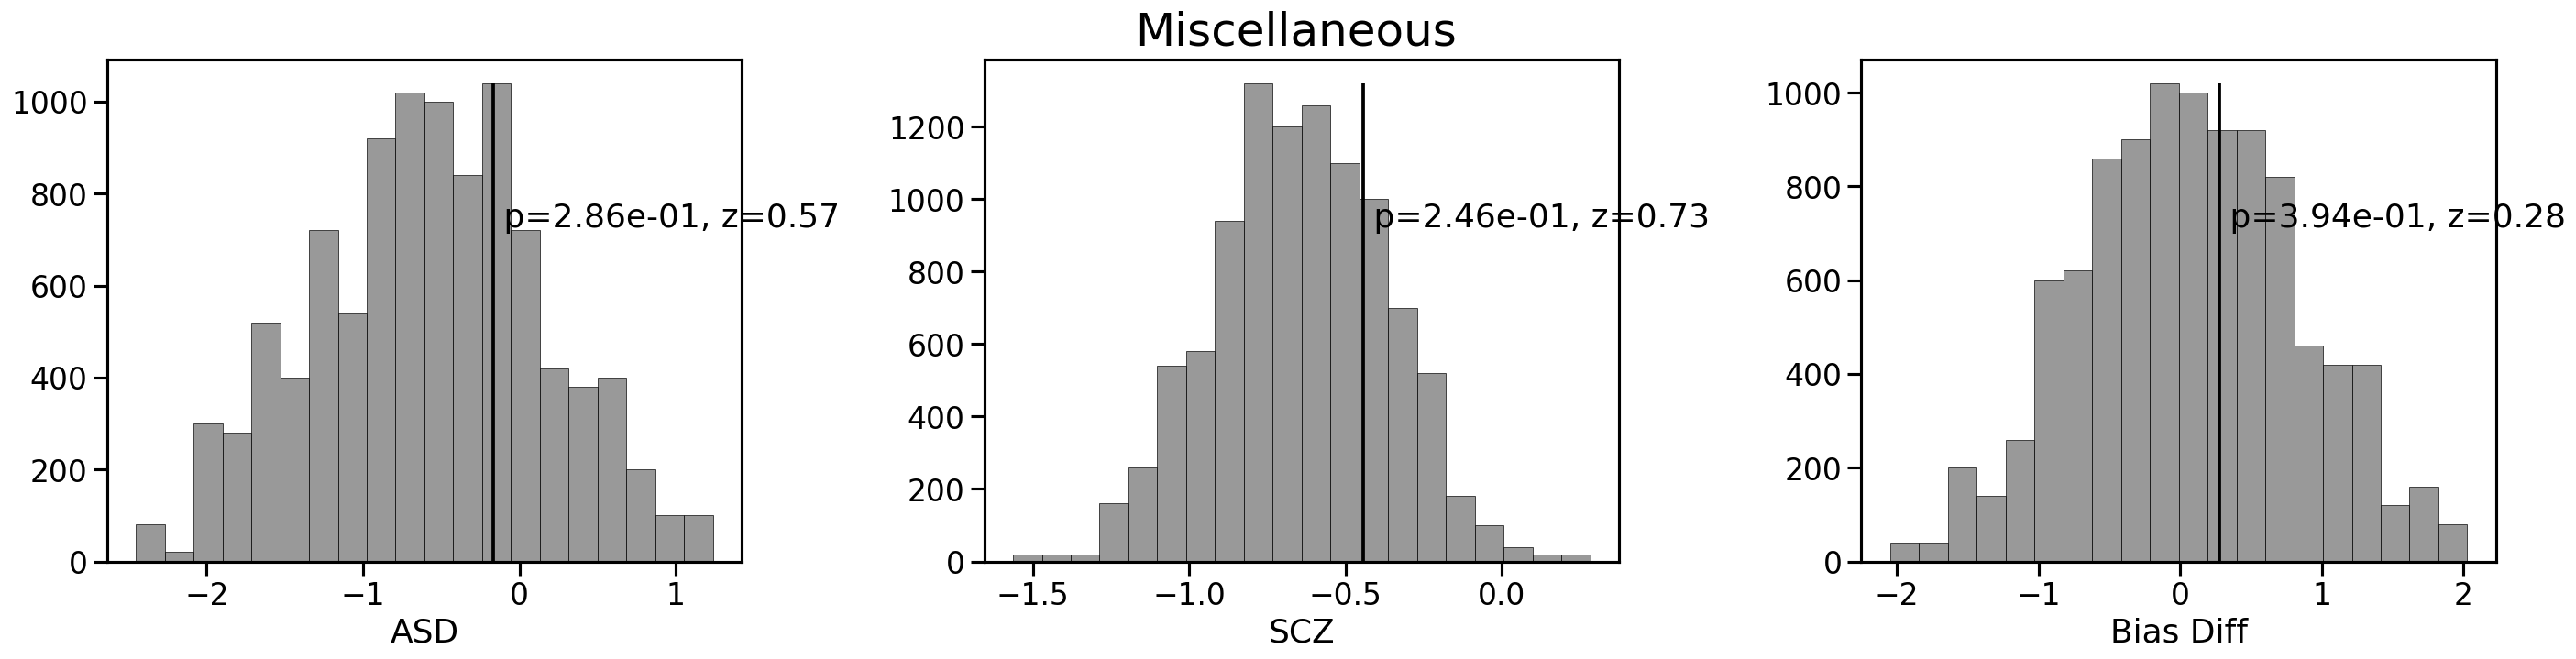

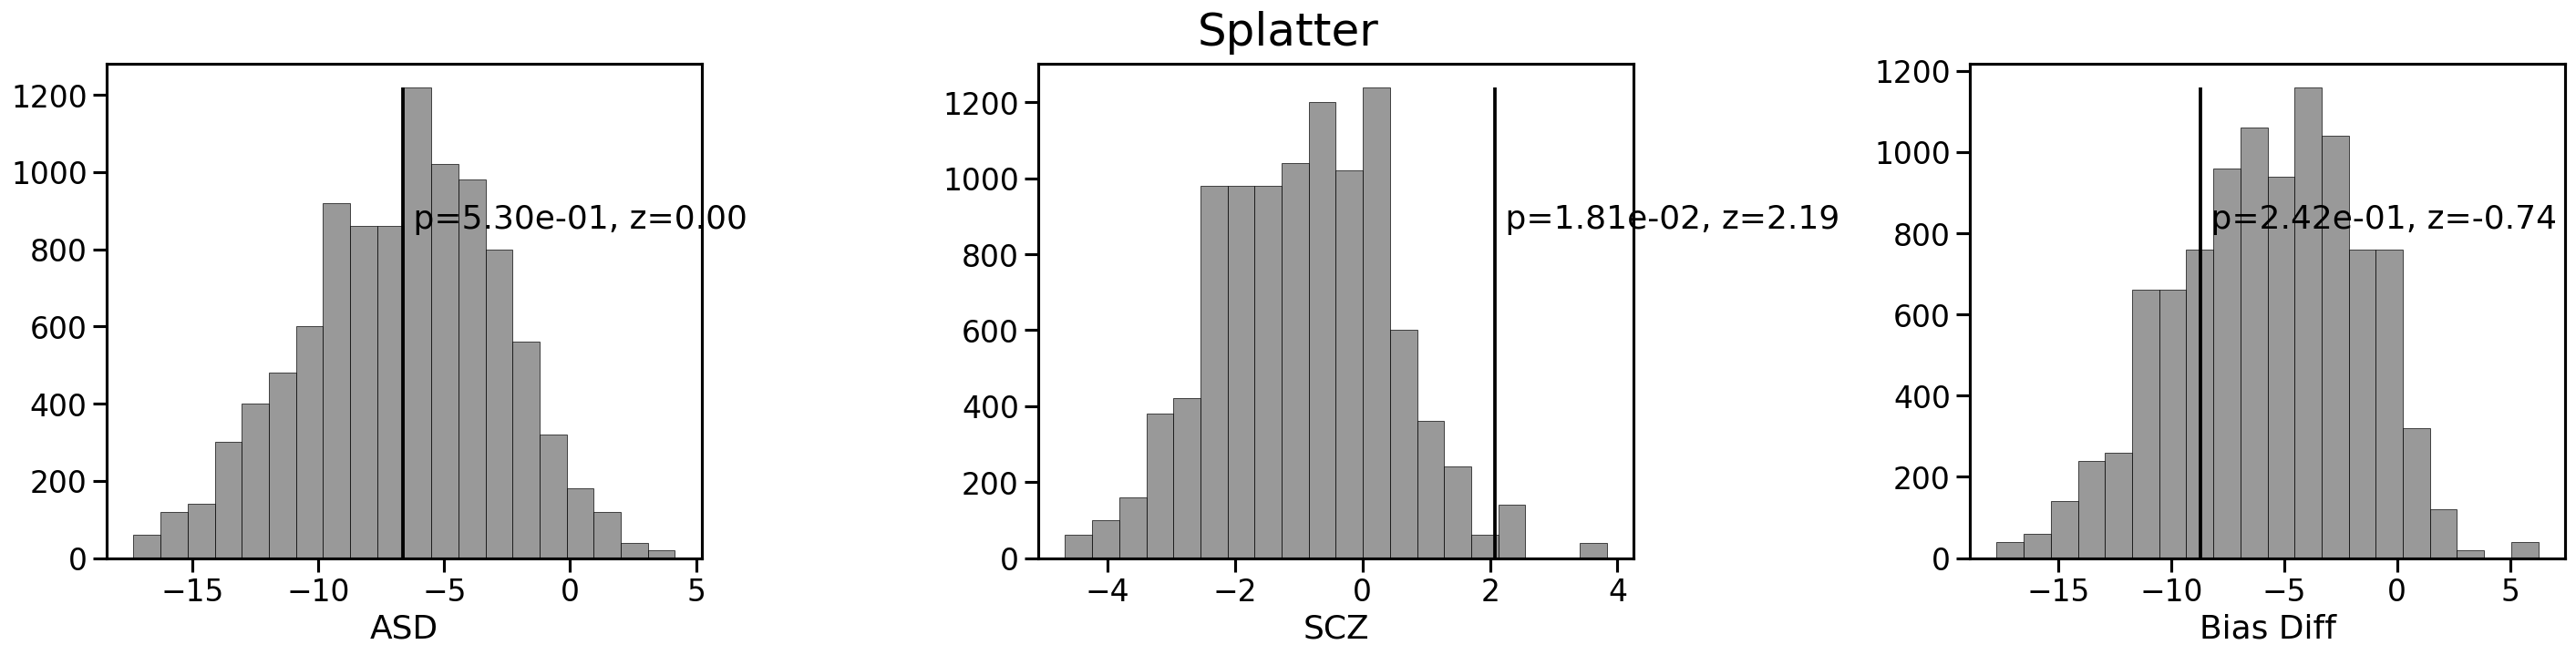

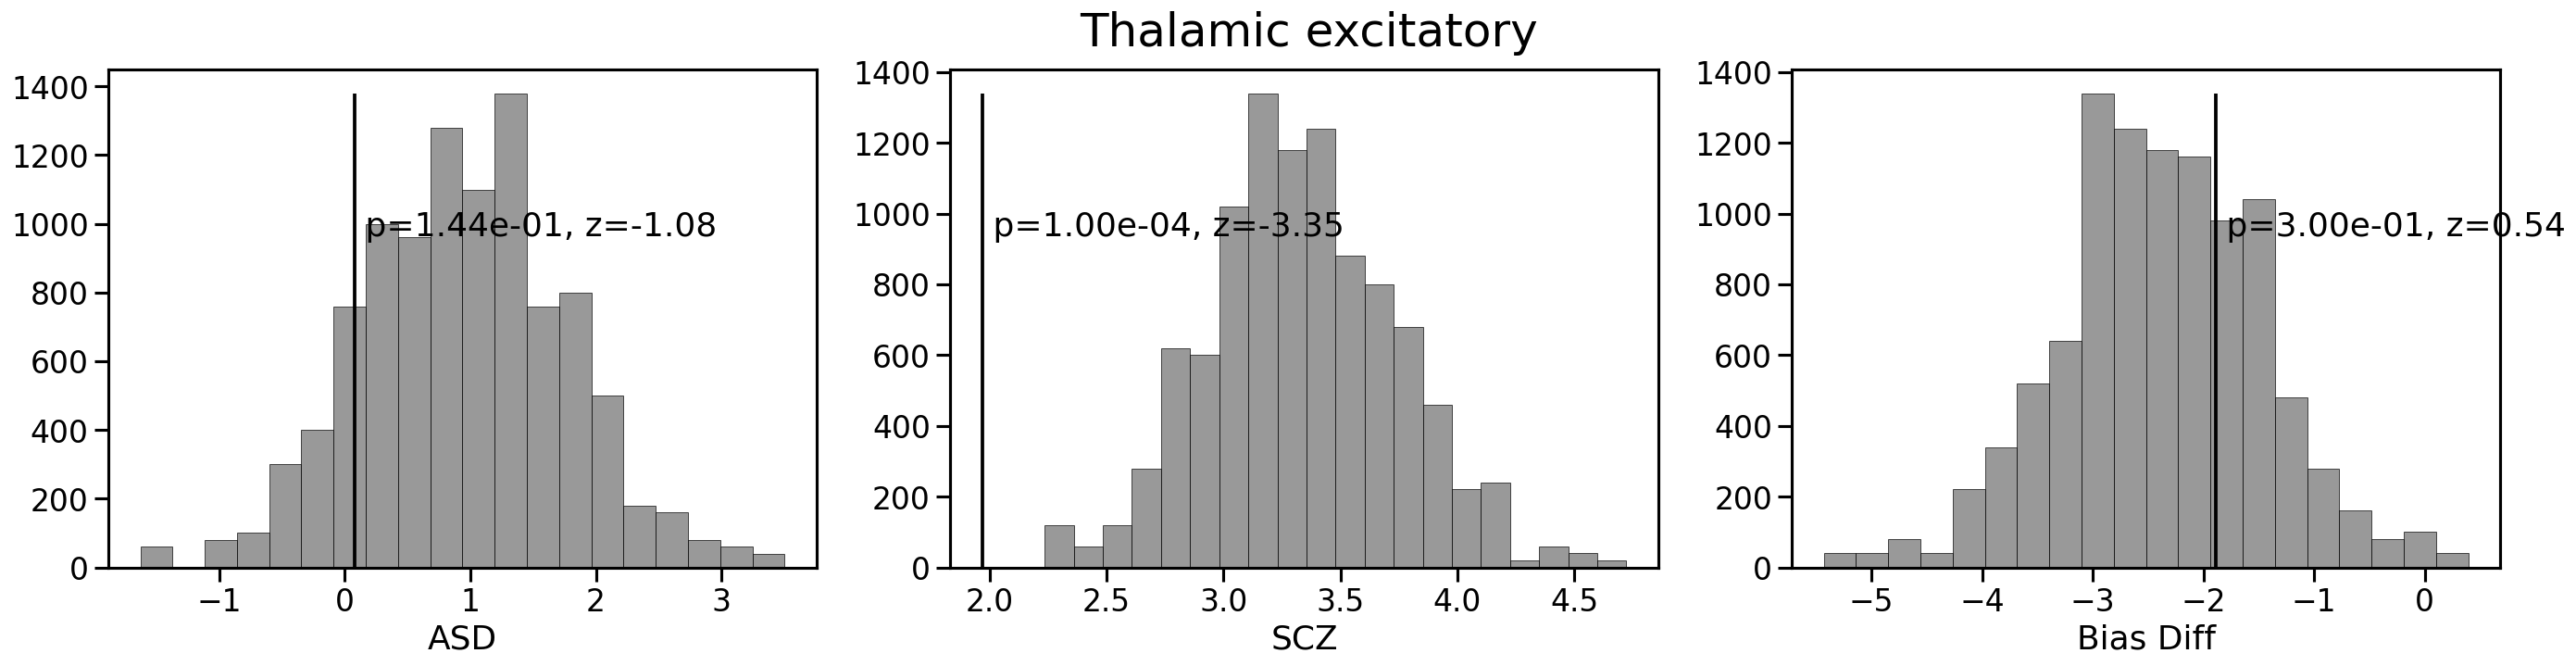

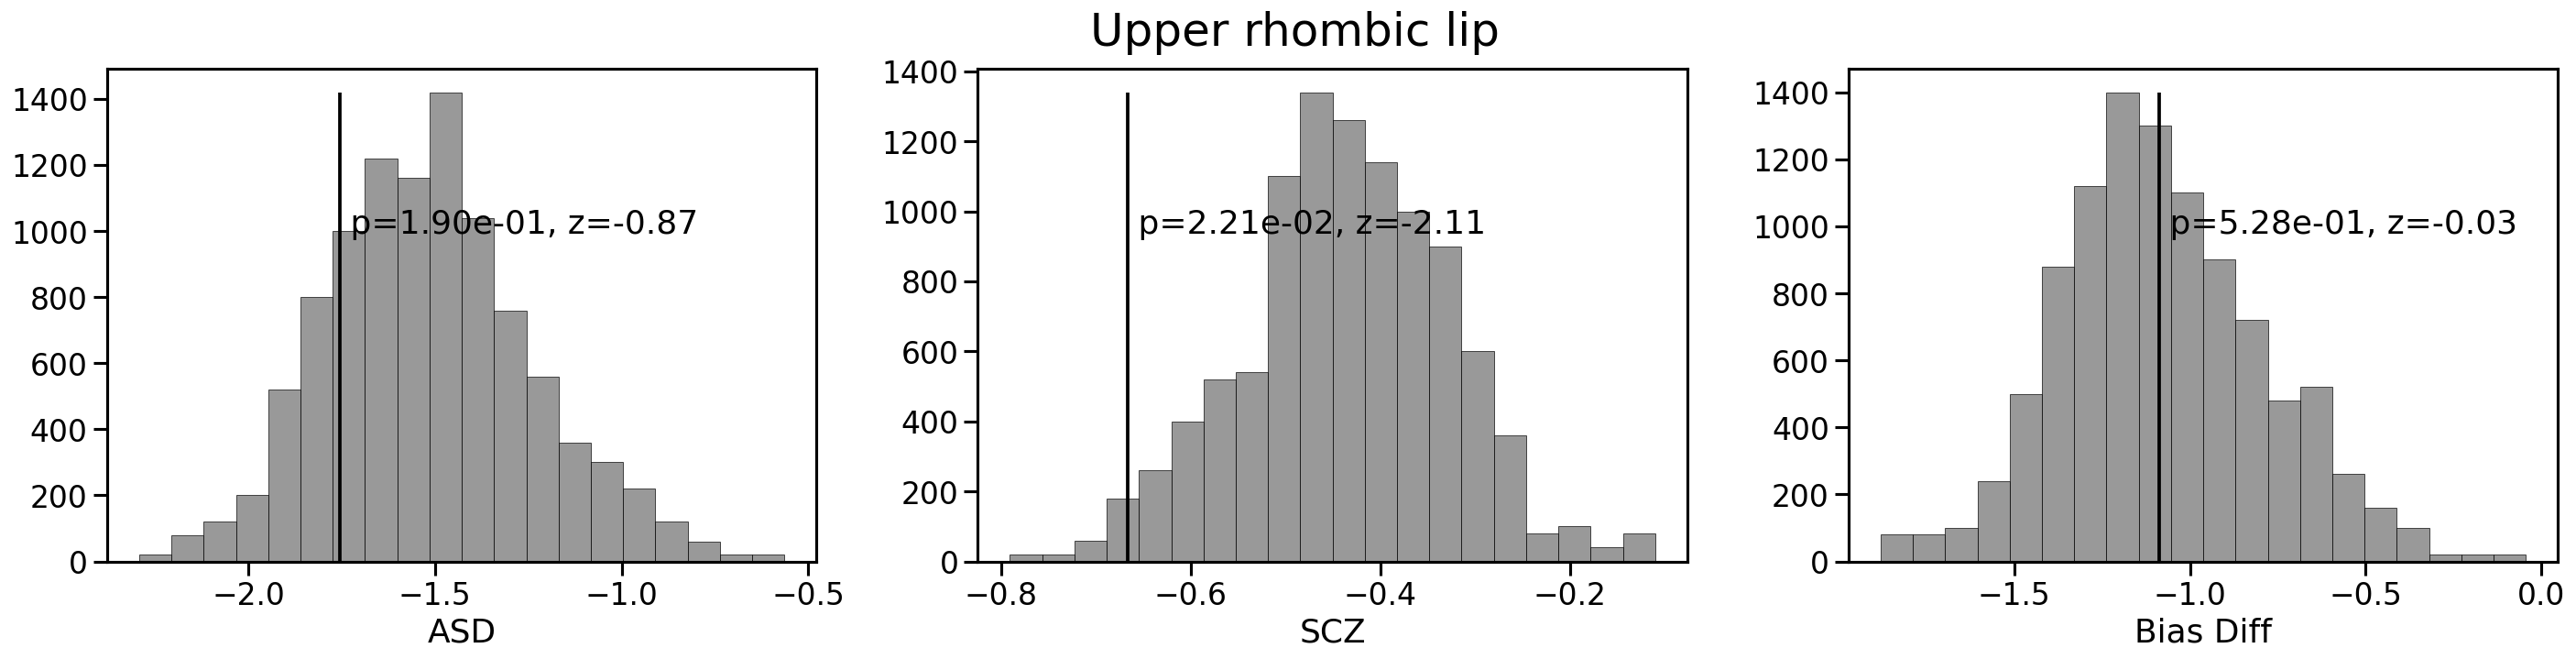

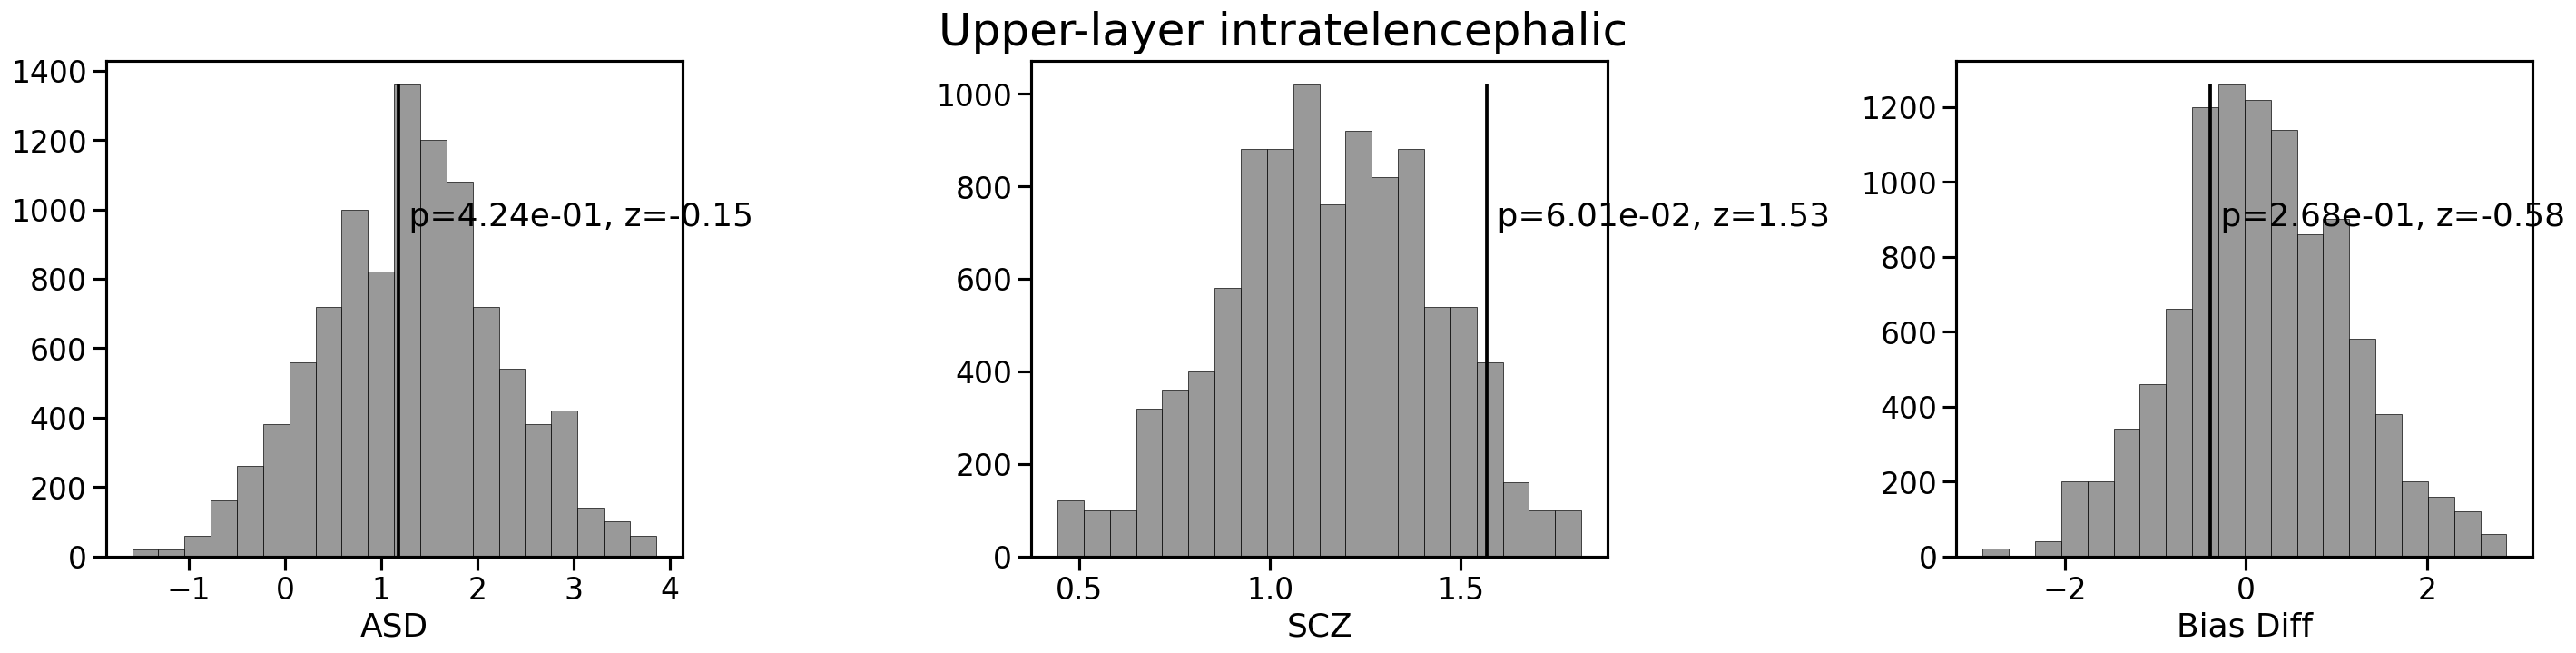

In [628]:
#CT = "CGE interneuron"
for CT in Neurons:
    TestDiff_Perm(CT, ASD_CT_Bias, SCZ_CT_Bias, Permut_ASD_DF_MutPerm_v5, Permut_SCZ_DF_MutPerm_v5)